# Credit Card Fraud Detection

### Exploratory Data Analysis and Machine Learning

## Table of Contents

1. Import Libraries
2. Load Dataset
3. Data Overview
4. Exploratory Data Analysis
5. Merge Transaction and Identity Data
6. Correlation Analysis
7. Missing Values Analysis
8. Data Preprocessing
9. Train/Validation Split
10. Encode High-Cardinality Features (Post-Split)
11. Feature Engineering
12. Advanced Feature Engineering (UID Trick)
13. Drop Helper/Non-Feature Columns
14. Split Features and Target
15. Sanity Check
16. Model Building
17. Additional Feature Engineering (Velocity & Broader UID)
18. Model Update — Retrain with New Features
19. Proper Hyperparameter Validation (TimeSeriesSplit CV)
20. Final Model — Train on Full Data
21. Model Evaluation
22. Conclusion

## 1. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
import os
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
plt.style.use("default")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Load Dataset

### Dataset Source

- train_transaction.csv
- train_identity.csv

The datasets were obtained from the IEEE-CIS Fraud Detection competition on Kaggle.

In [ ]:
import os
import pandas as pd


if not os.path.exists("ieee-fraud-detection/train_transaction.csv") and not os.path.exists("../data/train_transaction.csv"):
    print("Dataset not found! Downloading automatically from Kaggle...")
    
    
    !pip install opendatasets --quiet
    import opendatasets as od
    
    
    od.download("https://www.kaggle.com/competitions/ieee-fraud-detection")
    data_dir = "ieee-fraud-detection"
else:
    data_dir = "ieee-fraud-detection" if os.path.exists("ieee-fraud-detection/train_transaction.csv") else "../data"

print(f"Loading data from: {data_dir}...")
trans_df = pd.read_csv(os.path.join(data_dir, "train_transaction.csv"))
id_df = pd.read_csv(os.path.join(data_dir, "train_identity.csv"))
print("Dataset loaded successfully!")

Dataset not found! Downloading automatically from Kaggle...



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

## 3. Initial Data Exploration
    - Shape
    - Head
    - Info
    - Missing Values
    - Duplicates

In [3]:
print("Transaction Dataset Shape:", trans_df.shape)
print("Identity Dataset Shape:", id_df.shape)

Transaction Dataset Shape: (590540, 394)
Identity Dataset Shape: (144233, 41)


The transaction dataset contains 590,540 records and 394 features, while the identity dataset contains 144,233 records and 41 features. Since the identity dataset is considerably smaller, not every transaction has corresponding identity information.

In [4]:
trans_df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,

The first few rows provide an overview of the dataset structure and feature names.

In [5]:
id_df.head(10)

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS
5,2987017,-5.0,61141.0,3.0,0.0,3.0,0.0,NaN,NaN,3.0,0.0,100.0,NotFound,52.0,-300.0,Found,Found,166.0,18.0,529.0,600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Windows 10,chrome 62.0,24.0,1366x768,match_status:2,T,F,T,T,desktop,Windows
6,2987022,-15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NotFound,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987038,0.0,31964.0,0.0,0.0,0.0,-10.0,NaN,NaN,0.0,0.0,100.0,Found,NaN,-300.0,Found,Found,166.0,15.0,352.0,533.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Android,chrome 62.0,32.0,1920x1080,match_status:2,T,F,T,T,mobile,NaN
8,2987040,-10.0,116098.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
9,2987048,-5.0,257037.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,484.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows


In [6]:
trans_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


The transaction dataset contains 590,540 records and 394 features, including both numerical and categorical variables. Several features contain missing values that will require preprocessing before model training.

In [7]:
id_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  str    
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  str    
 16  id_16          129340 non-null  str    
 17  id_17          139369 non-null  float64


The identity dataset provides information for 144,233 transactions, which is significantly fewer than the total number of transactions. This indicates that identity information is available only for a subset of transactions. Several columns contain a very high percentage of missing values, while categorical features such as DeviceType and DeviceInfo may provide useful information for fraud detection after appropriate preprocessing.

### Missing Value Analysis

In [8]:
trans_df.isnull().sum().sort_values(ascending=False).head(30)

dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V149     508595
V141     508595
V146     508595
V154     508595
V162     508595
V142     508595
V158     508595
V161     508595
V157     508595
V138     508595
V139     508595
V148     508595
V140     508595
V155     508595
V156     508595
V147     508595
V163     508595
V143     508589
V145     508589
V144     508589
V165     508589
dtype: int64

Several features contain an extremely high number of missing values. For example, columns such as dist2, D7, D13, and many V features have missing values in more than 85% of the transactions. This suggests that these variables are available only under specific conditions rather than for every transaction. These columns should not be removed immediately; instead, their missing-value percentages and predictive importance should be evaluated before making a decision.

In [9]:
(trans_df.isnull().mean() * 100).sort_values(ascending=False).head(100)

dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
D6       87.606767
D9       87.312290
D8       87.312290
V153     86.123717
V149     86.123717
V141     86.123717
V146     86.123717
V154     86.123717
V162     86.123717
V142     86.123717
V158     86.123717
V161     86.123717
V157     86.123717
V138     86.123717
V139     86.123717
V148     86.123717
V140     86.123717
V155     86.123717
V156     86.123717
V147     86.123717
V163     86.123717
V143     86.122701
V145     86.122701
V144     86.122701
V165     86.122701
V164     86.122701
V152     86.122701
V150     86.122701
V151     86.122701
V160     86.122701
V159     86.122701
V166     86.122701
V329     86.054967
V328     86.054967
V326     86.054967
V327     86.054967
V325     86.054967
V331     86.054967
V330     86.054967
V333     86.054967
V323     86.054967
V324     86.054967
V322     86.054967
V339     86.054967
V338     86.054967
V335     86.054967
V334     86.054967
V332     86.

Several features contain missing values exceeding 80%. However, these features should not be removed solely based on missingness, as they may still provide valuable predictive information.

In [10]:
id_df.isnull().sum().sort_values(ascending=False).head(100)

id_24            139486
id_25            139101
id_07            139078
id_08            139078
id_21            139074
id_26            139070
id_23            139064
id_27            139064
id_22            139064
id_18             99120
id_04             77909
id_03             77909
id_33             70944
id_10             69307
id_09             69307
id_30             66668
id_32             66647
id_34             66428
id_14             64189
DeviceInfo        25567
id_13             16913
id_16             14893
id_06              7368
id_05              7368
id_20              4972
id_19              4915
id_17              4864
id_31              3951
DeviceType         3423
id_02              3361
id_28              3255
id_29              3255
id_11              3255
id_38              3248
id_35              3248
id_36              3248
id_15              3248
id_37              3248
TransactionID         0
id_01                 0
id_12                 0
dtype: int64

In [11]:
(id_df.isnull().mean() * 100).sort_values(ascending=False).head(100)

id_24            96.708798
id_25            96.441868
id_07            96.425922
id_08            96.425922
id_21            96.423149
id_26            96.420375
id_23            96.416215
id_27            96.416215
id_22            96.416215
id_18            68.722137
id_04            54.016071
id_03            54.016071
id_33            49.187079
id_10            48.052110
id_09            48.052110
id_30            46.222432
id_32            46.207872
id_34            46.056034
id_14            44.503685
DeviceInfo       17.726179
id_13            11.726165
id_16            10.325654
id_06             5.108401
id_05             5.108401
id_20             3.447200
id_19             3.407681
id_17             3.372321
id_31             2.739318
DeviceType        2.373243
id_02             2.330257
id_28             2.256765
id_29             2.256765
id_11             2.256765
id_38             2.251912
id_35             2.251912
id_36             2.251912
id_15             2.251912
i

### Duplicate Analysis

In [12]:
trans_df.duplicated().sum()

np.int64(0)

In [13]:
id_df.duplicated().sum()

np.int64(0)

No duplicate records were found in either the transaction dataset or the identity dataset

### Data Types Analysis

In [14]:
trans_df.dtypes.value_counts()

float64    376
str         14
int64        4
Name: count, dtype: int64

In [15]:
trans_df.select_dtypes(include="str").columns

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9'],
      dtype='str')

In [16]:
trans_df.select_dtypes(include=["int64", "float64"]).columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1',
       'card2', 'card3', 'card5', 'addr1', 'addr2',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='str', length=380)

## 4. Exploratory Data Analysis (EDA)


### 4.1 Target Variable Analysis

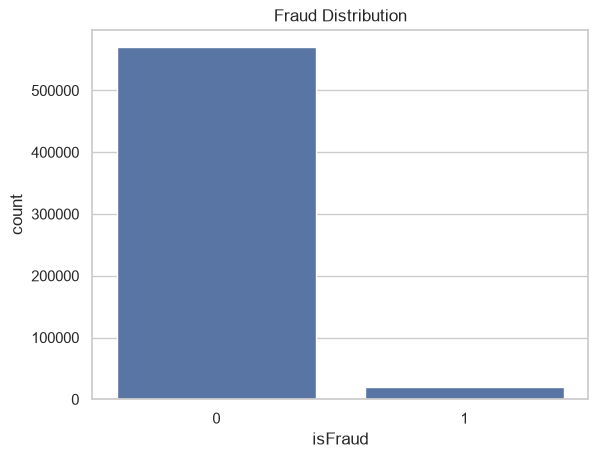

In [17]:
sns.countplot(data=trans_df, x="isFraud")
plt.title("Fraud Distribution")
plt.show()

In [18]:
trans_df["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

Legitimate transactions significantly outnumber fraudulent transactions.

In [19]:
trans_df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

The target variable is highly imbalanced, with legitimate transactions representing the vast majority of the dataset and fraudulent transactions accounting for only a small percentage. This imbalance should be considered during model development

### 4.2 Numerical Features

In [20]:
trans_df["TransactionAmt"].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

The TransactionAmt feature is highly right-skewed. While 75% of transactions are below 125, the maximum transaction amount exceeds 31,000, indicating the presence of significant outliers. Additionally, the mean is much higher than the median, suggesting that a small number of large transactions are influencing the average.

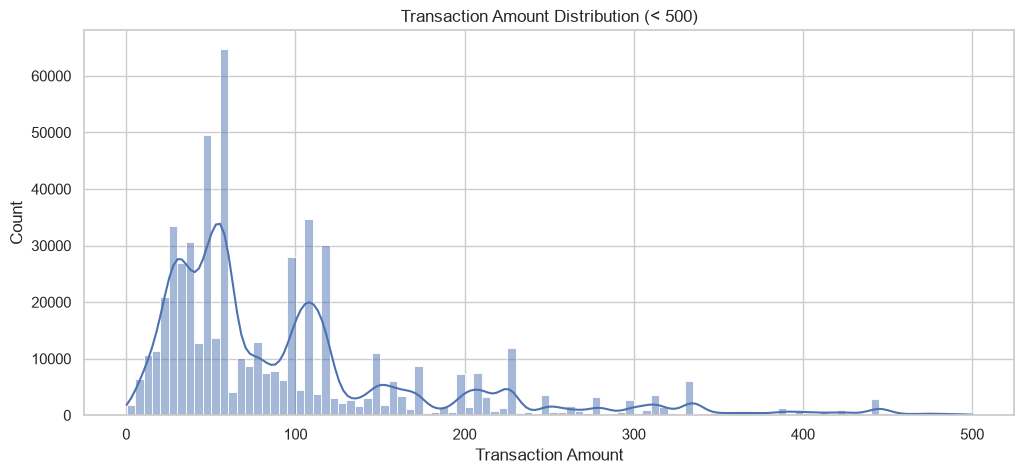

In [21]:
plt.figure(figsize=(12, 5))
sns.histplot(trans_df[trans_df["TransactionAmt"] < 500]["TransactionAmt"], bins=100, kde=True)
plt.title("Transaction Amount Distribution (< 500)")
plt.xlabel("Transaction Amount")
plt.show()

Most transactions are concentrated below 150, on several noticeable peaks, indicating that transaction amounts are not normally distributed. The distribution is positively skewed, with fewer transactions occurring at higher amounts.

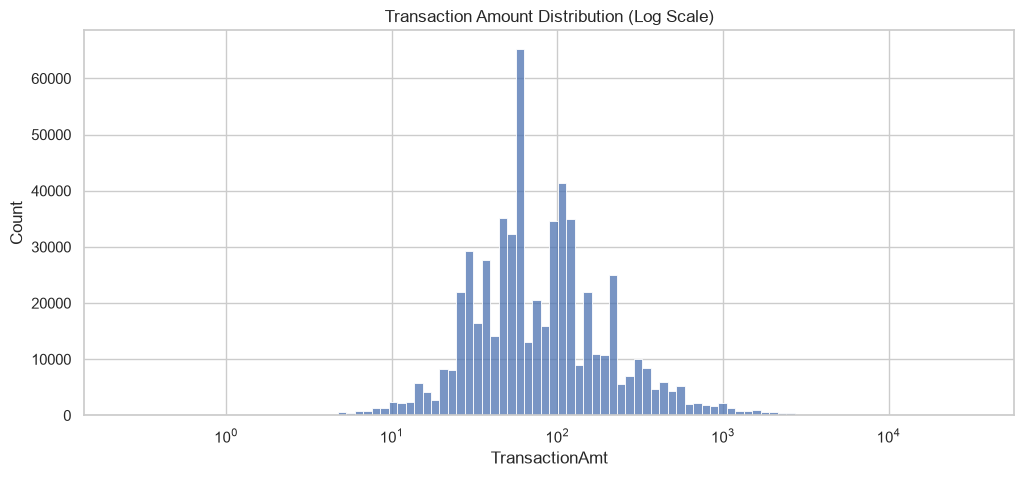

In [22]:
plt.figure(figsize=(12, 5))
sns.histplot(trans_df["TransactionAmt"], bins=100, log_scale=True)
plt.title("Transaction Amount Distribution (Log Scale)")
plt.show()

Applying a logarithmic scale reveals the distribution of transaction amounts across multiple orders of magnitude. Although extreme values exist, the majority of transactions remain concentrated at relatively low amounts.

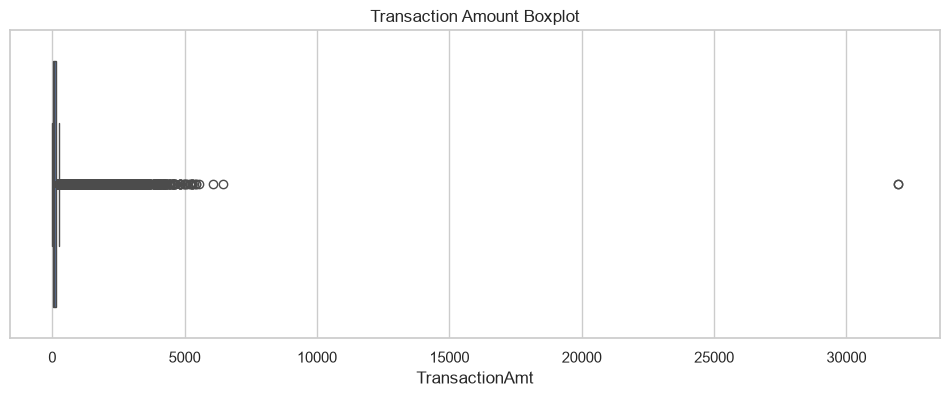

In [23]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=trans_df["TransactionAmt"])
plt.title("Transaction Amount Boxplot")
plt.show()

The boxplot reveals a large number of outliers in the TransactionAmt feature. Most transactions are concentrated within a relatively small range, while a limited number of transactions have exceptionally high amounts. Since this is a fraud detection problem, these extreme values may carry important information and should not be removed without further investigation.

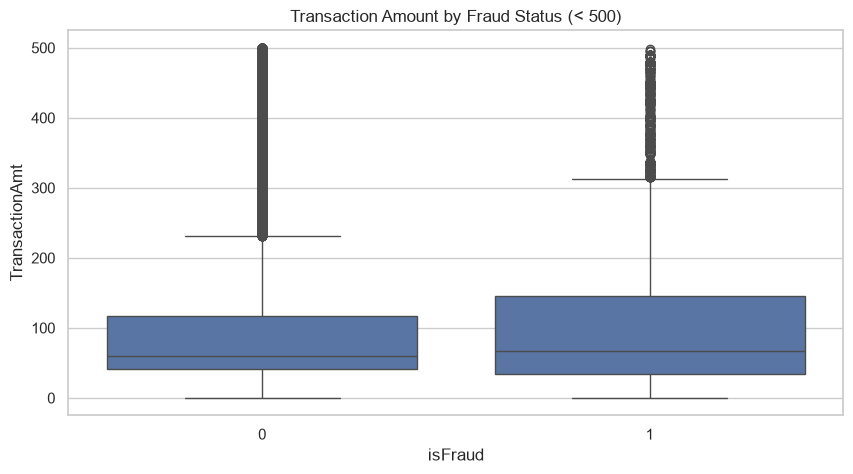

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=trans_df[trans_df["TransactionAmt"] < 500], x="isFraud", y="TransactionAmt")
plt.title("Transaction Amount by Fraud Status (< 500)")
plt.show()

Fraudulent transactions generally exhibit a wider spread in transaction amounts compared to legitimate transactions. The median transaction amount is slightly higher for fraudulent transactions, and the interquartile range (IQR) is larger, indicating greater variability. Both classes contain outliers, but fraudulent transactions tend to have higher transaction amounts overall.

### 4.3 Categorical Features

In [25]:
trans_df["ProductCD"].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

The ProductCD feature is imbalanced, with Product W representing the majority of transactions, while Product S has the fewest records. This indicates that transaction frequencies vary considerably across different product categories.

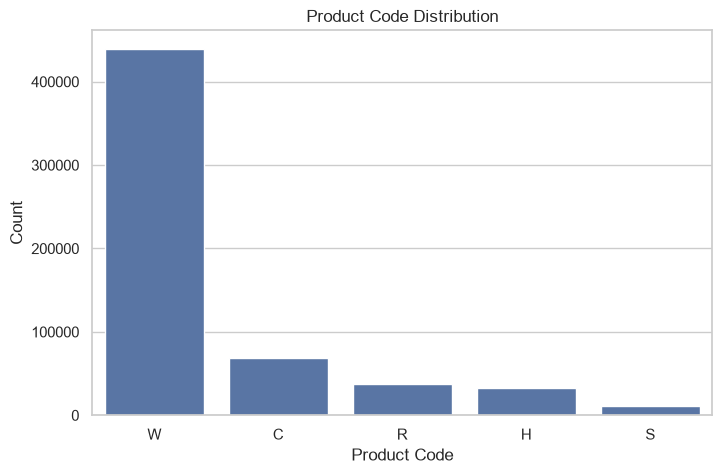

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(data=trans_df, x="ProductCD", order=trans_df["ProductCD"].value_counts().index)
plt.title("Product Code Distribution")
plt.xlabel("Product Code")
plt.ylabel("Count")
plt.show()

Product W dominates the dataset, accounting for the majority of transactions. In contrast, Product S has the fewest transactions. This indicates that the dataset is highly imbalanced across product categories, which should be considered during feature analysis.

<Axes: xlabel='ProductCD', ylabel='count'>

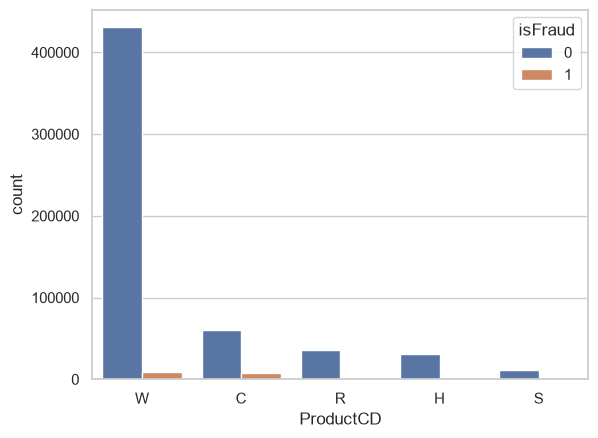

In [27]:
sns.countplot(data=trans_df, x="ProductCD", hue="isFraud", order=trans_df["ProductCD"].value_counts().index)

Although Product W contains the highest number of fraudulent transactions, this observation may be misleading because it also contains the largest number of overall transactions. Therefore, fraud rates should be calculated before drawing conclusions.

In [28]:
trans_df.groupby("ProductCD")["isFraud"].mean() * 100

ProductCD
C    11.687269
H     4.766231
R     3.782594
S     5.899553
W     2.039939
Name: isFraud, dtype: float64

Fraud rates vary significantly across product categories. Product C has the highest fraud rate (11.69%), making it the most fraud-prone category, while Product W, despite having the largest number of transactions, has the lowest fraud rate (2.04%). This suggests that ProductCD is an informative feature for fraud detection.

### 4.4 Card Network Analysis (card4)

In [29]:
trans_df["card4"].value_counts(dropna=False)

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64

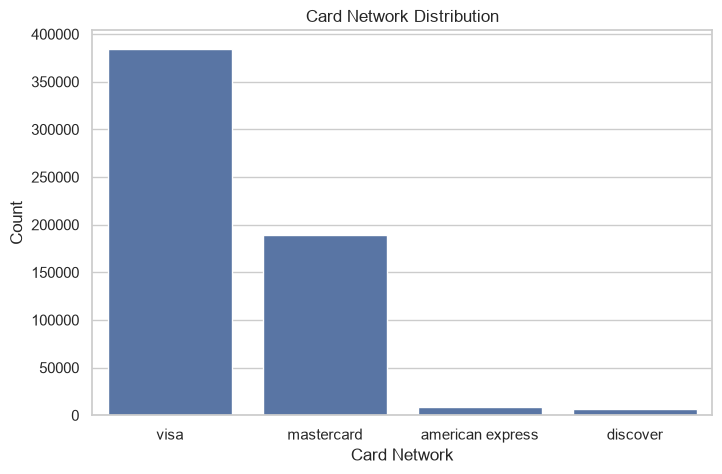

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(data=trans_df, x="card4", order=trans_df["card4"].value_counts().index)
plt.title("Card Network Distribution")
plt.xlabel("Card Network")
plt.ylabel("Count")
plt.show()

The dataset is dominated by one or two card networks, while the remaining networks appear much less frequently. This indicates an imbalanced distribution across different card networks.

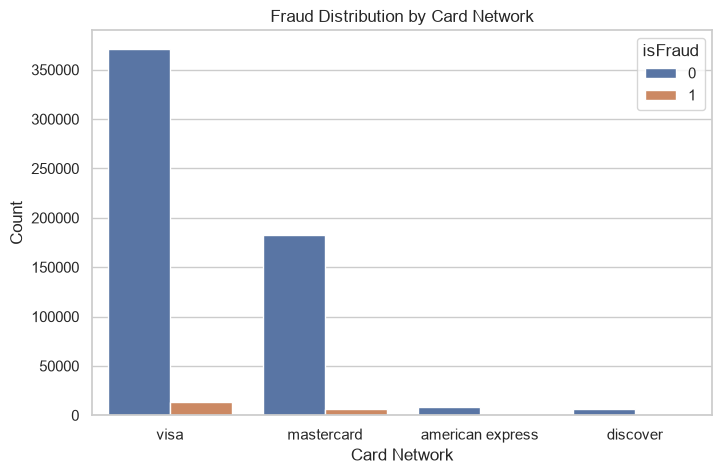

In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(data=trans_df, x="card4", hue="isFraud", order=trans_df["card4"].value_counts().index)
plt.title("Fraud Distribution by Card Network")
plt.xlabel("Card Network")
plt.ylabel("Count")
plt.show()

Although some card networks appear to contain more fraudulent transactions, this observation may simply reflect their larger number of overall transactions. Fraud rates should be calculated before drawing conclusions.

In [32]:
(trans_df.groupby("card4")["isFraud"].mean() * 100).sort_values(ascending=False)

card4
discover            7.728161
visa                3.475610
mastercard          3.433095
american express    2.869837
Name: isFraud, dtype: float64

Fraud rates differ across card networks. Discover has the highest fraud rate (7.73%), more than double the fraud rates of Visa and Mastercard, while American Express has the lowest fraud rate (2.87%). This suggests that the card4 feature carries useful information for distinguishing fraudulent transactions and should be retained during model development.

### 4.5 Card Type Analysis (card6)

In [33]:
trans_df["card6"].value_counts(dropna=False)

card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64

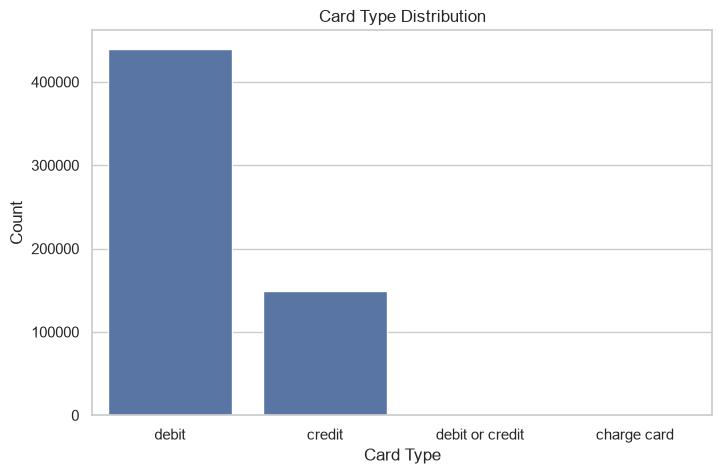

In [34]:
plt.figure(figsize=(8, 5))
sns.countplot(data=trans_df, x="card6", order=trans_df["card6"].value_counts().index)
plt.title("Card Type Distribution")
plt.xlabel("Card Type")
plt.ylabel("Count")
plt.show()

Debit cards dominate the dataset, accounting for nearly three-quarters of all transactions, while Credit cards represent a much smaller portion. The remaining card types are extremely rare and have negligible representation.

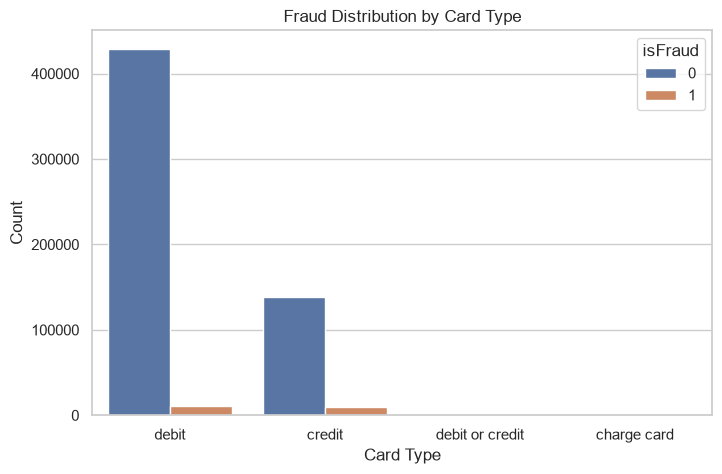

In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(data=trans_df, x="card6", hue="isFraud", order=trans_df["card6"].value_counts().index)
plt.title("Fraud Distribution by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Count")
plt.show()

Debit cards contain the highest number of fraudulent transactions in absolute terms. However, this is expected because Debit cards also account for the majority of all transactions. Therefore, fraud rates must be analyzed before making any conclusions.

In [36]:
(trans_df.groupby("card6")["isFraud"].mean() * 100).sort_values(ascending=False)

card6
credit             6.678480
debit              2.426251
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64

Credit cards have a significantly higher fraud rate (6.68%) compared to Debit cards (2.43%). Although Debit cards generate more fraudulent transactions in absolute numbers, Credit cards are considerably more likely to be involved in fraudulent activity. This indicates that card6 is a valuable predictive feature for fraud detection.

### 4.6 Card Information Analysis (card3)

In [37]:
trans_df["card3"].describe()

count    588975.000000
mean        153.194925
std          11.336444
min         100.000000
25%         150.000000
50%         150.000000
75%         150.000000
max         231.000000
Name: card3, dtype: float64

The card3 feature is highly concentrated around the value 150, with a median and third quartile both equal to 150. This indicates that the distribution is extremely imbalanced, where one encoded value dominates the majority of transactions.

In [38]:
trans_df["card3"].value_counts(dropna=False).head(20)

card3
150.0    521287
185.0     56346
106.0      1571
NaN        1565
144.0      1252
146.0      1252
117.0       962
143.0       899
119.0       750
102.0       460
147.0       390
162.0       339
203.0       253
213.0       221
100.0       202
200.0       184
188.0       175
131.0       172
134.0       166
149.0       127
Name: count, dtype: int64

The value 150 overwhelmingly dominates the card3 feature, representing nearly 88% of all observations. Most of the remaining values appear infrequently.

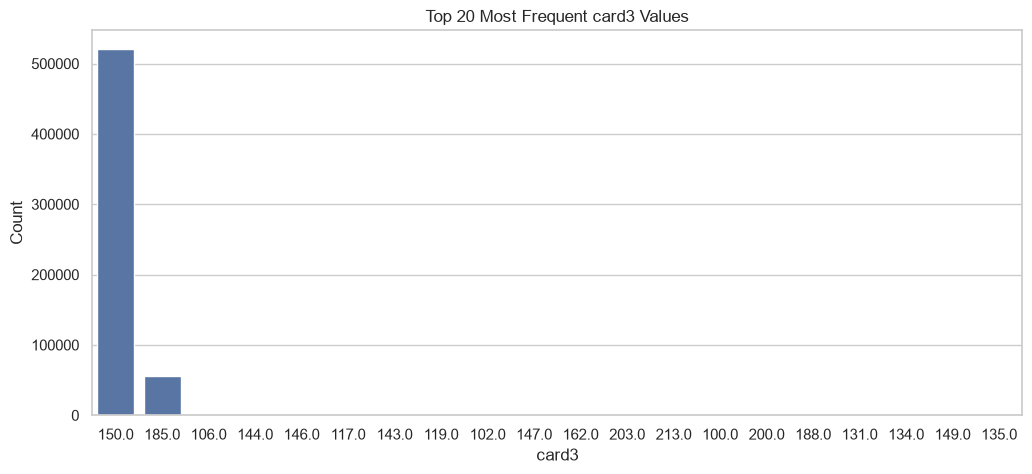

In [39]:
plt.figure(figsize=(12, 5))
sns.countplot(data=trans_df, x="card3", order=trans_df["card3"].value_counts().head(20).index)
plt.title("Top 20 Most Frequent card3 Values")
plt.xlabel("card3")
plt.ylabel("Count")
plt.show()

The visual distribution confirms that card3 is highly imbalanced, with one dominant category and many low-frequency categories.

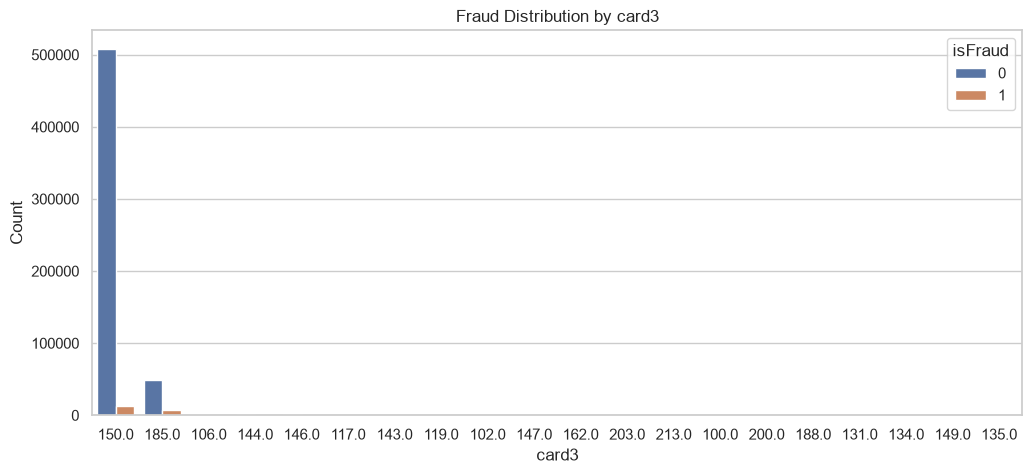

In [40]:
plt.figure(figsize=(12, 5))
sns.countplot(data=trans_df, x="card3", hue="isFraud", order=trans_df["card3"].value_counts().head(20).index)
plt.title("Fraud Distribution by card3")
plt.xlabel("card3")
plt.ylabel("Count")
plt.show()

Most fraudulent transactions are associated with the value 150. However, this observation is driven by its overwhelming frequency in the dataset rather than a necessarily higher fraud risk.

In [41]:
(trans_df.groupby("card3")["isFraud"].mean().sort_values(ascending=False) * 100).head(20)

card3
132.0    100.000000
125.0    100.000000
139.0    100.000000
181.0    100.000000
175.0    100.000000
224.0    100.000000
206.0    100.000000
160.0    100.000000
208.0     50.000000
191.0     38.888889
155.0     33.333333
223.0     25.454545
167.0     25.000000
118.0     23.529412
129.0     22.222222
157.0     20.000000
198.0     19.354839
182.0     17.948718
231.0     16.666667
127.0     14.285714
Name: isFraud, dtype: float64

In [42]:
card3_stats = (trans_df.groupby("card3").agg(Transactions=("isFraud", "count"), FraudRate=("isFraud", "mean")))
card3_stats["FraudRate"] *= 100
card3_stats[card3_stats["Transactions"] >= 100].sort_values("FraudRate", ascending=False)

,Transactions,FraudRate
card3,,
185.0,56346,13.065701
119.0,750,9.333333
144.0,1252,8.945687
134.0,166,6.626506
135.0,120,5.000000
100.0,202,4.950495
188.0,175,3.428571
143.0,899,3.114572
210.0,104,2.884615


After excluding low-frequency categories, card3 still shows meaningful differences in fraud rates. Value 185 has the highest fraud rate (13.07%) among frequently occurring values, followed by 119 (9.33%) and 144 (8.95%). In contrast, the dominant value 150, despite representing nearly 88% of all transactions, has a relatively low fraud rate (2.46%). This indicates that card3 contains useful information for fraud detection and should be retained as a predictive feature.

### 4.7 Card Information Analysis (card5)

In [43]:
trans_df["card5"].describe()

count    586281.000000
mean        199.278897
std          41.244453
min         100.000000
25%         166.000000
50%         226.000000
75%         226.000000
max         237.000000
Name: card5, dtype: float64

The card5 feature ranges from 100 to 237, with the median and third quartile both equal to 226, indicating that a small number of encoded values dominate the dataset.

In [44]:
trans_df["card5"].value_counts(dropna=False).head(20)

card5
226.0    296546
224.0     81513
166.0     57140
102.0     29105
117.0     25941
138.0     19737
195.0     16945
137.0     11720
126.0     10298
219.0      9924
202.0      7103
162.0      4524
NaN        4259
229.0      2048
197.0      1551
150.0      1338
100.0       978
223.0       936
118.0       752
190.0       744
Name: count, dtype: int64

The card5 feature is highly imbalanced. The value 226 is the most frequent category, followed by 224 and 166, while many other values occur much less frequently.

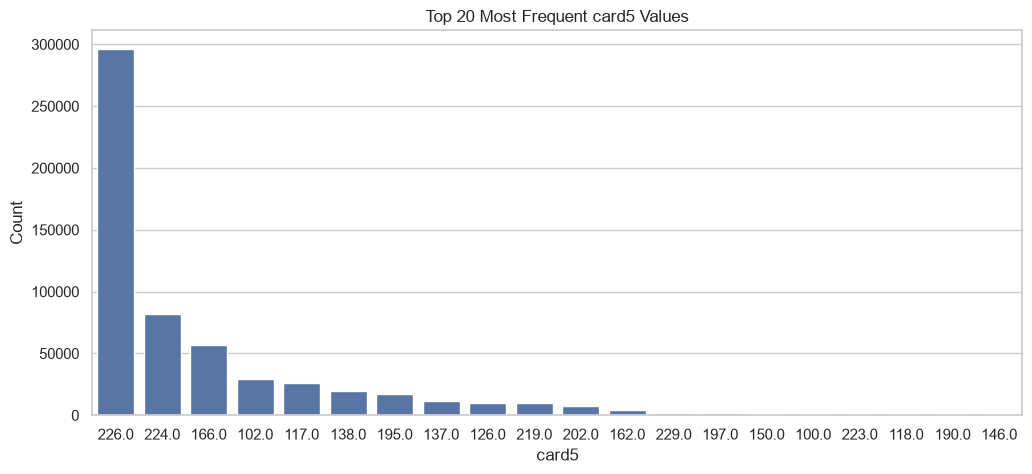

In [45]:
plt.figure(figsize=(12, 5))
sns.countplot(data=trans_df, x="card5", order=trans_df["card5"].value_counts().head(20).index)
plt.title("Top 20 Most Frequent card5 Values")
plt.xlabel("card5")
plt.ylabel("Count")
plt.show()

The distribution of card5 is highly imbalanced. A few encoded values, particularly 226, dominate the dataset, while many other values appear much less frequently. This indicates that transactions are concentrated around a limited number of card5 categories.

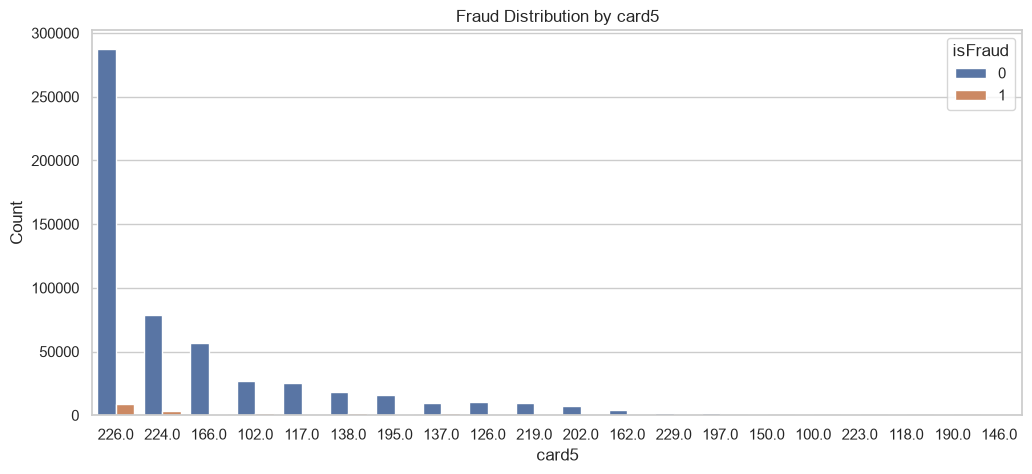

In [46]:
plt.figure(figsize=(12, 5))
sns.countplot(data=trans_df, x="card5", hue="isFraud", order=trans_df["card5"].value_counts().head(20).index)
plt.title("Fraud Distribution by card5")
plt.xlabel("card5")
plt.ylabel("Count")
plt.show()

The largest number of fraudulent transactions is observed for the value 226, mainly because it is the most frequent category in the dataset. Therefore, the absolute number of fraud cases alone is not enough for comparison, and fraud rates should be used to evaluate the actual fraud risk of each category.

In [47]:
card5_stats = (trans_df.groupby("card5").agg(Transactions=("isFraud", "count"), FraudRate=("isFraud", "mean")))
card5_stats["FraudRate"] *= 100
card5_stats[card5_stats["Transactions"] >= 100].sort_values("FraudRate", ascending=False)

,Transactions,FraudRate
card5,,
137.0,11720,14.718430
147.0,417,11.270983
141.0,341,9.384164
223.0,936,8.867521
138.0,19737,8.522065
144.0,219,7.305936
162.0,4524,6.653404
203.0,428,6.542056
102.0,29105,6.294451


The fraud rate varies substantially across card5 values. For example, value 137 has a fraud rate of 14.72%, while the most common value 226 has a much lower fraud rate of 2.95%. This demonstrates that card5 carries valuable predictive information and may significantly improve fraud detection performance.

### 4.8 Card Information Analysis (card2)

In [48]:
trans_df["card2"].describe()

count    581607.000000
mean        362.555488
std         157.793246
min         100.000000
25%         214.000000
50%         361.000000
75%         512.000000
max         600.000000
Name: card2, dtype: float64

The card2 feature spans a wide numerical range (100–600), indicating high variability across encoded card values. Unlike card3 and card5, no single value dominates the distribution.

In [49]:
trans_df["card2"].value_counts(dropna=False).head(20)

card2
321.0    48935
111.0    45191
555.0    41995
490.0    38145
583.0    21803
170.0    18214
194.0    16938
545.0    16355
360.0    15190
514.0    14541
174.0    11310
512.0    10126
NaN       8933
408.0     8012
361.0     7827
100.0     7570
225.0     7445
215.0     7281
399.0     7180
553.0     6495
Name: count, dtype: int64

The distribution of card2 is more balanced than previous card-related features. Although some values appear more frequently than others, the transactions are spread across many different encoded values

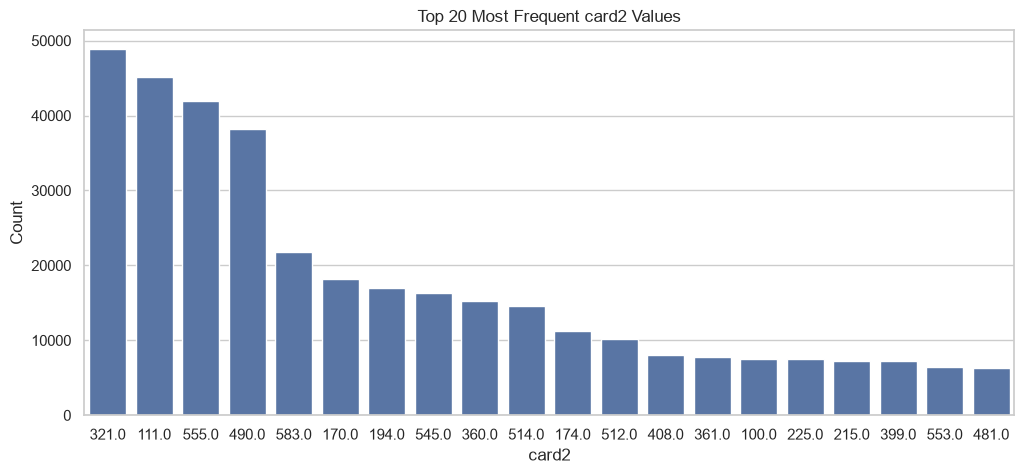

In [50]:
plt.figure(figsize=(12, 5))
sns.countplot(data=trans_df, x="card2", order=trans_df["card2"].value_counts().head(20).index)
plt.title("Top 20 Most Frequent card2 Values")
plt.xlabel("card2")
plt.ylabel("Count")
plt.show()

Unlike card3 and card5, the card2 feature does not have a single dominant category. Instead, transactions are distributed across many encoded values, indicating greater diversity in this feature.

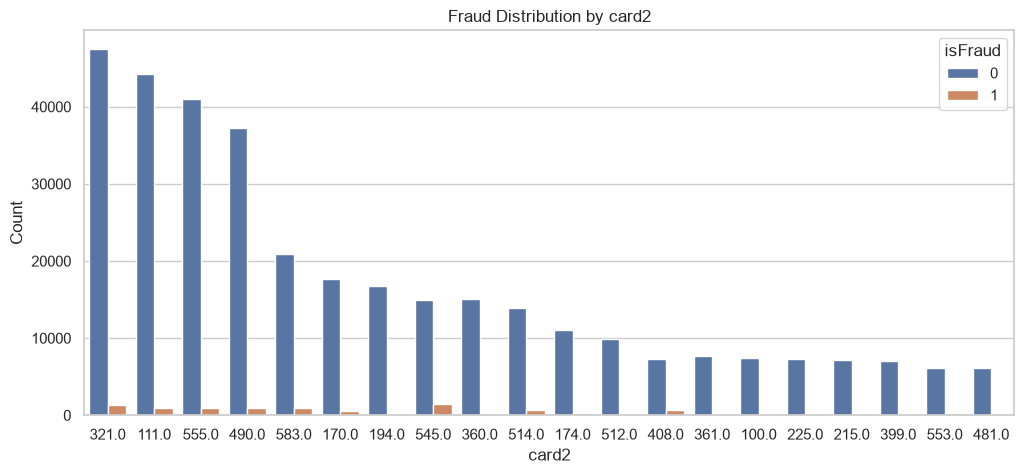

In [51]:
plt.figure(figsize=(12, 5))
sns.countplot(data=trans_df, x="card2", hue="isFraud", order=trans_df["card2"].value_counts().head(20).index)
plt.title("Fraud Distribution by card2")
plt.xlabel("card2")
plt.ylabel("Count")
plt.show()

The highest numbers of fraudulent transactions are observed in the most frequent card2 categories. However, this reflects the higher transaction volume of these categories rather than a higher fraud risk. Therefore, fraud rates provide a more reliable measure for comparison.

In [52]:
card2_stats = (trans_df.groupby("card2").agg(Transactions=("isFraud", "count"), FraudRate=("isFraud", "mean")))
card2_stats["FraudRate"] *= 100
card2_stats = (card2_stats[card2_stats["Transactions"] >= 1000].sort_values("FraudRate", ascending=False))

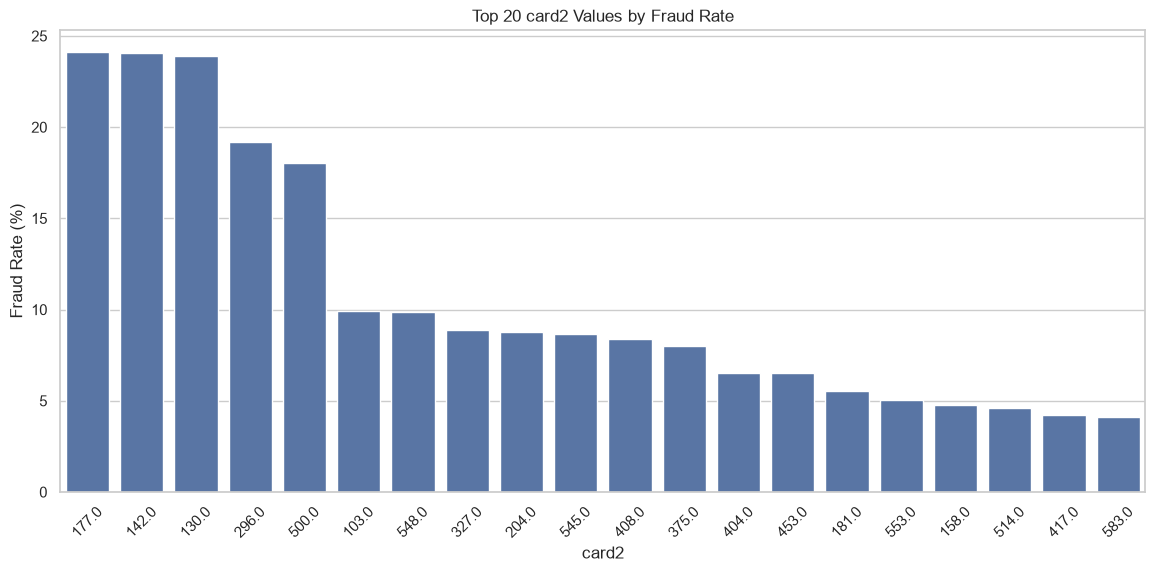

In [53]:
plt.figure(figsize=(14, 6))
top_card2 = card2_stats.head(20)
sns.barplot(data=top_card2, x=top_card2.index.astype(str), y="FraudRate")
plt.title("Top 20 card2 Values by Fraud Rate")
plt.xlabel("card2")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.show()

The fraud rate differs considerably across card2 values. Some categories consistently exhibit much higher fraud rates than others, suggesting that card2 is a strong discriminative feature for identifying fraudulent transactions.

In [54]:
card2_stats = (trans_df.groupby("card2").agg(Transactions=("isFraud", "count"), FraudRate=("isFraud", "mean")))
card2_stats["FraudRate"] *= 100
card2_stats[card2_stats["Transactions"] >= 1000].sort_values("FraudRate", ascending=False)

,Transactions,FraudRate
card2,,
177.0,1642,24.116931
142.0,1685,24.035608
130.0,2746,23.925710
296.0,2516,19.197138
500.0,5045,18.057483
103.0,3468,9.948097
548.0,1082,9.889094
327.0,5100,8.862745
204.0,2994,8.750835


The card2 feature exhibits large variation in fraud rates across its encoded values. For example, values 177, 142, and 130 have fraud rates exceeding 23%, whereas values such as 302, 558, and 517 have fraud rates below 0.3%. This large variation suggests that card2 contains strong predictive information and should be retained as an important feature for fraud detection.

### 4.9 Card Information Analysis (card1)

In [55]:
trans_df["card1"].describe()

count    590540.000000
mean       9898.734658
std        4901.170153
min        1000.000000
25%        6019.000000
50%        9678.000000
75%       14184.000000
max       18396.000000
Name: card1, dtype: float64

The card1 feature spans a wide numerical range (1,000–18,396), indicating high variability among encoded card identifiers. The large standard deviation also suggests that transactions are distributed across many different card values.

In [56]:
trans_df["card1"].nunique()

13553

The card1 feature contains 13,553 unique values, making it the highest-cardinality feature analyzed so far. Such a large number of unique categories requires careful handling during feature engineering and model training.

In [57]:
trans_df["card1"].value_counts(dropna=False).head(20)

card1
7919     14932
9500     14162
15885    10361
17188    10344
15066     7945
12695     7091
12544     6773
6019      6771
2803      6141
7585      5334
10616     5172
12839     5129
3154      4614
2616      4410
18132     4209
9633      4158
15497     3977
16132     3929
2884      3873
16075     3748
Name: count, dtype: int64

Although card1 has thousands of unique values, a relatively small number of card identifiers appear much more frequently than the others. This indicates that transaction activity is concentrated around a subset of cards.

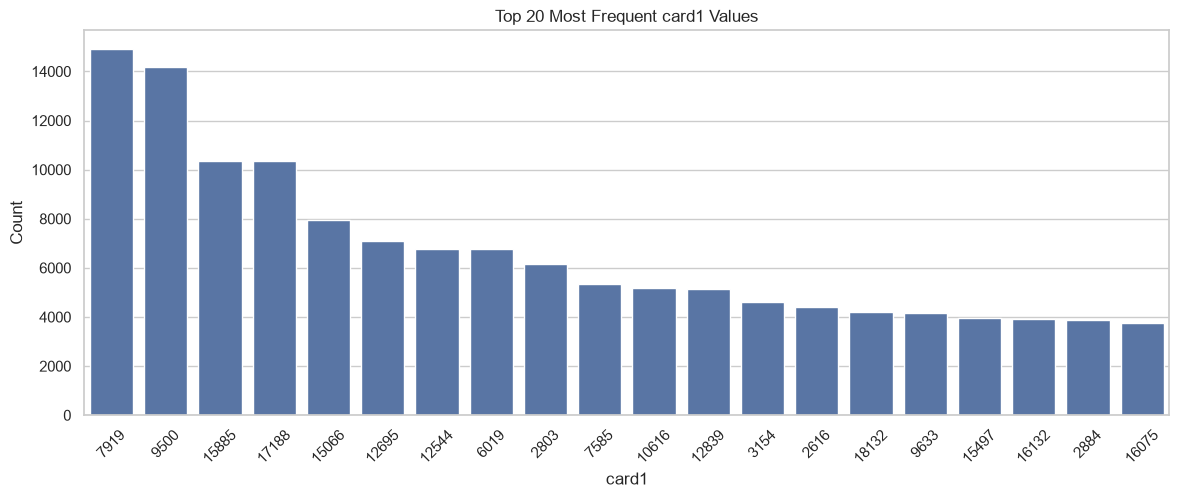

In [58]:
plt.figure(figsize=(14, 5))
sns.countplot(data=trans_df, x="card1", order=trans_df["card1"].value_counts().head(20).index)
plt.title("Top 20 Most Frequent card1 Values")
plt.xlabel("card1")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The countplot confirms that only a limited number of card1 values dominate the dataset, while the majority of card identifiers occur much less frequently.

In [59]:
card1_stats = (trans_df.groupby("card1").agg(Transactions=("isFraud", "count"), FraudRate=("isFraud", "mean")))
card1_stats["FraudRate"] *= 100
card1_stats = (card1_stats[card1_stats["Transactions"] >= 1000].sort_values("FraudRate", ascending=False))
card1_stats

,Transactions,FraudRate
card1,,
9026,2076,19.123314
8755,1110,17.927928
9633,4158,17.845118
2256,1343,17.498138
16062,1013,14.215202
...,...,...
6550,1183,0.422654
16560,2080,0.336538
6530,2714,0.294768


Fraud rates vary significantly across card1 values. Several card identifiers exhibit fraud rates exceeding 15%, while others have fraud rates close to zero despite having more than one thousand transactions. This confirms that card1 is a highly informative feature for fraud prediction.

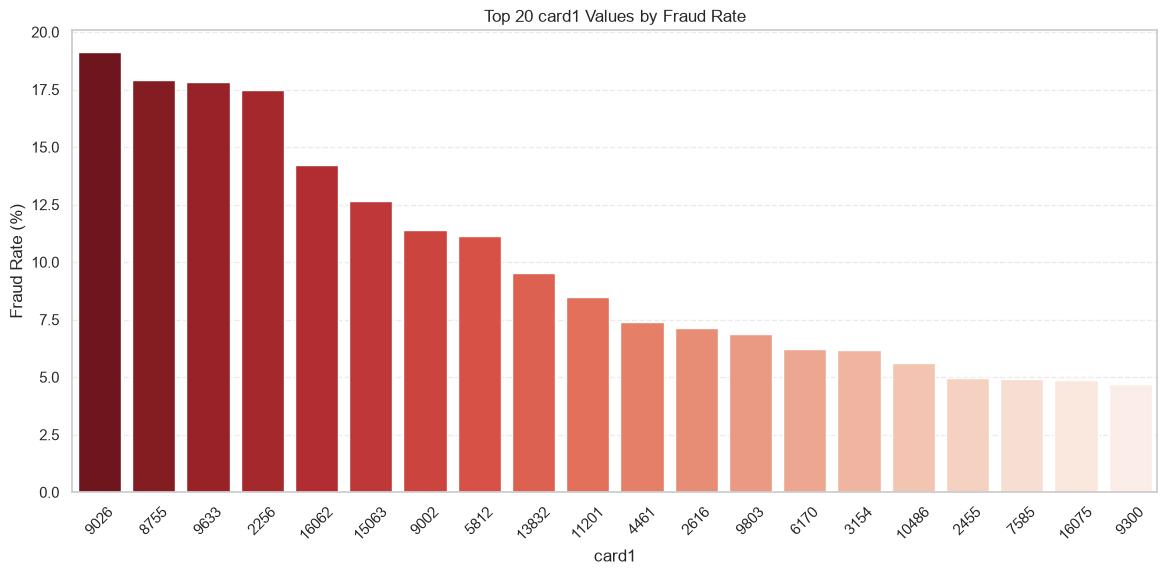

In [60]:
plt.figure(figsize=(14, 6))
top_card1 = card1_stats.head(20)
sns.barplot(data=top_card1, x=top_card1.index.astype(str), y="FraudRate", hue=top_card1.index.astype(str),palette="Reds_r", legend=False)
plt.title("Top 20 card1 Values by Fraud Rate")
plt.xlabel("card1")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

The fraud rate differs dramatically across card1 values. Some card identifiers have fraud rates above 19%, while others remain close to 0% despite having more than one thousand transactions. This indicates that card1 is a highly informative feature for distinguishing fraudulent transactions.

### 4.10 Purchaser Email Domain Analysis (P_emaildomain)

In [61]:
trans_df["P_emaildomain"].value_counts(dropna=False).head(20)

P_emaildomain
gmail.com        228355
yahoo.com        100934
NaN               94456
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
live.com           3041
sbcglobal.net      2970
verizon.net        2705
ymail.com          2396
bellsouth.net      1909
yahoo.com.mx       1543
me.com             1522
cox.net            1393
optonline.net      1011
Name: count, dtype: int64

The purchaser email domains are highly concentrated in a few providers. Gmail and Yahoo dominate the dataset, while a large number of transactions have missing purchaser email information, indicating that email addresses are not available for every transaction.

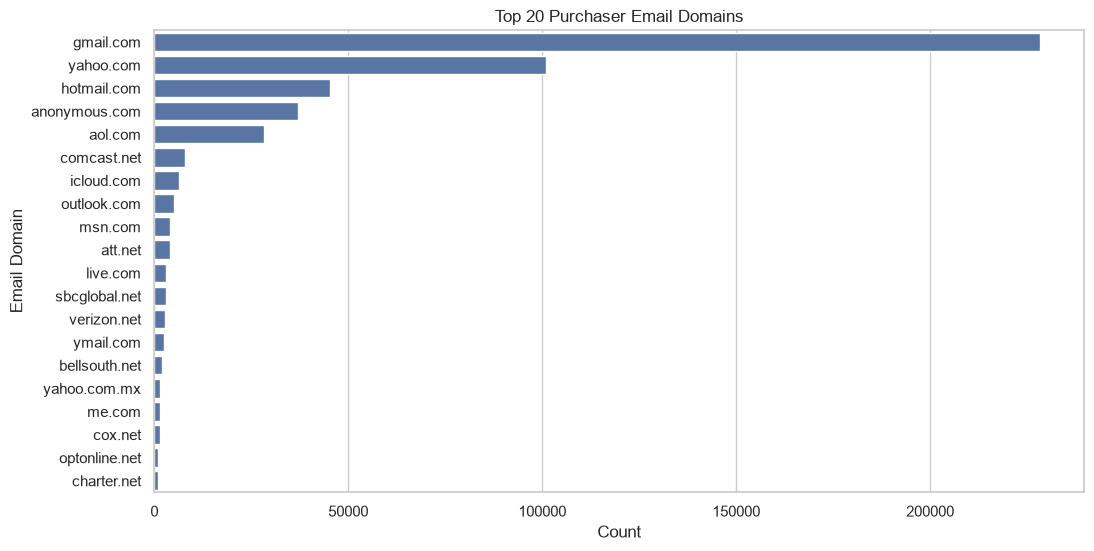

In [62]:
plt.figure(figsize=(12, 6))
sns.countplot(data=trans_df, y="P_emaildomain", order=trans_df["P_emaildomain"].value_counts().head(20).index)
plt.title("Top 20 Purchaser Email Domains")
plt.xlabel("Count")
plt.ylabel("Email Domain")
plt.show()

The countplot confirms that Gmail is the most frequently used email provider, followed by Yahoo and Hotmail. The distribution is highly imbalanced, with only a few providers accounting for the majority of transactions.

In [63]:
email_stats = (trans_df.groupby("P_emaildomain").agg(Transactions=("isFraud", "count"), FraudRate=("isFraud", "mean")))
email_stats["FraudRate"] *= 100
email_stats = (email_stats[email_stats["Transactions"] >= 1000].sort_values("FraudRate", ascending=False))
email_stats

,Transactions,FraudRate
P_emaildomain,,
outlook.com,5096,9.458399
hotmail.com,45250,5.295028
gmail.com,228355,4.354185
icloud.com,6267,3.143450
comcast.net,7888,3.118661
bellsouth.net,1909,2.776323
live.com,3041,2.762249
anonymous.com,36998,2.321747
yahoo.com,100934,2.275745


Fraud rates vary across different email providers. Outlook.com has the highest fraud rate (9.46%), followed by Hotmail (5.30%) and Gmail (4.35%), while providers such as SBCGlobal and AT&T have fraud rates below 1%. This suggests that the purchaser's email domain is a useful feature for fraud detection.

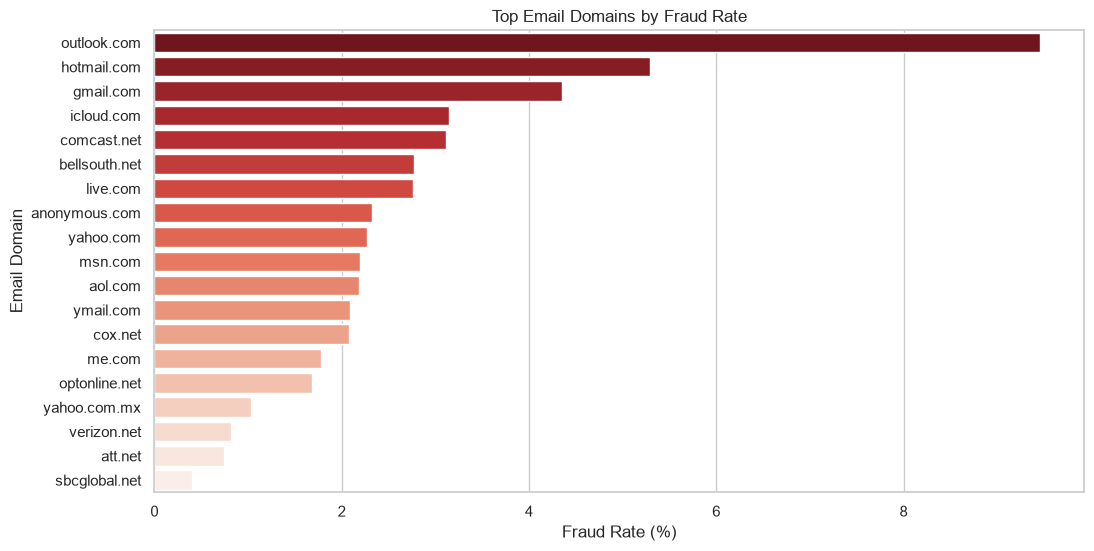

In [64]:
plt.figure(figsize=(12, 6))
top_email = email_stats.head(20)
sns.barplot(data=top_email, x="FraudRate", y=top_email.index, hue=top_email.index, palette="Reds_r", legend=False)
plt.title("Top Email Domains by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Email Domain")
plt.show()

The fraud rate visualization highlights clear differences between email providers. Some domains are associated with substantially higher fraud rates despite processing fewer transactions, indicating that email provider can help distinguish high-risk transactions.

### 4.11 Recipient Email Domain Analysis (R_emaildomain)

In [65]:
trans_df["R_emaildomain"].value_counts(dropna=False).head(20)

R_emaildomain
NaN              453249
gmail.com         57147
hotmail.com       27509
anonymous.com     20529
yahoo.com         11842
aol.com            3701
outlook.com        2507
comcast.net        1812
yahoo.com.mx       1508
icloud.com         1398
msn.com             852
live.com            762
live.com.mx         754
verizon.net         620
me.com              556
sbcglobal.net       552
cox.net             459
outlook.es          433
att.net             430
bellsouth.net       422
Name: count, dtype: int64

Most transactions do not contain recipient email information, with over 450 thousand missing values. This indicates that recipient email addresses are unavailable for the majority of transactions and may only be recorded under specific conditions.

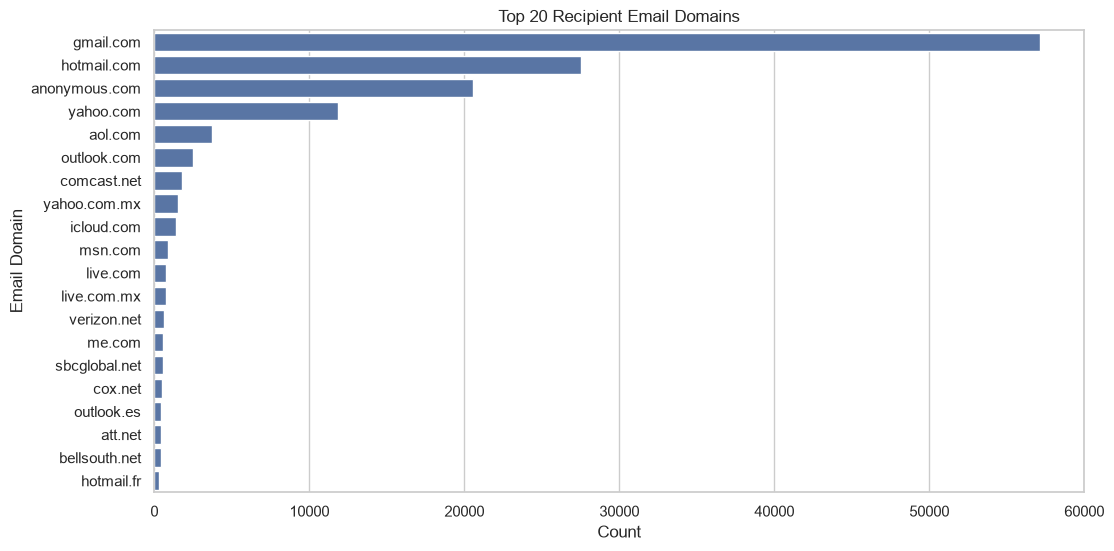

In [66]:
plt.figure(figsize=(12, 6))
sns.countplot(data=trans_df, y="R_emaildomain", order=trans_df["R_emaildomain"].value_counts().head(20).index)
plt.title("Top 20 Recipient Email Domains")
plt.xlabel("Count")
plt.ylabel("Email Domain")
plt.show()

Among transactions with available recipient email information, Gmail is the most common provider, followed by Hotmail and Anonymous. Only a limited number of email providers account for most recipient email addresses.

In [67]:
r_email_stats = (trans_df.groupby("R_emaildomain").agg(Transactions=("isFraud", "count"), FraudRate=("isFraud", "mean")))
r_email_stats["FraudRate"] *= 100
r_email_stats = (r_email_stats[r_email_stats["Transactions"] >= 1000].sort_values("FraudRate", ascending=False))
r_email_stats

,Transactions,FraudRate
R_emaildomain,,
outlook.com,2507,16.513761
icloud.com,1398,12.875536
gmail.com,57147,11.918386
hotmail.com,27509,7.779272
yahoo.com,11842,5.151157
aol.com,3701,3.485544
anonymous.com,20529,2.912952
comcast.net,1812,1.158940
yahoo.com.mx,1508,1.061008


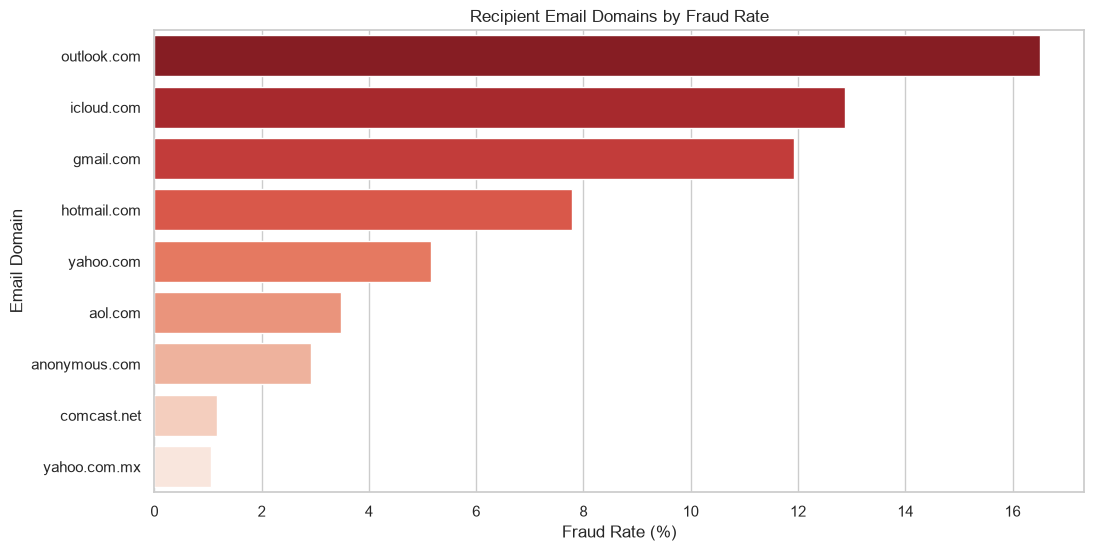

In [68]:
plt.figure(figsize=(12, 6))
top_r_email = r_email_stats.head(20)
sns.barplot(data=top_r_email, x="FraudRate", y=top_r_email.index, hue=top_r_email.index, palette="Reds_r", legend=False)
plt.title("Recipient Email Domains by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Email Domain")
plt.show()

Recipient email domains show even stronger differences in fraud rates than purchaser email domains. Outlook.com, iCloud, and Gmail exhibit substantially higher fraud rates, suggesting that recipient email information may be a stronger predictor of fraudulent transactions.

### 4.12 M Features Analysis (M1 - M9)

In [69]:
m_cols = [f"M{i}" for i in range(1, 10)]
for col in m_cols:
    print("=" * 60)
    print(col)
    print(trans_df[col].value_counts(dropna=False))
    print()

M1
M1
T      319415
NaN    271100
F          25
Name: count, dtype: int64

M2
M2
T      285468
NaN    271100
F       33972
Name: count, dtype: int64

M3
M3
NaN    271100
T      251731
F       67709
Name: count, dtype: int64

M4
M4
NaN    281444
M0     196405
M2      59865
M1      52826
Name: count, dtype: int64

M5
M5
NaN    350482
F      132491
T      107567
Name: count, dtype: int64

M6
M6
F      227856
T      193324
NaN    169360
Name: count, dtype: int64

M7
M7
NaN    346265
F      211374
T       32901
Name: count, dtype: int64

M8
M8
NaN    346252
F      155251
T       89037
Name: count, dtype: int64

M9
M9
NaN    346252
T      205656
F       38632
Name: count, dtype: int64



The M features contain only a small number of categorical values, mainly "T", "F", and missing values. Most M features have a large proportion of missing data, while some are dominated by a single category. This suggests that these variables may represent optional transaction information rather than mandatory fields.

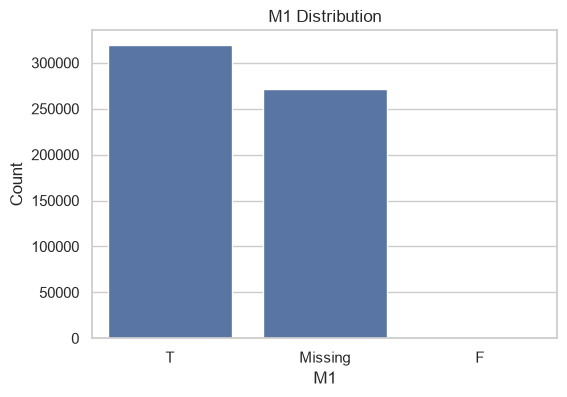

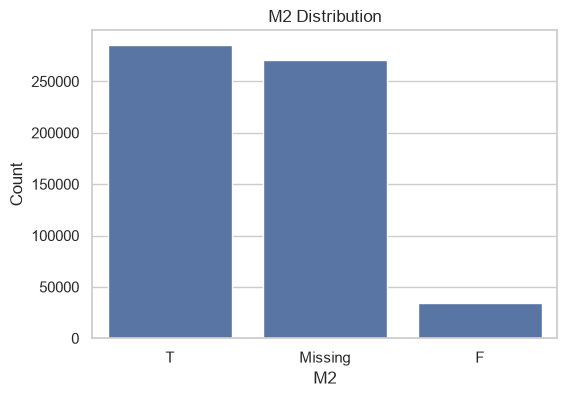

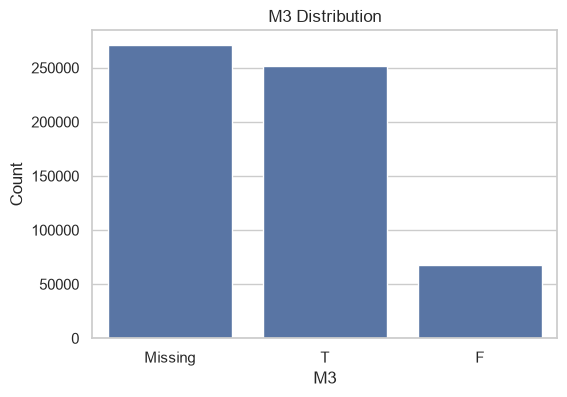

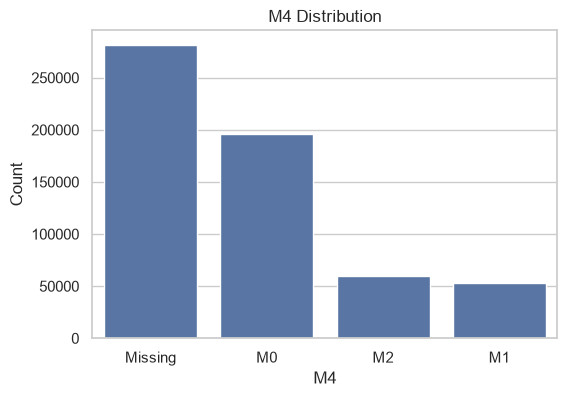

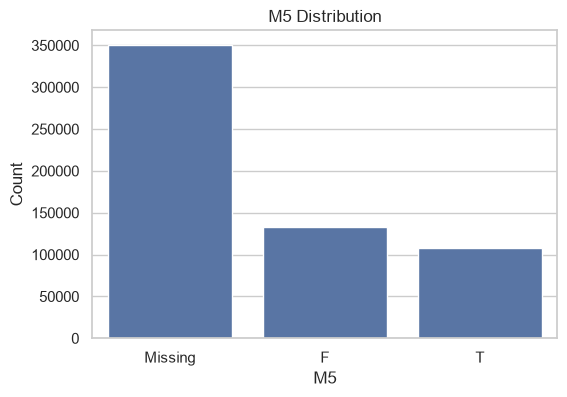

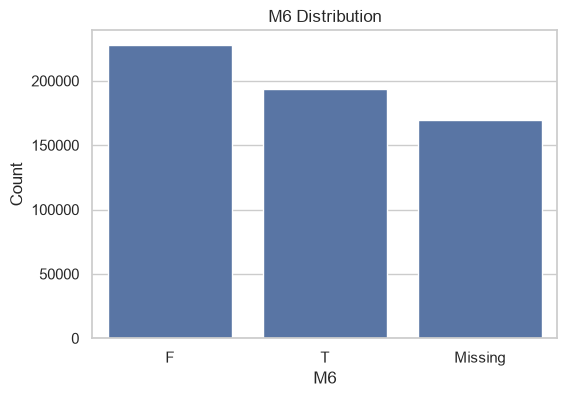

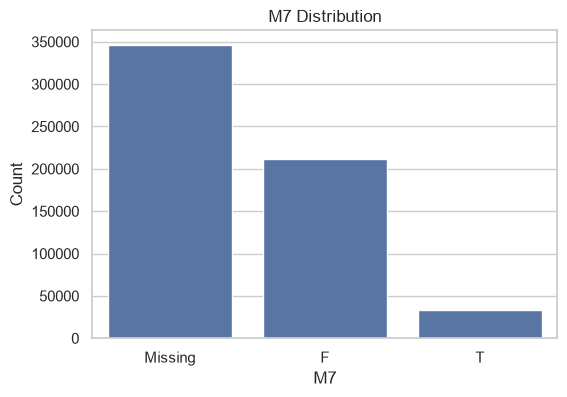

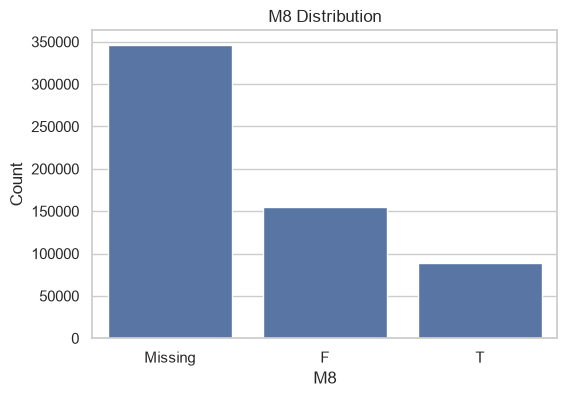

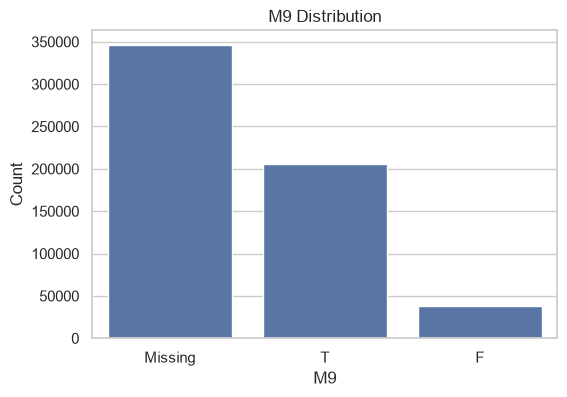

In [70]:
m_cols = [f"M{i}" for i in range(1, 10)]
for col in m_cols:
    plt.figure(figsize=(6, 4))
    plot_df = trans_df.copy()
    plot_df[col] = plot_df[col].fillna("Missing")
    sns.countplot(data=plot_df, x=col, order=plot_df[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

The countplots confirm that most M features are highly imbalanced. Missing values represent a significant portion of the dataset, while one category usually dominates the remaining observations. This imbalance should be considered during feature engineering.

In [71]:
m_cols = [f"M{i}" for i in range(1, 10)]
for col in m_cols:
    stats = (trans_df.groupby(col, dropna=False).agg(Transactions=("isFraud", "count"), FraudRate=("isFraud", "mean")))
    stats["FraudRate"] *= 100
    print("=" * 60)
    print(col)
    display(stats)

M1


,Transactions,FraudRate
M1,,
F,25,0.000000
T,319415,1.985505
NaN,271100,5.282553


M2


,Transactions,FraudRate
M2,,
F,33972,3.485223
T,285468,1.806858
NaN,271100,5.282553


M3


...

,Transactions,FraudRate
M7,,
F,211374,1.934486
T,32901,2.212699
NaN,346265,4.576264


M8


,Transactions,FraudRate
M8,,
F,155251,2.172611
T,89037,1.621798
NaN,346252,4.576436


M9


,Transactions,FraudRate
M9,,
F,38632,3.000104
T,205656,1.778698
NaN,346252,4.576436


Fraud rates differ considerably across the M feature categories. In several M features, missing values exhibit higher fraud rates than the observed categories, indicating that the absence of information may itself be associated with fraudulent behavior. Among all M features, M4 stands out, as category "M2" records the highest fraud rate (11.37%), making it one of the strongest fraud indicators in this feature group.

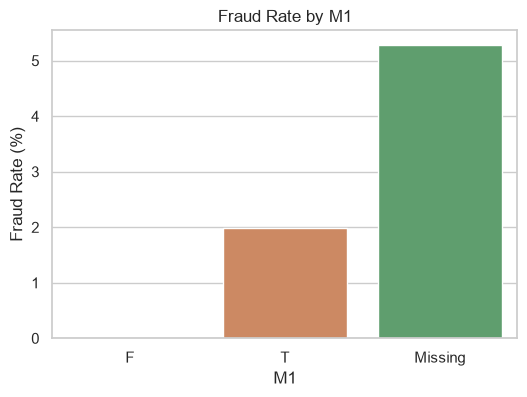

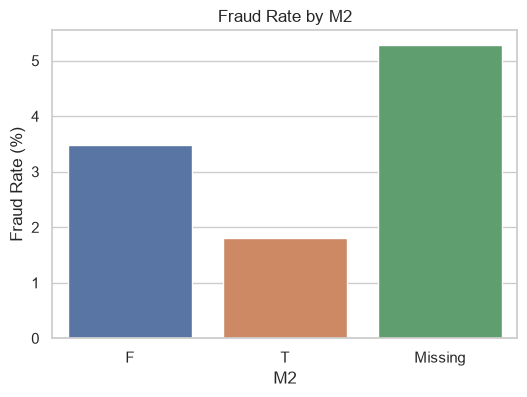

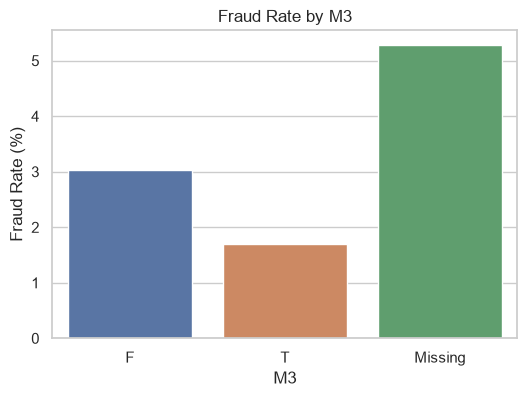

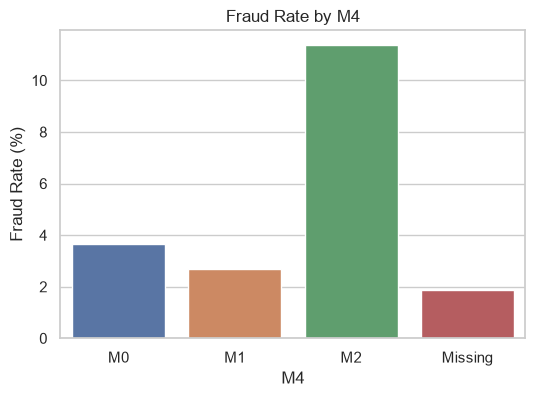

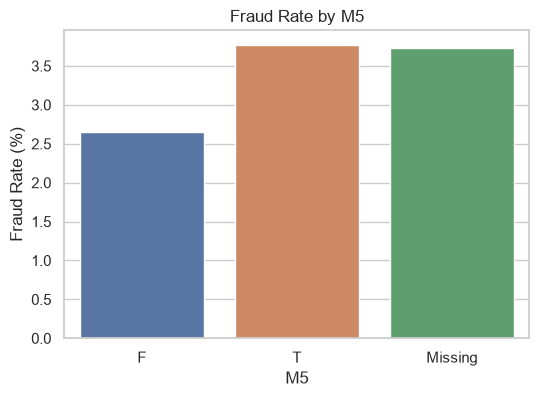

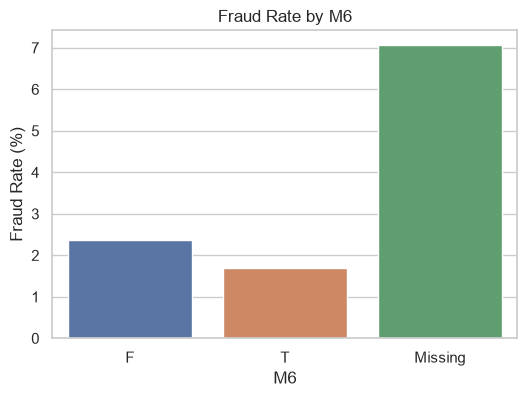

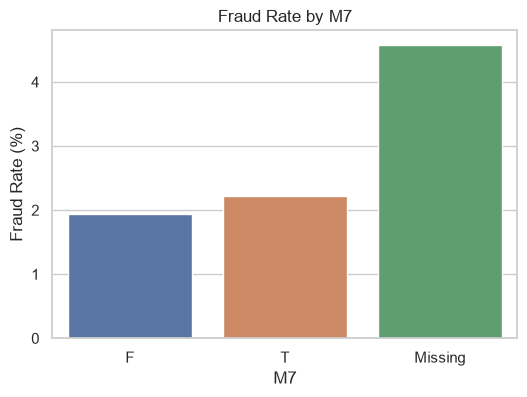

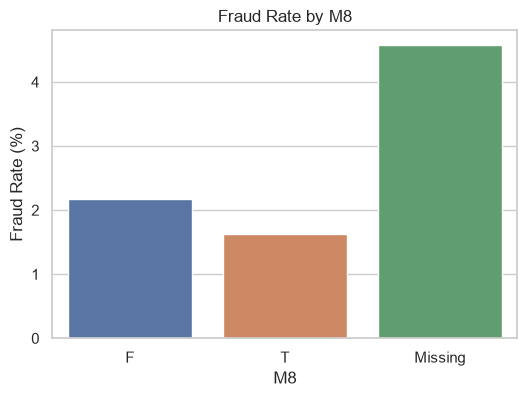

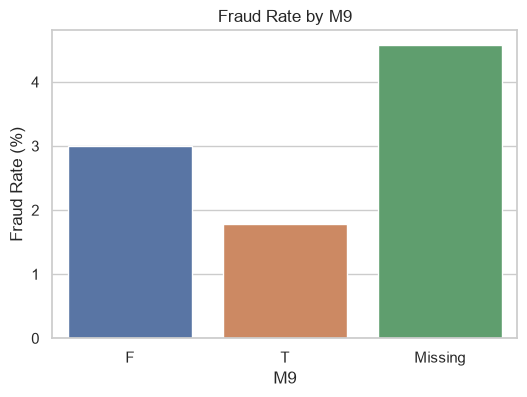

In [72]:
m_cols = [f"M{i}" for i in range(1, 10)]
for col in m_cols:
    stats = (trans_df.groupby(col, dropna=False).agg(FraudRate=("isFraud", "mean")).reset_index())
    stats["FraudRate"] *= 100
    stats[col] = stats[col].fillna("Missing")
    plt.figure(figsize=(6, 4))
    sns.barplot(data=stats, x=col, y="FraudRate", hue=col, legend=False)
    plt.title(f"Fraud Rate by {col}")
    plt.ylabel("Fraud Rate (%)")
    plt.show()

The fraud rate plots clearly illustrate the differences between categories across the M features. While some categories show consistently low fraud rates, others—particularly missing values and M4 category "M2"—have substantially higher fraud rates. These patterns indicate that the M features provide meaningful information for distinguishing fraudulent from legitimate transactions.

### 4.13 Address Features Analysis (addr1 & addr2)

In [73]:
addr_cols = ["addr1", "addr2"]
for col in addr_cols:
    print("=" * 60)
    print(col)
    print(trans_df[col].describe())
    print()
    print(trans_df[col].value_counts(dropna=False).head(20))
    print()

addr1
count    524834.000000
mean        290.733794
std         101.741072
min         100.000000
25%         204.000000
50%         299.000000
75%         330.000000
max         540.000000
Name: addr1, dtype: float64

addr1
NaN      65706
299.0    46335
325.0    42751
204.0    42020
264.0    39870
330.0    26287
315.0    23078
441.0    20827
272.0    20141
123.0    16105
126.0    15243
184.0    15160
337.0    15149
191.0    14979
181.0    13856
143.0     9806
476.0     9478
310.0     8486
472.0     8478
327.0     8425
Name: count, dtype: int64

addr2
count    524834.000000
mean         86.800630
std           2.690623
min          10.000000
25%          87.000000
50%          87.000000
75%          87.000000
max         102.000000
Name: addr2, dtype: float64

addr2
87.0     520481
NaN       65706
60.0       3084
96.0        638
32.0         91
65.0         82
16.0         55
31.0         47
19.0         33
26.0         25
27.0         20
59.0         17
69.0         17
34.0         16

The address features contain many unique values, suggesting that they represent geographic regions or customer locations. While addr1 is distributed across many different values, addr2 is highly concentrated in a single value (87), indicating much lower variability.

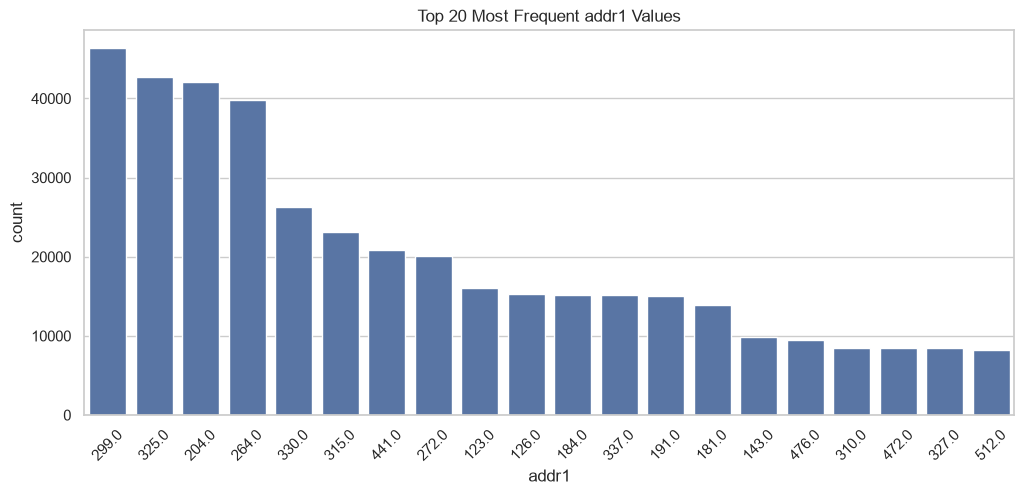

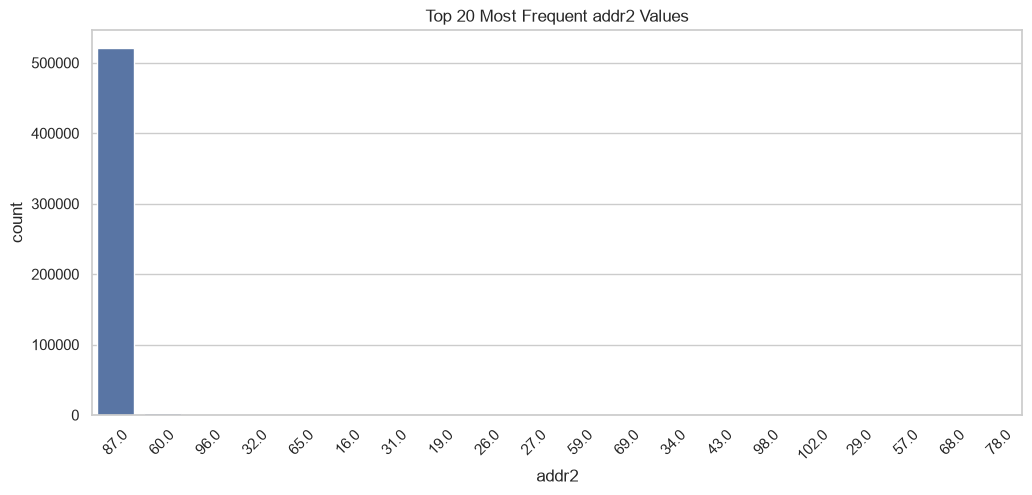

In [74]:
addr_cols = ["addr1", "addr2"]
for col in addr_cols:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=trans_df, x=col, order=trans_df[col].value_counts().head(20).index)
    plt.title(f"Top 20 Most Frequent {col} Values")
    plt.xticks(rotation=45)
    plt.show()

The distributions confirm that transaction locations are not evenly distributed. A few address values account for the majority of transactions, while many other locations occur much less frequently. In particular, value 87 extremely dominates addr2, whereas addr1 shows a more diverse distribution.

In [75]:
addr_cols = ["addr1", "addr2"]
for col in addr_cols:
    stats = (trans_df.groupby(col).agg(Transactions=("isFraud", "count"), FraudRate=("isFraud", "mean")))
    stats["FraudRate"] *= 100
    stats = stats[stats["Transactions"] >= 1000].sort_values("FraudRate", ascending=False)
    print("=" * 60)
    print(col)
    display(stats)

addr1


,Transactions,FraudRate
addr1,,
122.0,1617,7.235622
308.0,1279,6.489445
324.0,2173,5.154165
203.0,3808,4.070378
226.0,4867,3.883296
269.0,6404,3.529044
512.0,8268,3.434930
170.0,2001,3.398301
420.0,3581,3.267244


addr2


,Transactions,FraudRate
addr2,,
60.0,3084,9.046693
87.0,520481,2.397206


The fraud rate plots clearly highlight high-risk address categories. Several addr1 values consistently show elevated fraud rates compared with the majority of locations. Likewise, although addr2 contains very few categories, value 60 stands out with a considerably higher fraud rate than the dominant category. These findings indicate that geographic information may provide useful predictive signals for fraud detection.

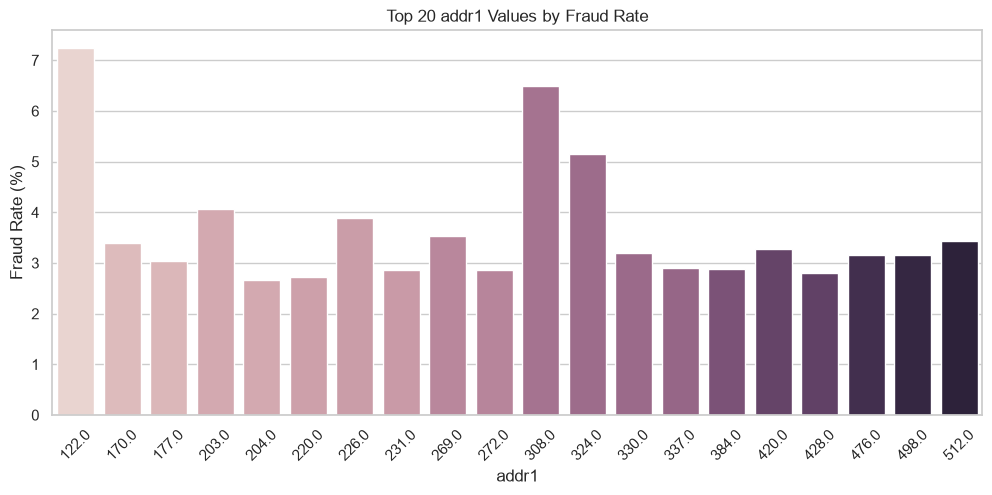

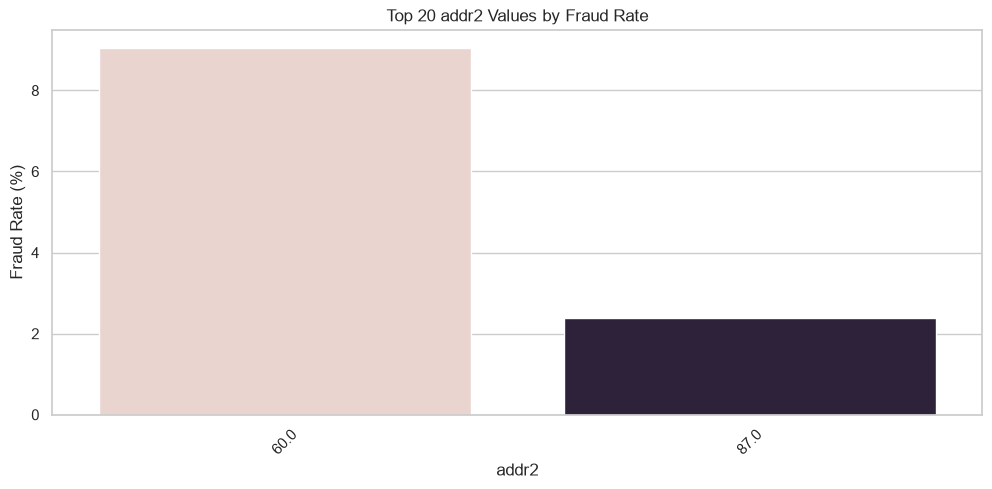

In [76]:
addr_cols = ["addr1", "addr2"]
for col in addr_cols:
    stats = (trans_df.groupby(col).agg(Transactions=("isFraud", "count"), FraudRate=("isFraud", "mean")).reset_index())
    stats["FraudRate"] *= 100
    stats = (stats[stats["Transactions"] >= 1000].sort_values("FraudRate", ascending=False).head(20))
    plt.figure(figsize=(12, 5))
    sns.barplot(data=stats, x=col,y="FraudRate",hue=col,legend=False)

    plt.title(f"Top 20 {col} Values by Fraud Rate")
    plt.xlabel(col)
    plt.ylabel("Fraud Rate (%)")
    plt.xticks(rotation=45)
    plt.show()

The fraud rate plots clearly highlight high-risk address categories. Several addr1 values consistently show elevated fraud rates compared with the majority of locations. Likewise, although addr2 contains very few categories, value 60 stands out with a considerably higher fraud rate than the dominant category. These findings indicate that geographic information may provide useful predictive signals for fraud detection.

## 5. Merge Transaction & Identity Dataset

In [77]:
df = trans_df.merge(id_df,on="TransactionID",how="left")

The transaction and identity datasets were merged using TransactionID. A left join was applied to preserve all transaction records while appending the available identity information. Transactions without matching identity records contain missing values in identity-related features.

In [78]:
identity_cols = ["DeviceType", "DeviceInfo","id_12", "id_15", "id_16","id_23", "id_27", "id_28","id_29", "id_30", "id_31","id_33", "id_34","id_35", "id_36", "id_37", "id_38"]

In [79]:
for col in identity_cols:
    print("=" * 60)
    print(col)

    print(df[col].describe())
    print()
    print(df[col].value_counts(dropna=False).head(20))
    print()

DeviceType
count      140810
unique          2
top       desktop
freq        85165
Name: DeviceType, dtype: object

DeviceType
NaN        449730
desktop     85165
mobile      55645
Name: count, dtype: int64

DeviceInfo
count      118666
unique       1786
top       Windows
freq        47722
Name: DeviceInfo, dtype: object

DeviceInfo
NaN                            471874
Windows                         47722
iOS Device                      19782
MacOS                           12573
Trident/7.0                      7440
rv:11.0                          1901
rv:57.0                           962
SM-J700M Build/MMB29K             549
SM-G610M Build/MMB29K             461
SM-G531H Build/LMY48B             410
rv:59.0                           362
SM-G935F Build/NRD90M             334
SM-G955U Build/NRD90M             328
SM-G532M Build/MMB29T             316
ALE-L23 Build/HuaweiALE-L23       312
SM-G950U Build/NRD90M             290
SM-G930V Build/NRD90M             274
rv:58.0            

In [80]:
identity_stats = {}

for col in identity_cols:
    stats = (
        df.groupby(col, dropna=False)
        .agg(
            Transactions=("isFraud", "count"),
            FraudRate=("isFraud", "mean")
        )
        .reset_index()
    )

    stats["FraudRate"] *= 100
    stats = stats.sort_values("FraudRate", ascending=False)

    identity_stats[col] = stats

    print("=" * 60)
    print(col)

    display(stats.head(20))

DeviceType


,DeviceType,Transactions,FraudRate
1,mobile,55645,10.166232
0,desktop,85165,6.521458
2,NaN,449730,2.101705


DeviceInfo


,DeviceInfo,Transactions,FraudRate
1745,rv:29.0,1,100.0
1744,rv:14.0,5,100.0
1717,ZTE-Z956,1,100.0
1728,iPhone,1,100.0
1689,Z835 Build/NMF26V,25,100.0
1698,Z965 Build/NMF26V,5,100.0
1707,ZEIA8,2,100.0
1716,ZTE-Z835,3,100.0
1685,Z813 Build/LMY47O,11,100.0
1673,XT890 Build/9.8.2I-50_SML-25,8,100.0


id_12


...

,id_36,Transactions,FraudRate
0,F,134066,8.188504
1,T,6919,3.526521
2,NaN,449555,2.100077


id_37


,id_37,Transactions,FraudRate
1,T,110452,8.331221
0,F,30533,6.615793
2,NaN,449555,2.100077


id_38


,id_38,Transactions,FraudRate
0,F,73922,9.779227
1,T,67063,5.954103
2,NaN,449555,2.100077


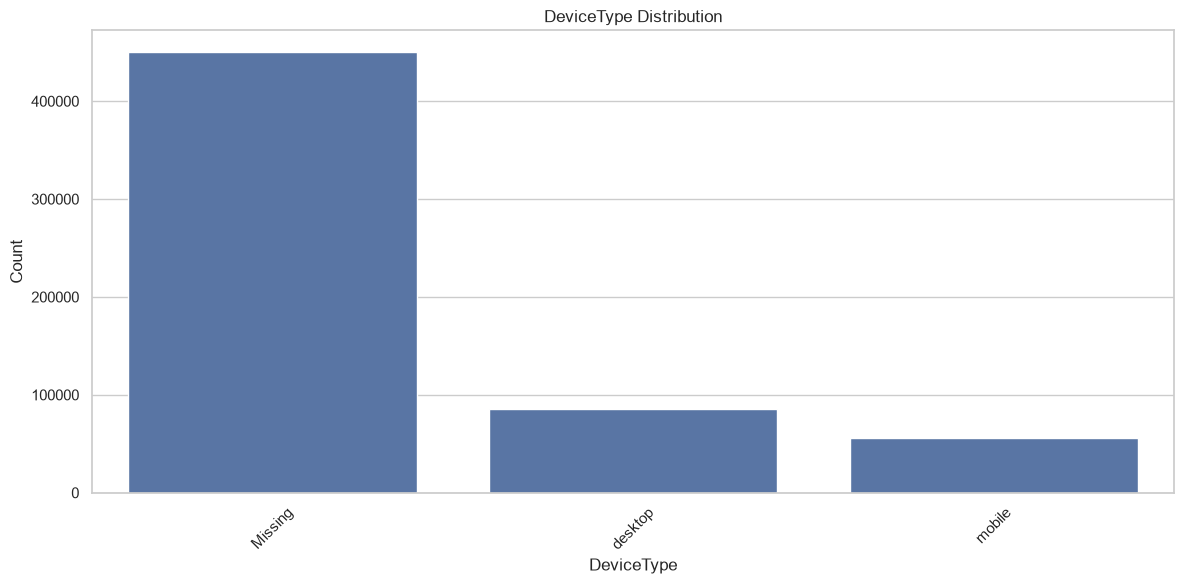

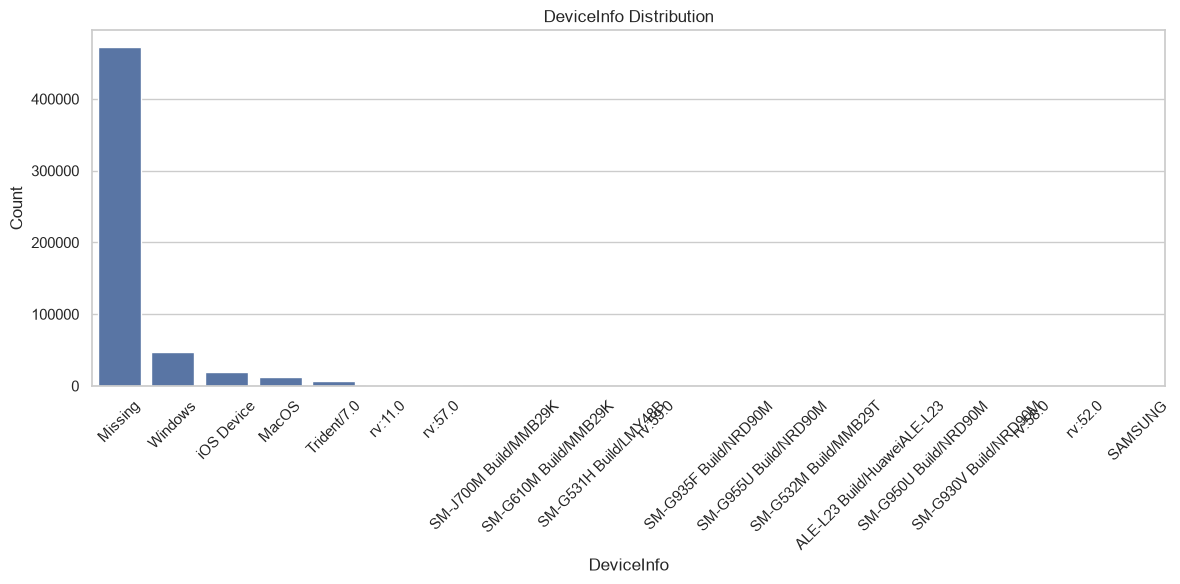

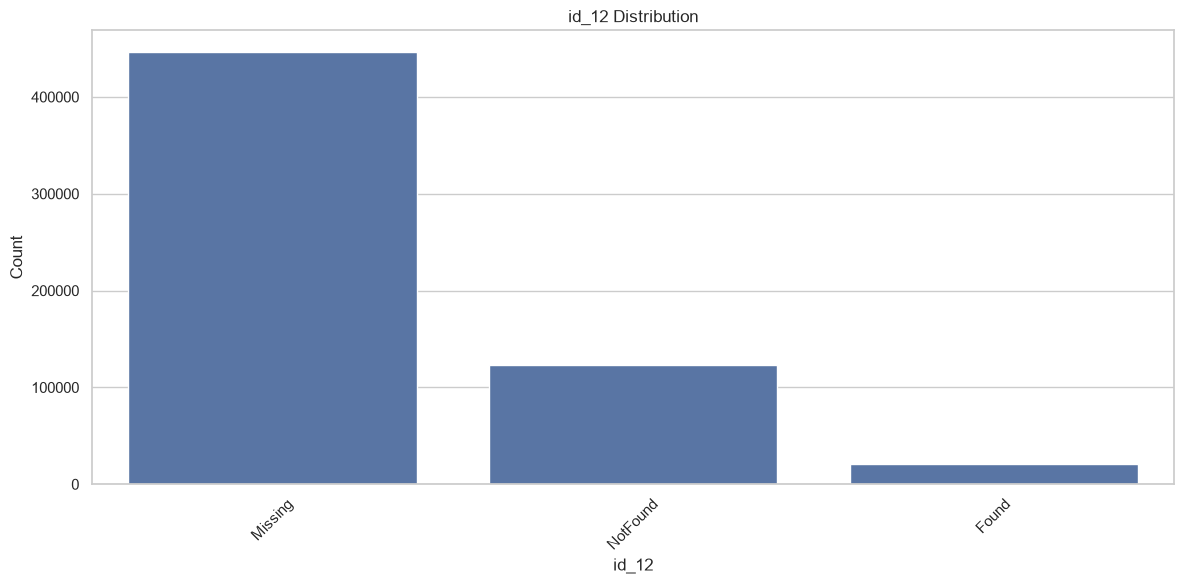

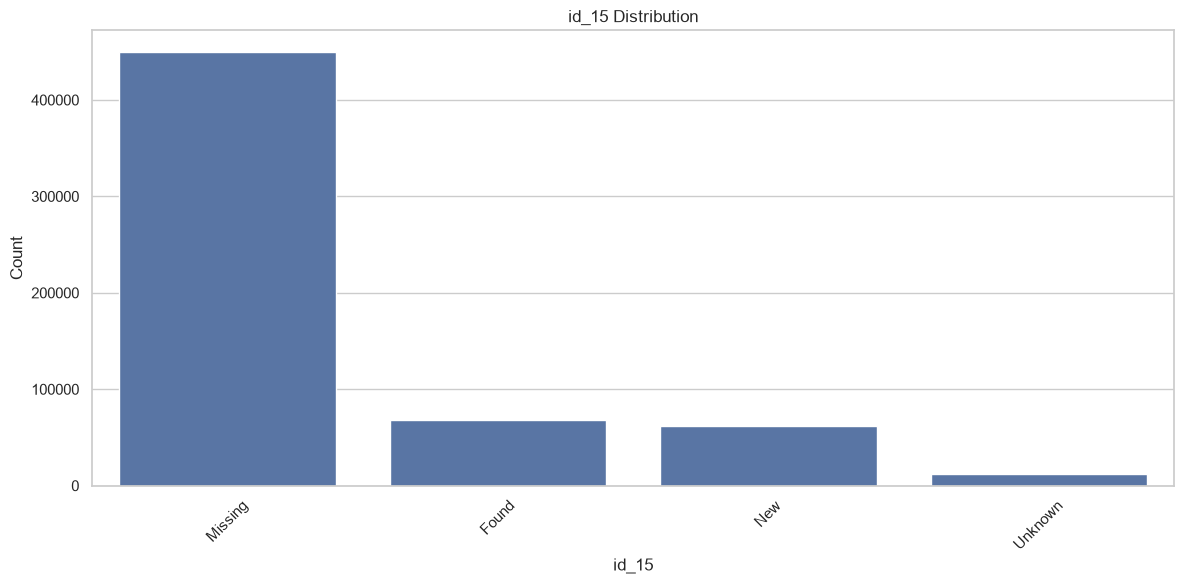

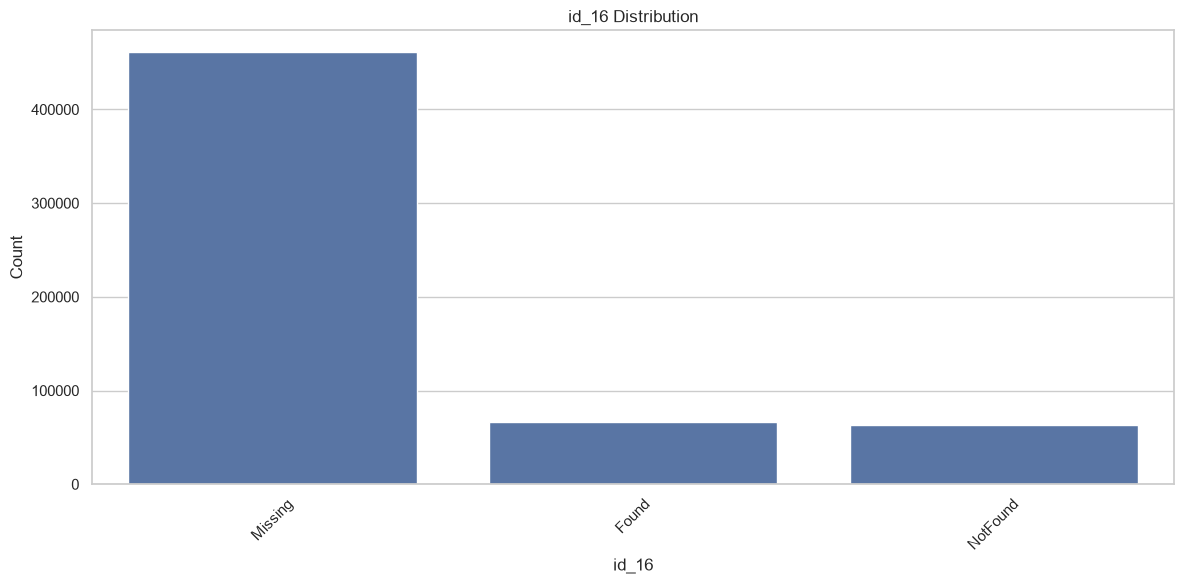

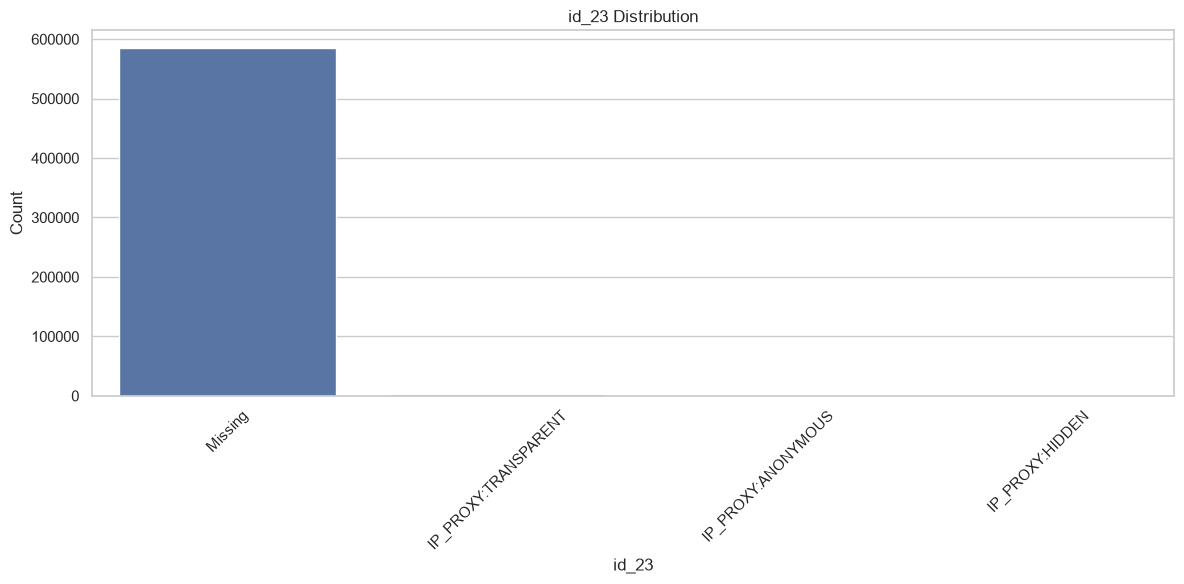

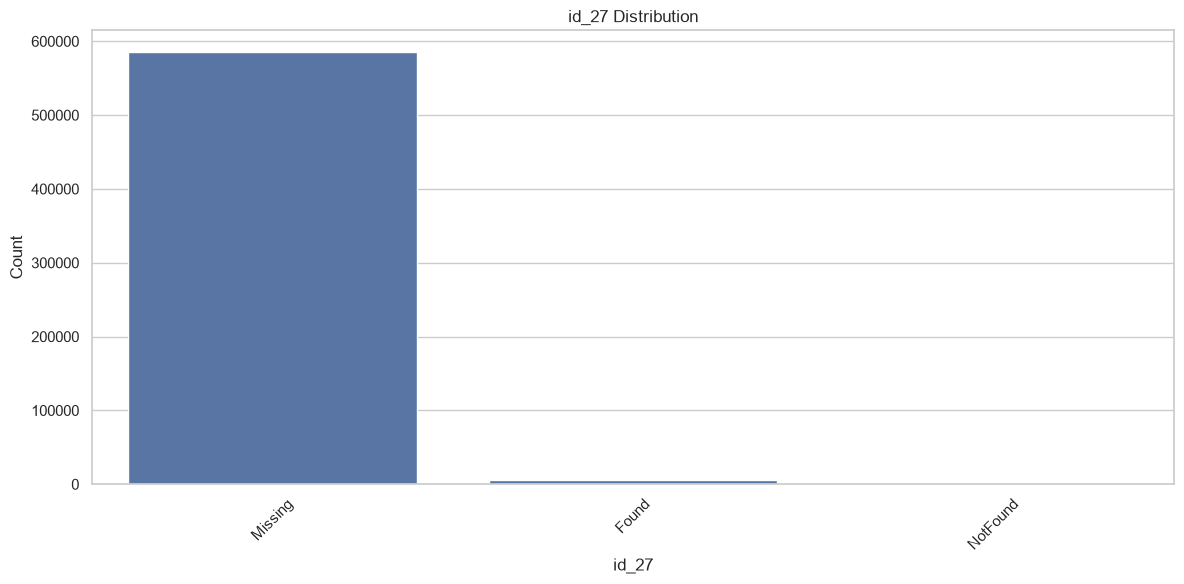

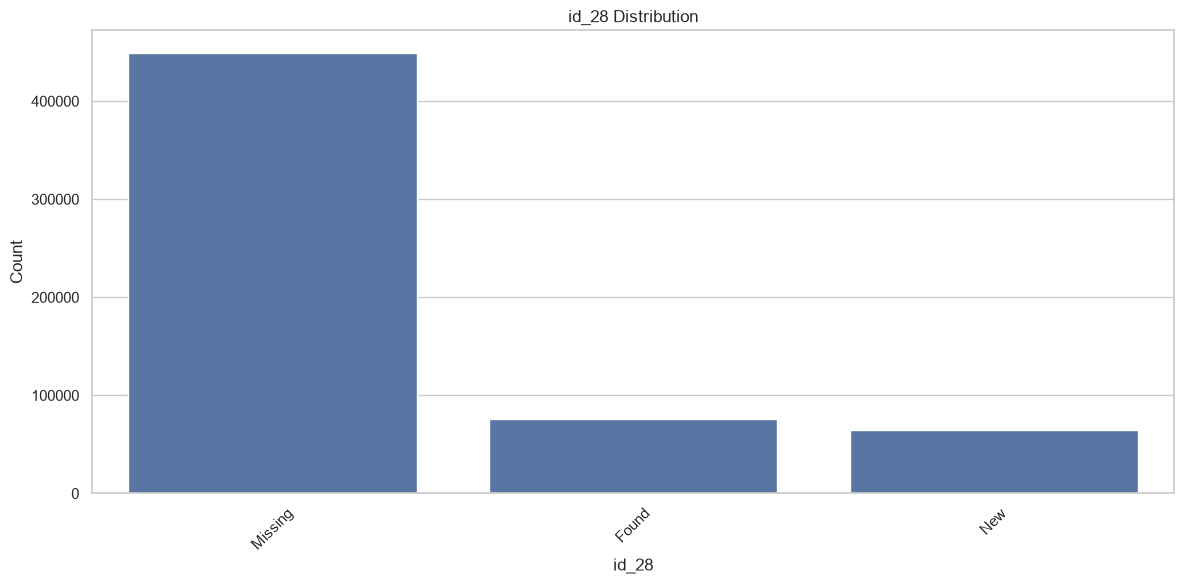

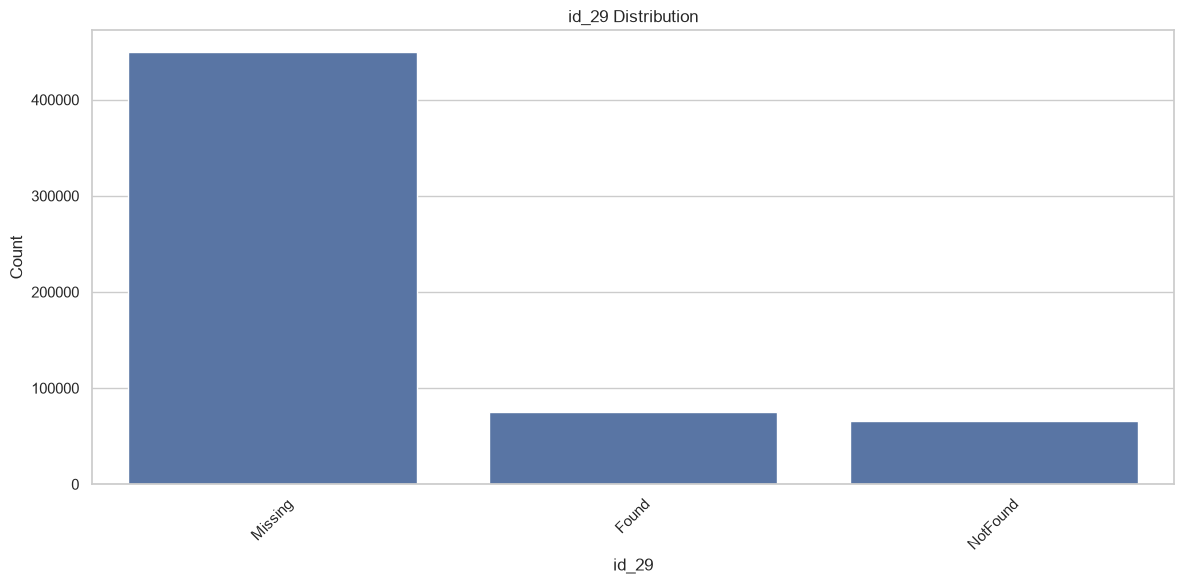

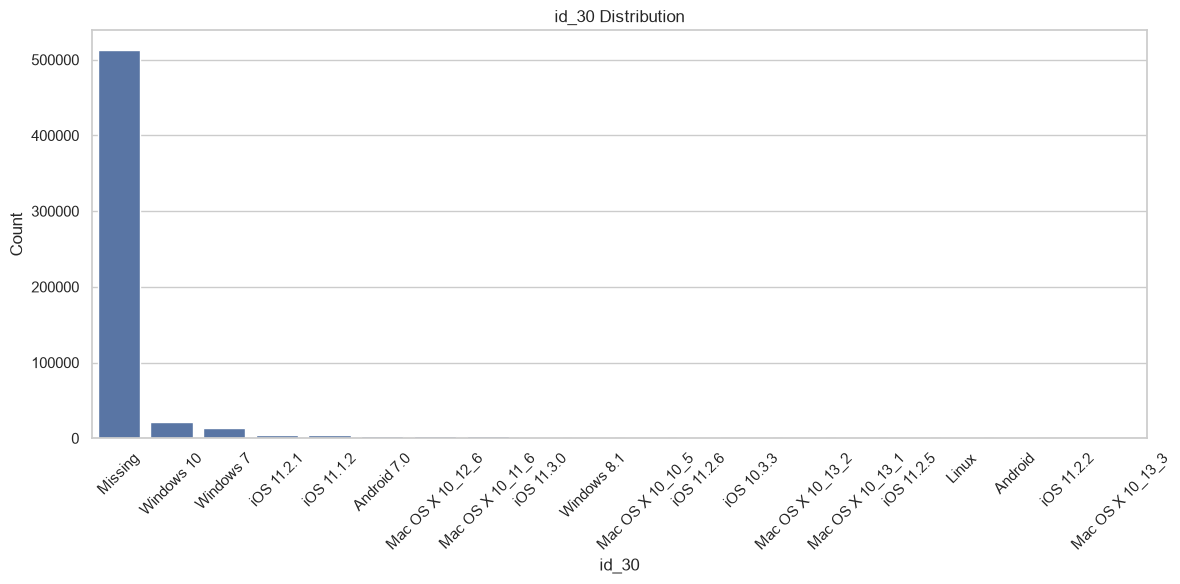

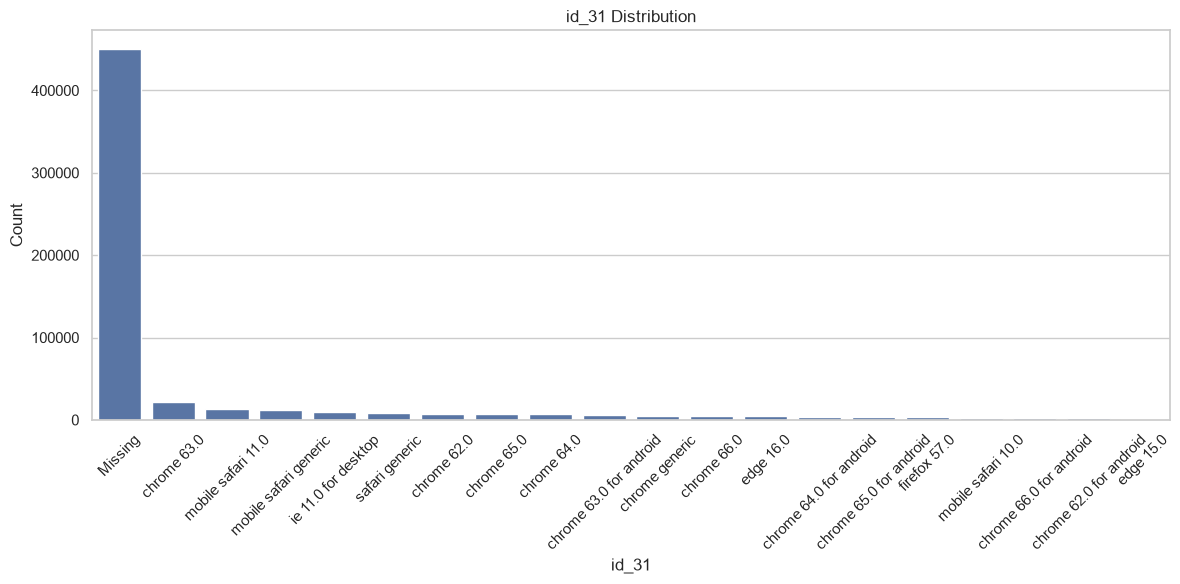

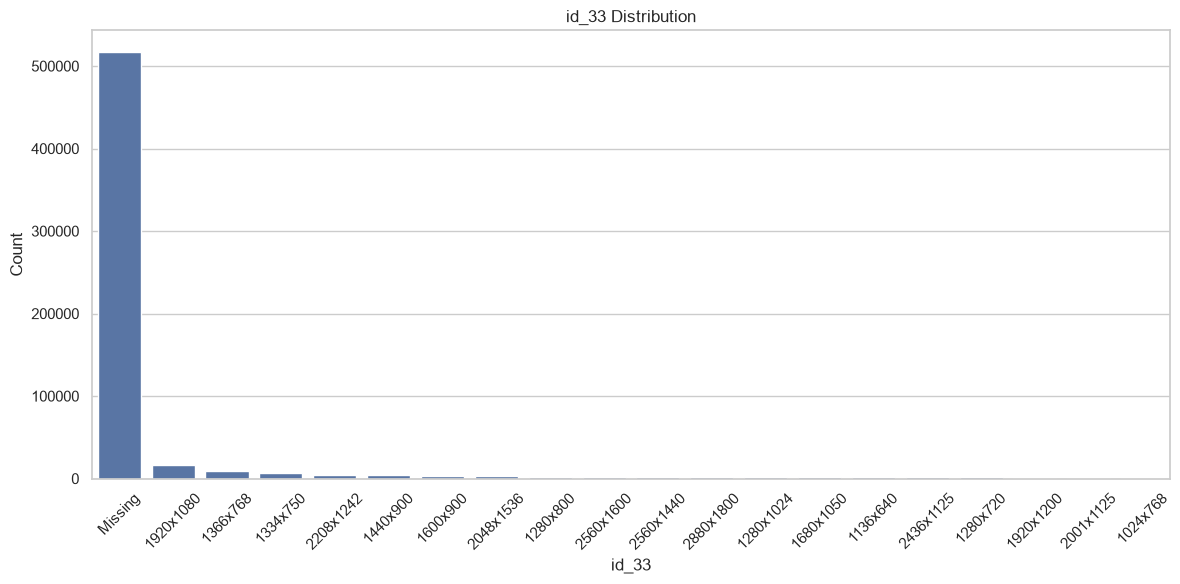

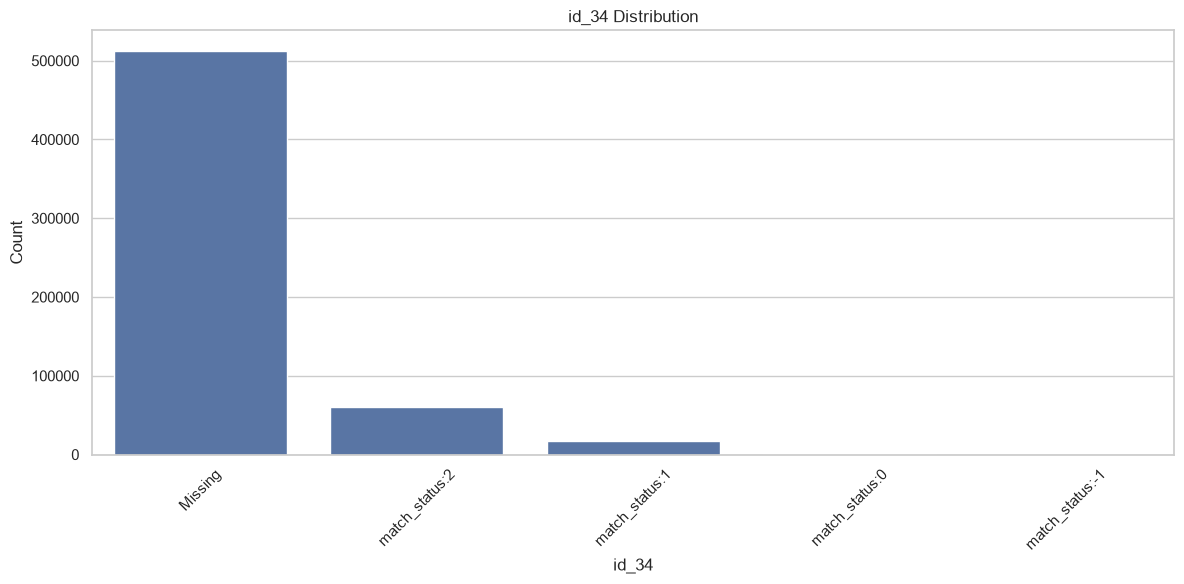

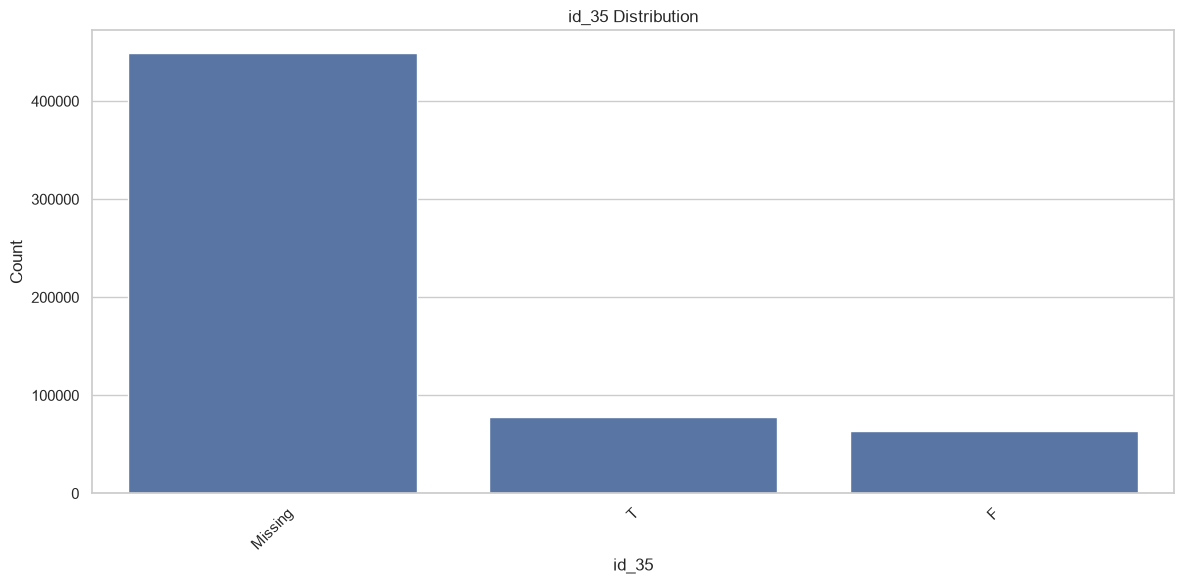

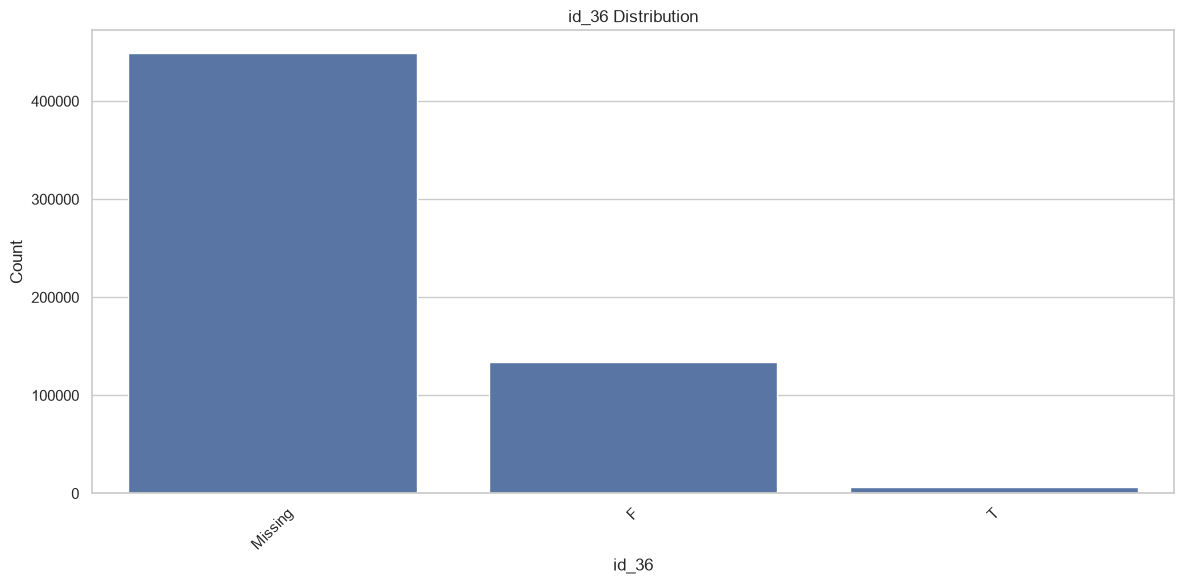

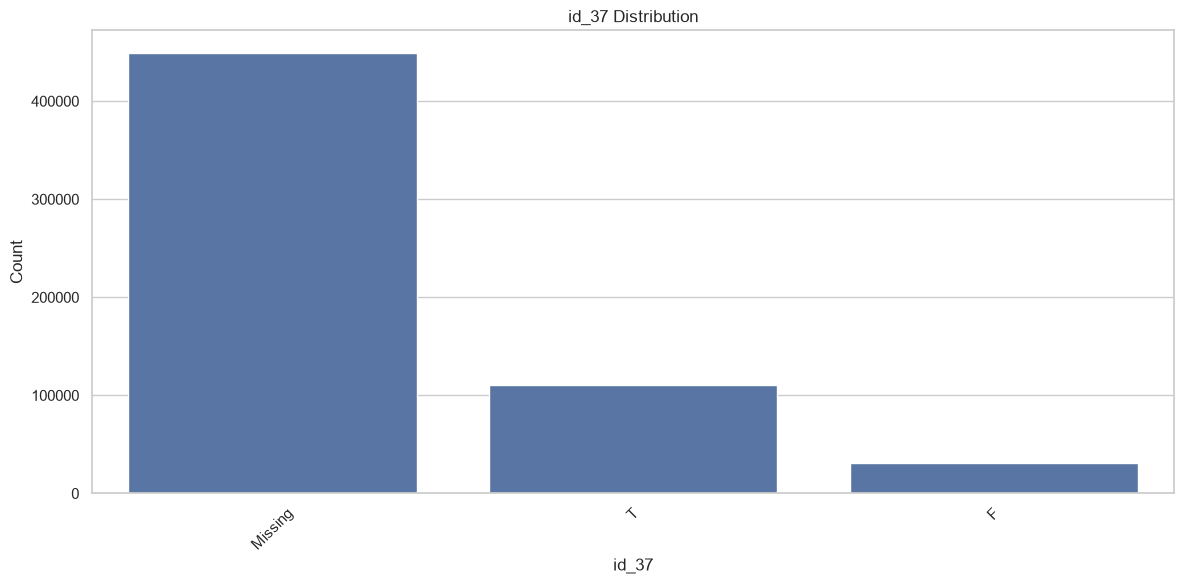

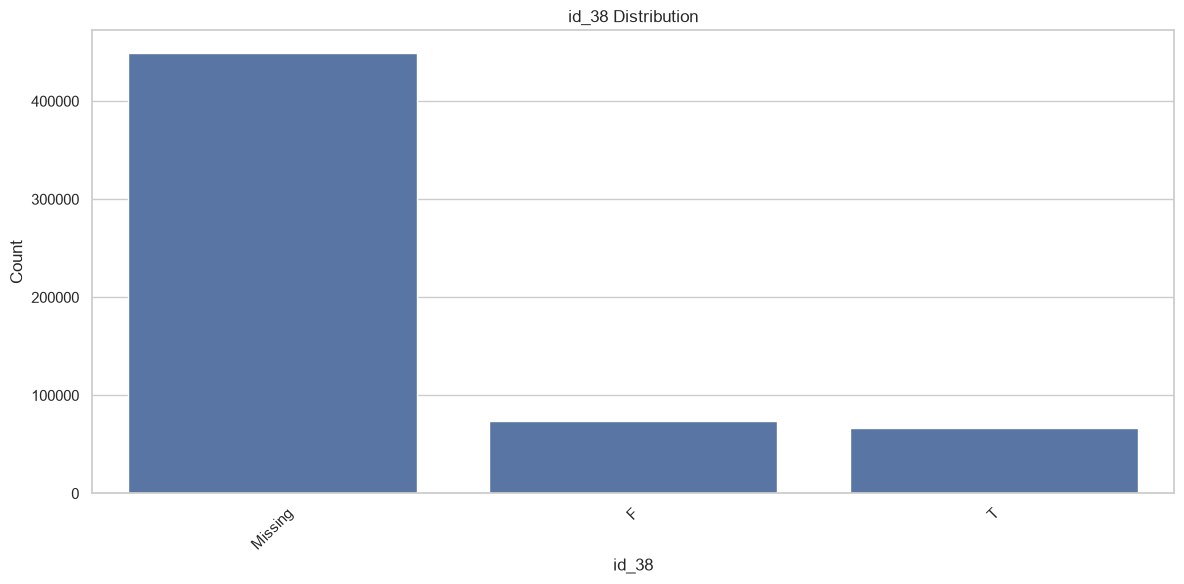

In [81]:
identity_cols = [col for col in identity_cols if col in df.columns]

for col in identity_cols:
    temp = df[[col]].copy()
    temp[col] = temp[col].fillna("Missing").astype(str)

    plt.figure(figsize=(12, 6))
    sns.countplot(
        data=temp,
        x=col,
        order=temp[col].value_counts().head(20).index
    )

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

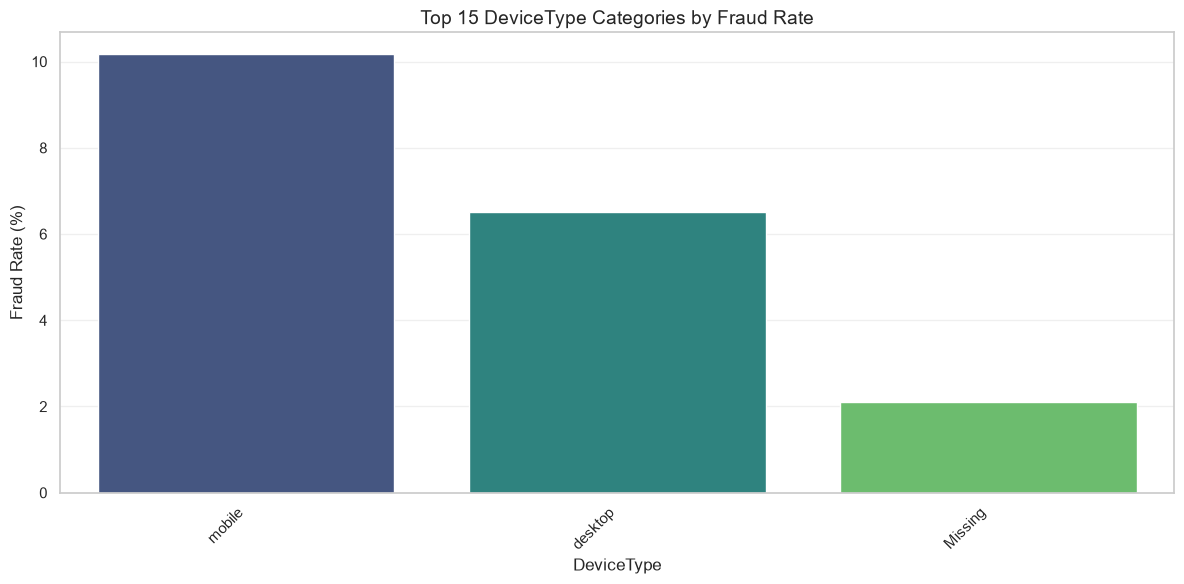

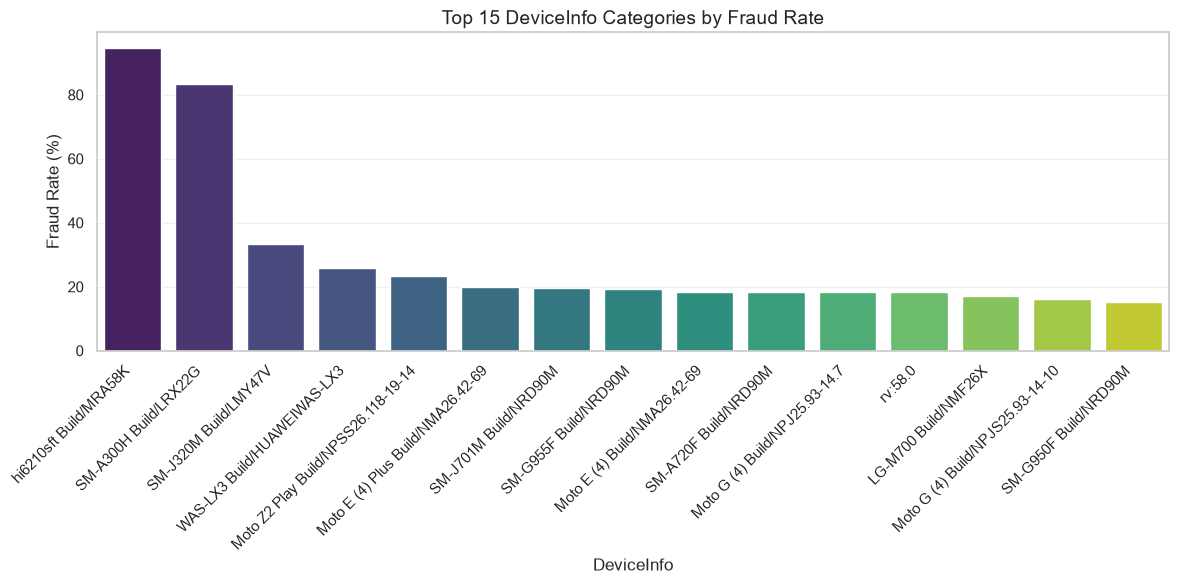

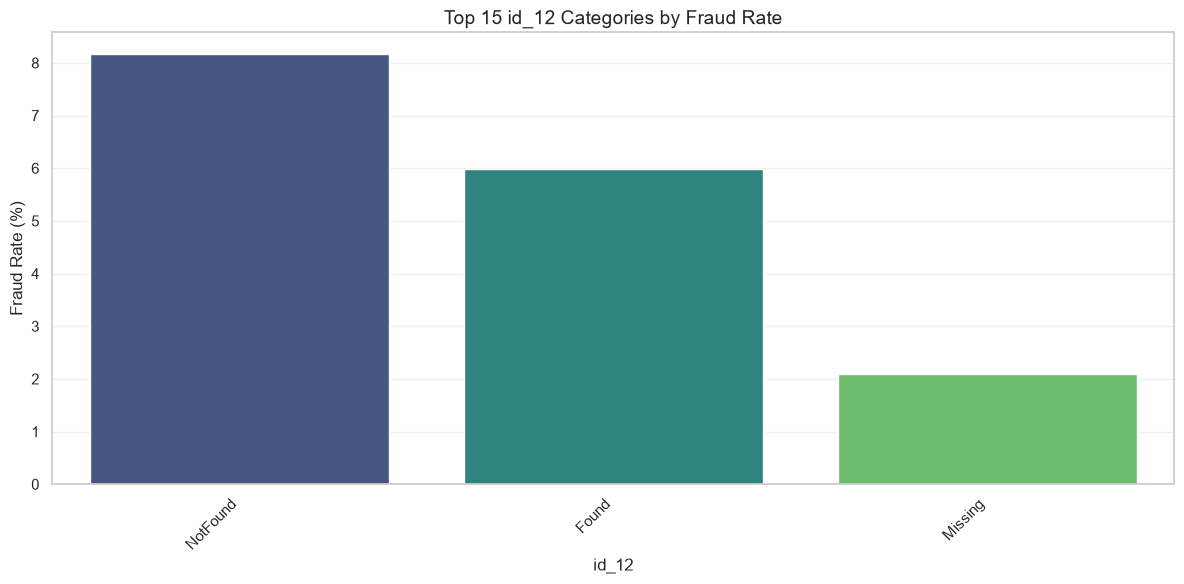

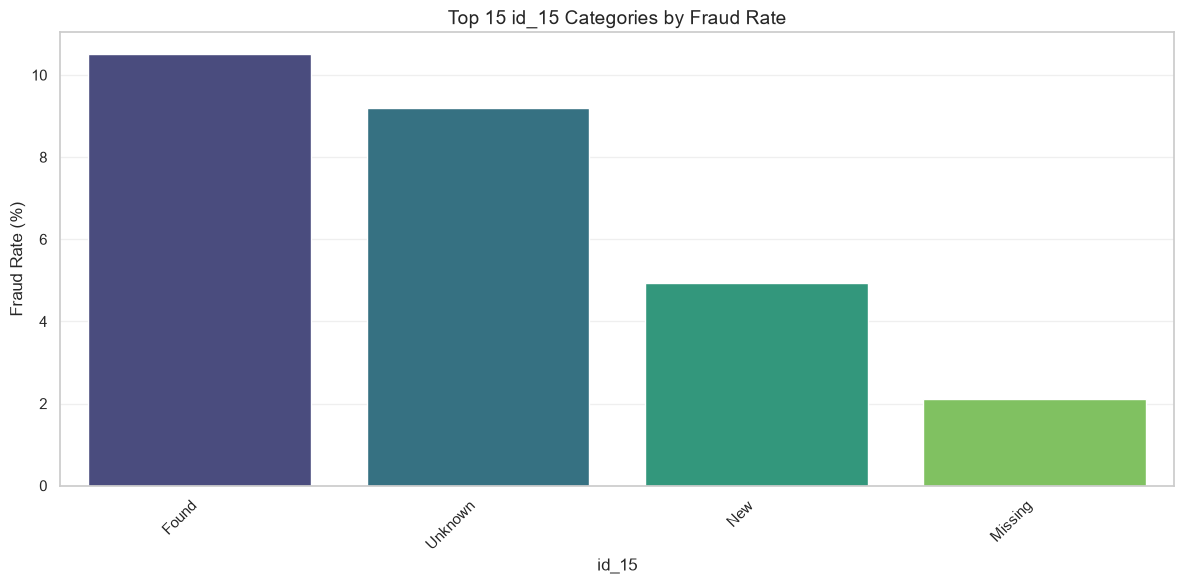

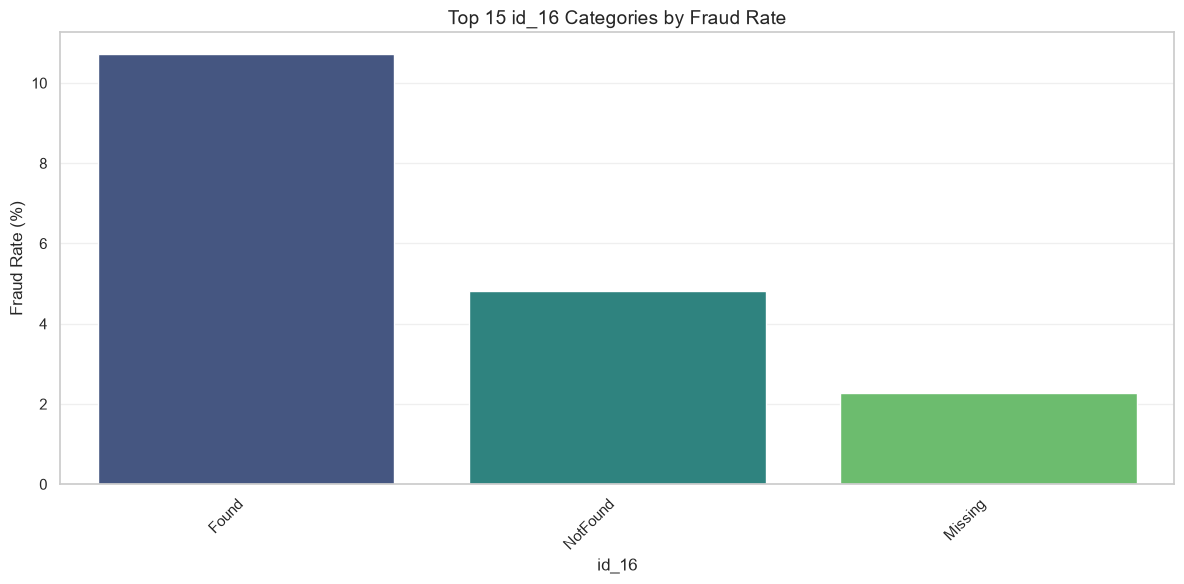

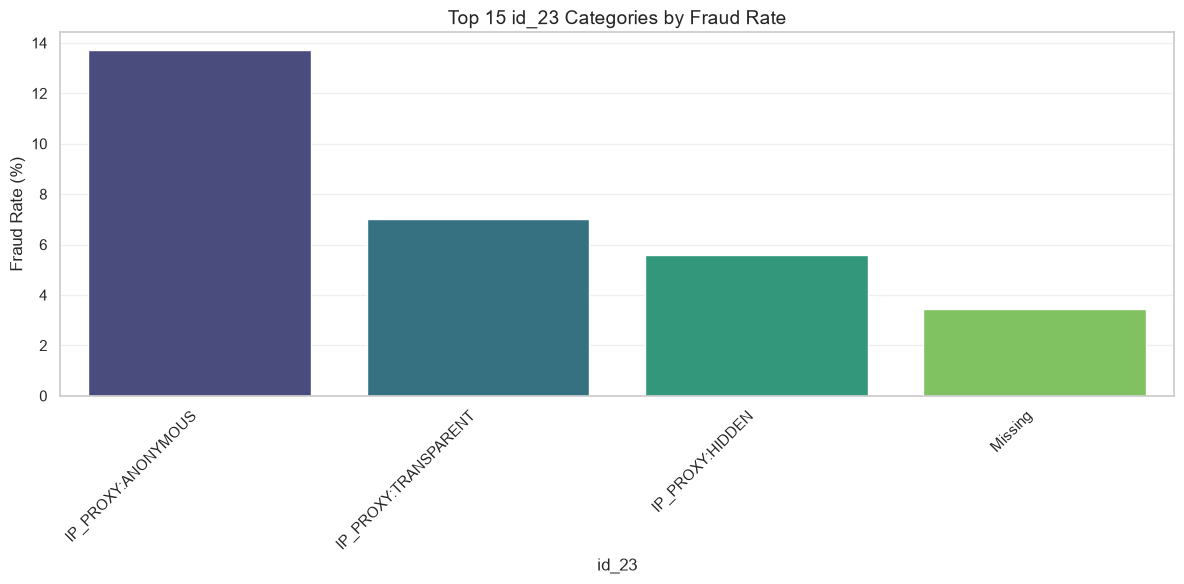

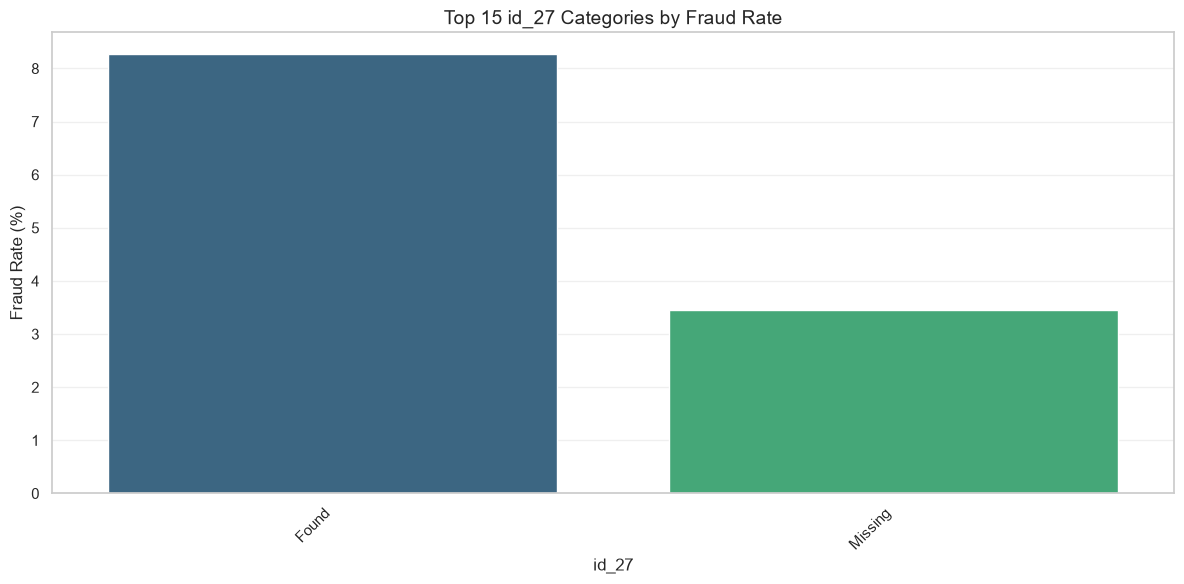

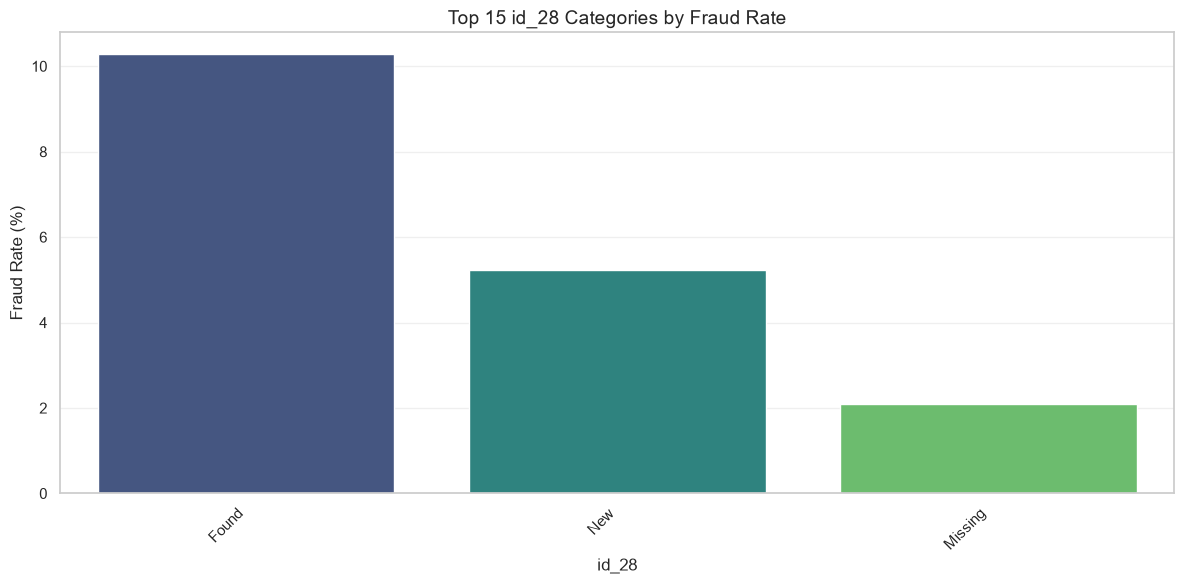

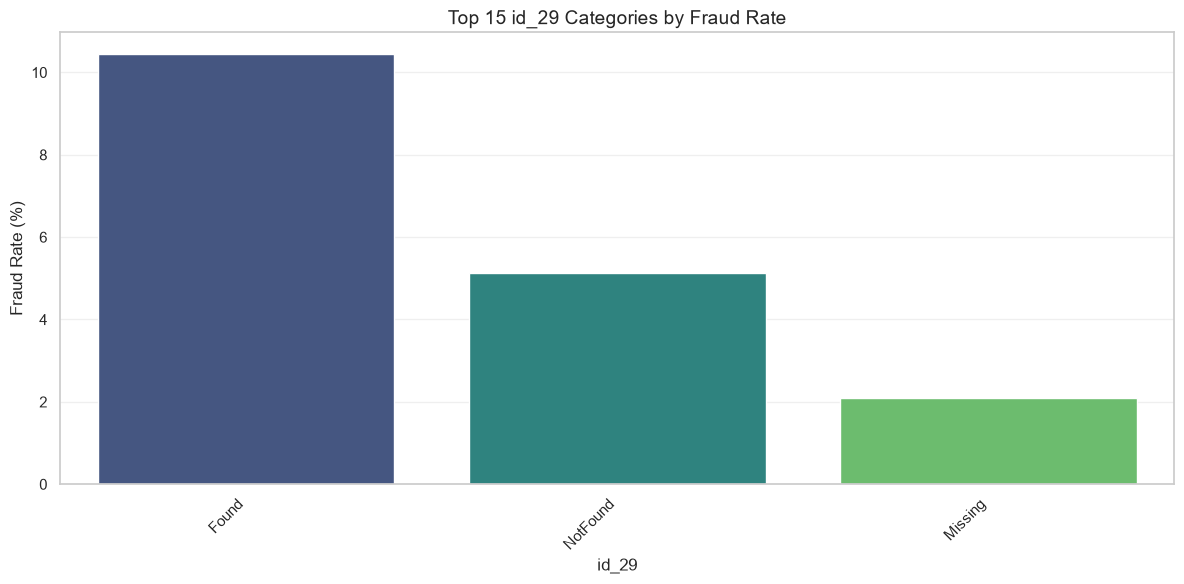

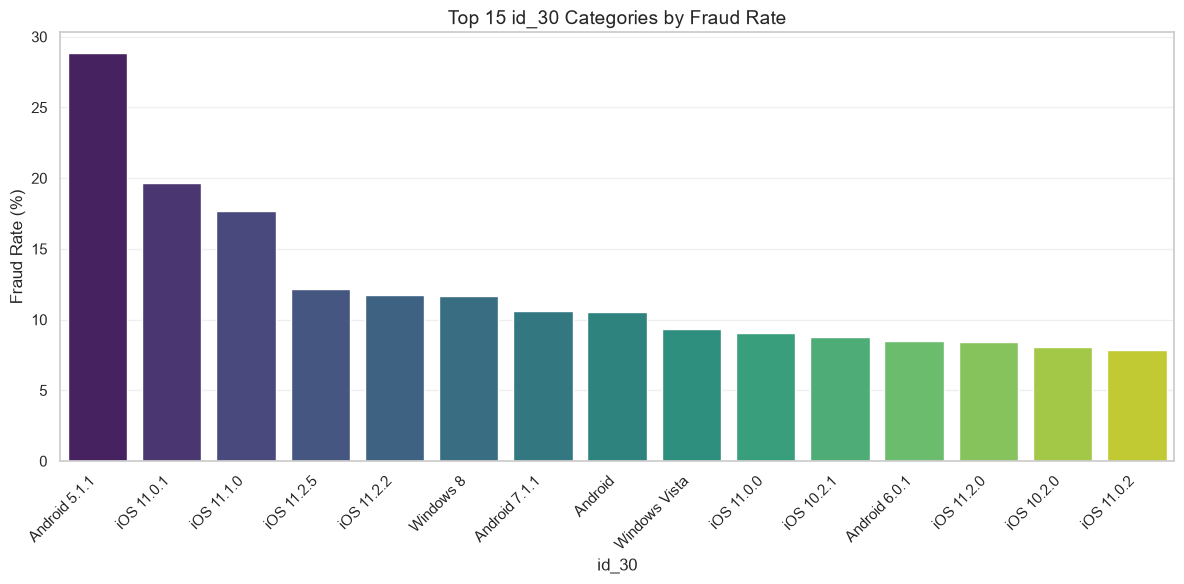

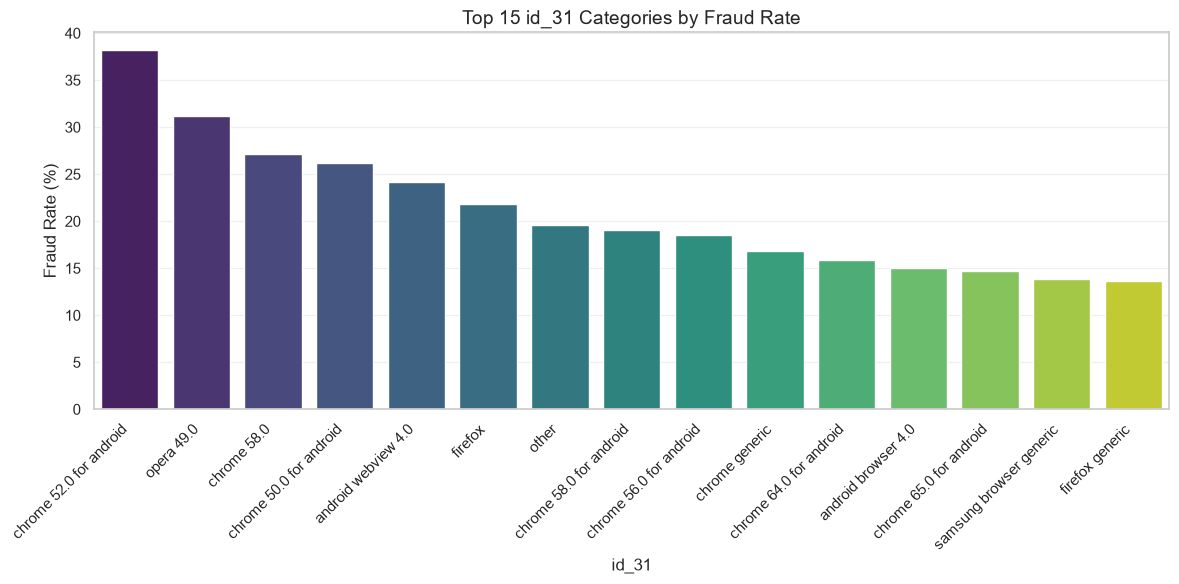

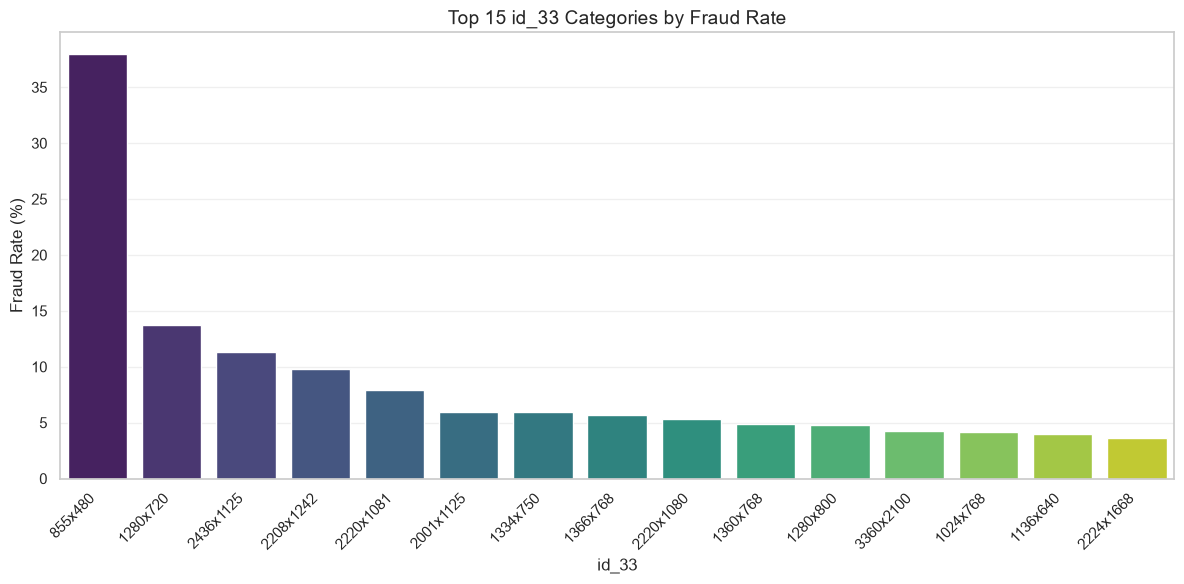

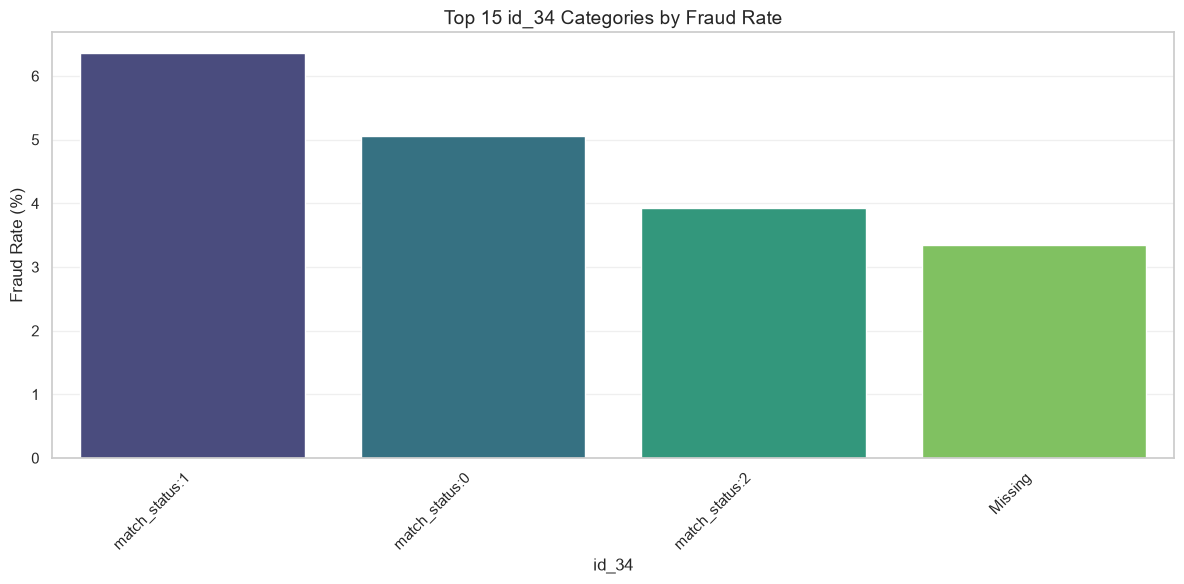

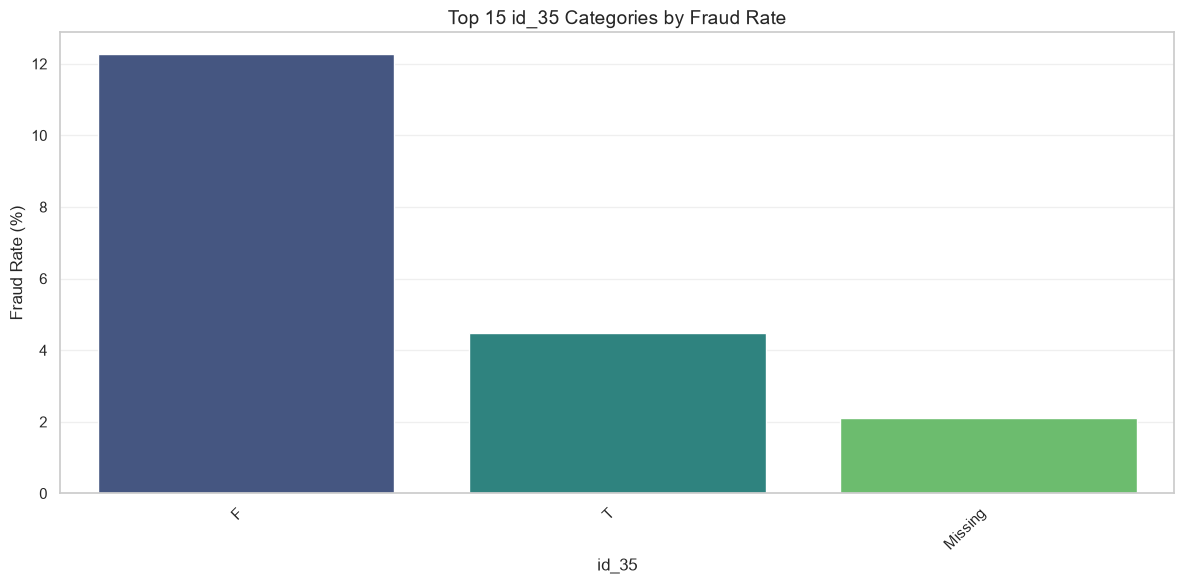

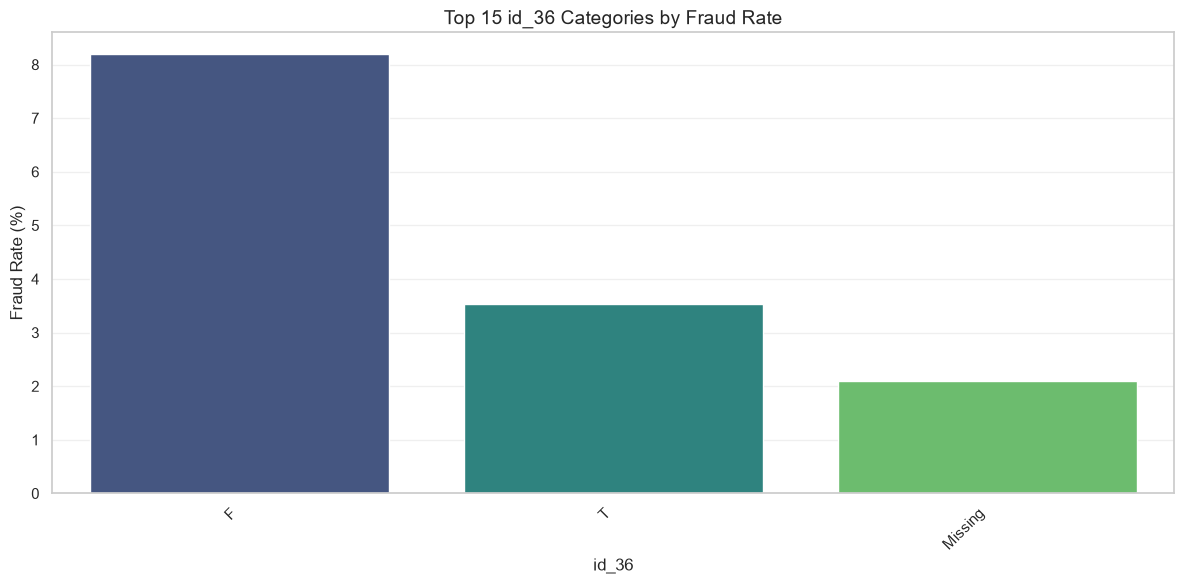

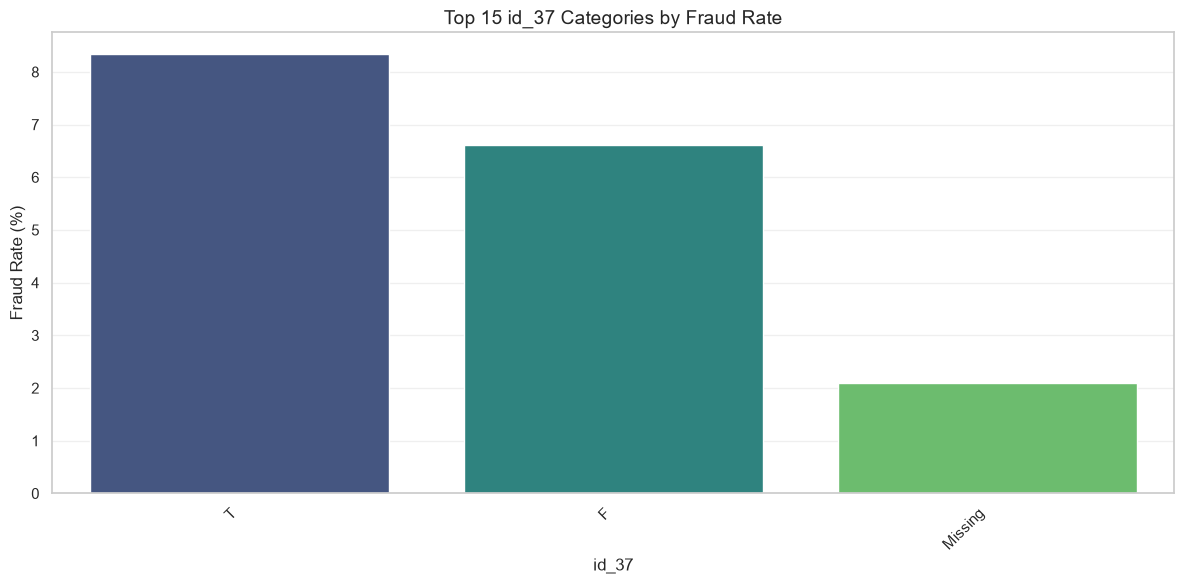

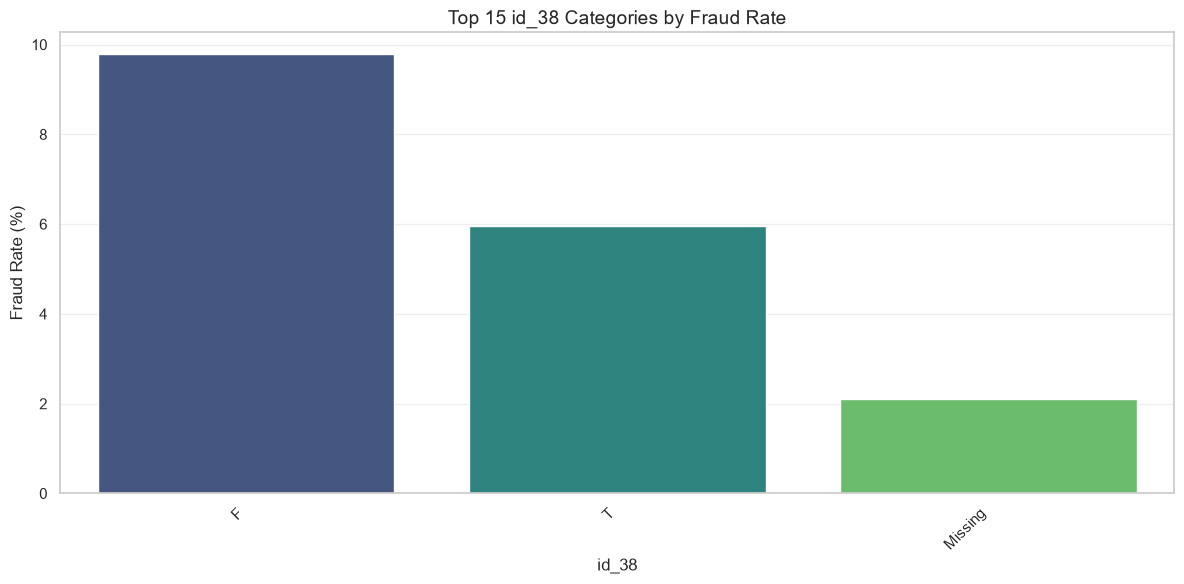

In [82]:
for col in identity_cols:

    plot_stats = identity_stats[col].copy()

    plot_stats = (
        plot_stats[plot_stats["Transactions"] >= 100]
        .sort_values("FraudRate", ascending=False)
        .head(15)
    )

    plot_stats[col] = plot_stats[col].fillna("Missing").astype(str)

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=plot_stats,
        x=col,
        y="FraudRate",
        palette="viridis"
    )

    plt.title(f"Top 15 {col} Categories by Fraud Rate", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Fraud Rate (%)")

    plt.xticks(rotation=45, ha="right")

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    plt.show()

## 6. Correlation Analysis

In [83]:
corr = df.corr(numeric_only=True)
corr.shape

(403, 403)

A correlation matrix was generated for all numerical features to measure the linear relationship between variables. The dataset contains 403 numerical features used in the correlation analysis.

In [84]:
fraud_corr = (corr["isFraud"].sort_values(ascending=False))
fraud_corr.head(20)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
Name: isFraud, dtype: float64

The strongest positive correlations with fraud were observed in several anonymized V features, with V257 showing the highest correlation (0.383). However, no individual feature exhibited an extremely strong relationship with fraud, suggesting that fraudulent behavior is influenced by multiple interacting variables.

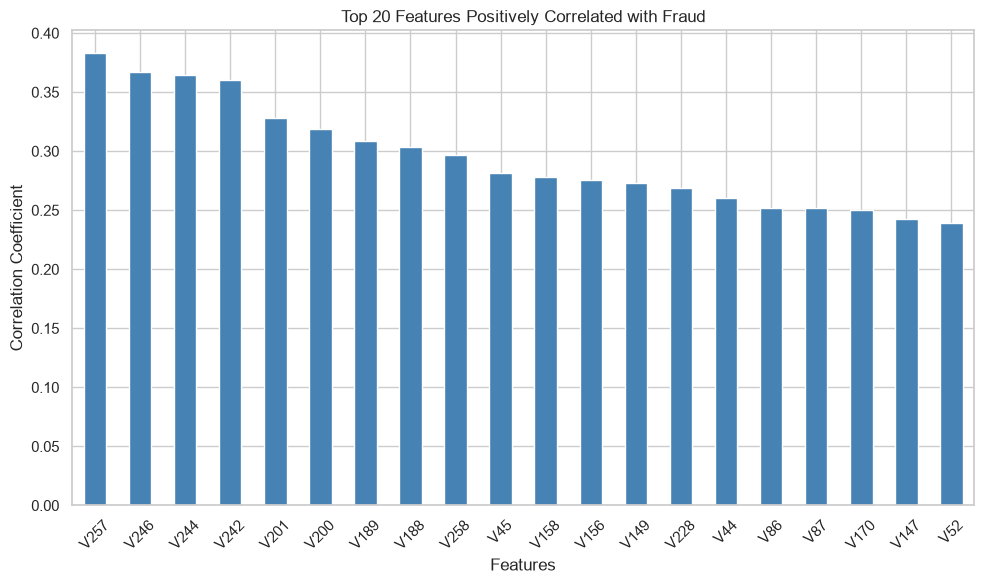

In [85]:
plt.figure(figsize=(10, 6))
fraud_corr.drop("isFraud").head(20).plot(kind="bar",color="steelblue")
plt.title("Top 20 Features Positively Correlated with Fraud")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart highlights the top features positively associated with fraudulent transactions. Most of these variables belong to the anonymized V feature group, indicating that the engineered variables extracted during preprocessing contain valuable fraud-related information.

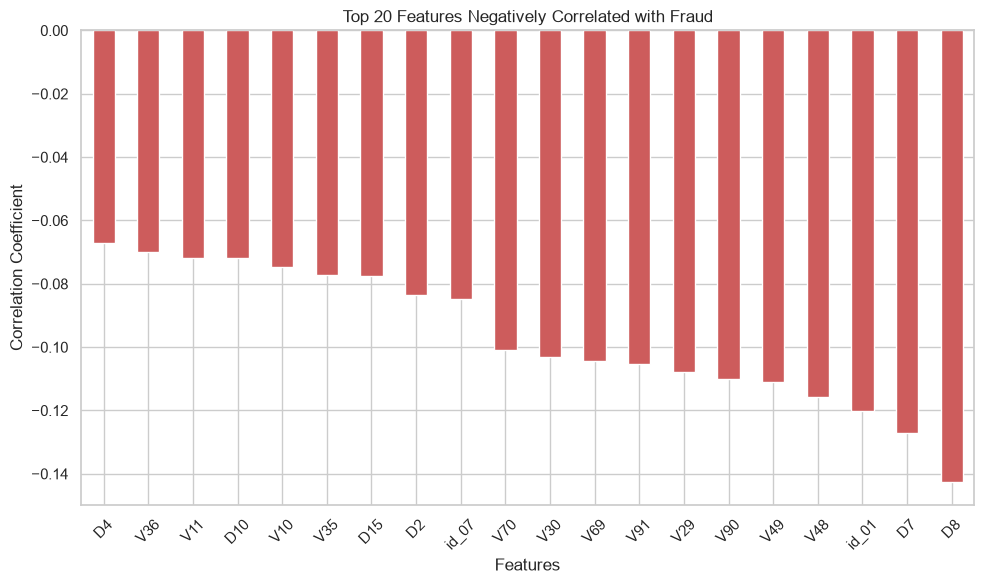

In [86]:
plt.figure(figsize=(10, 6))
fraud_corr.tail(20).plot(kind="bar",color="indianred")
plt.title("Top 20 Features Negatively Correlated with Fraud")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Several features exhibit negative correlations with fraud, meaning that higher values of these variables are generally associated with legitimate transactions. However, the correlation strengths remain relatively weak, indicating that no single feature alone can reliably distinguish fraudulent activity.

In [87]:
top_features = (fraud_corr.drop("isFraud").abs().sort_values(ascending=False).head(20).index)

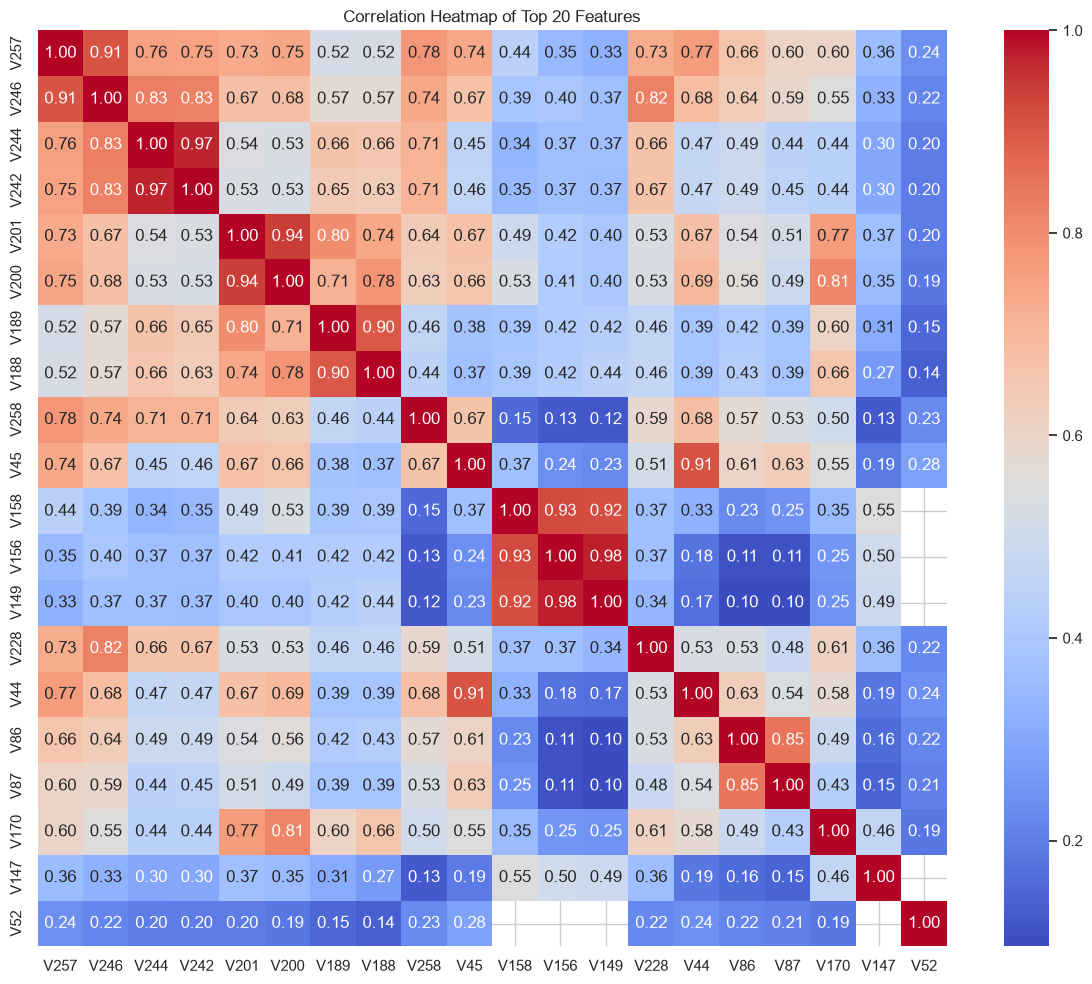

In [88]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(),cmap="coolwarm",annot=True,fmt=".2f")
plt.title("Correlation Heatmap of Top 20 Features")
plt.tight_layout()
plt.show()

The heatmap reveals the relationships among the most fraud-related features. Some V features are moderately correlated with each other, suggesting that they may capture similar behavioral patterns. Nevertheless, the correlations are not excessively high, indicating limited multicollinearity among the selected features.

## 7. Missing Values Analysis

In [89]:
missing = pd.DataFrame({"MissingValues": df.isnull().sum(),"MissingPercentage": (df.isnull().mean() * 100)})
missing = missing.sort_values("MissingPercentage",ascending=False)
missing.head(20)

,MissingValues,MissingPercentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


Several identity-related features (id_*) contain extremely high percentages of missing values, with some exceeding 99%. This indicates that these features provide limited information for the majority of transactions.

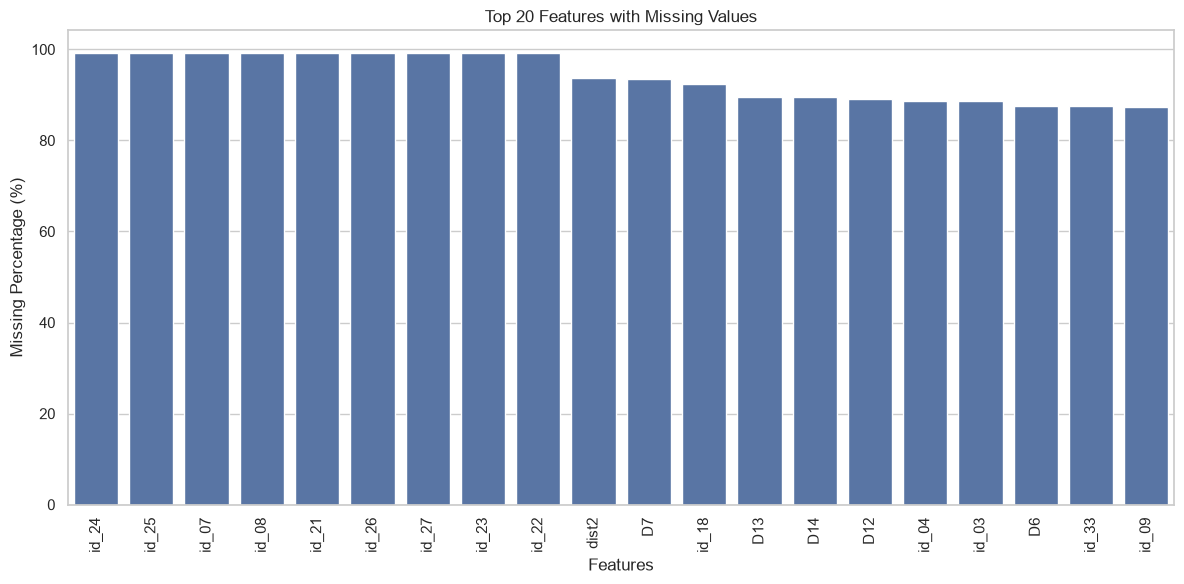

In [90]:
top_missing = missing.head(20)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_missing,x=top_missing.index,y="MissingPercentage")
plt.title("Top 20 Features with Missing Values")
plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

High missing values are also observed in transaction-related features such as dist2, D6, D7, D12, D13, and D14. Therefore, different missing-value handling strategies will be required during the preprocessing stage, including feature removal or imputation depending on the percentage of missing data.

## 8. Data Preprocessing

### 8.1 Remove Features with High Missing Values

In [91]:
missing_percentage = df.isnull().mean() * 100
high_missing_cols = missing_percentage[missing_percentage > 95].index
print(f"Number of columns to remove: {len(high_missing_cols)}")
df.drop(columns=high_missing_cols, inplace=True)
print(df.shape)

Number of columns to remove: 9
(590540, 425)


### 8.2 Handle Missing Values

In [92]:
missing = pd.DataFrame({"MissingValues": df.isnull().sum(),"MissingPercentage": df.isnull().mean() * 100})
missing = (missing[missing["MissingValues"] > 0].sort_values("MissingPercentage", ascending=False))
missing.head(30)

,MissingValues,MissingPercentage
dist2,552913,93.628374
D7,551623,93.409930
id_18,545427,92.360721
D13,528588,89.509263
D14,528353,89.469469
D12,525823,89.041047
id_04,524216,88.768923
id_03,524216,88.768923
D6,517353,87.606767
id_33,517251,87.589494


#### 8.2.1 Remove Features with More Than 85% Missing Values

In [93]:
missing_percentage = df.isnull().mean() * 100
cols_to_drop = missing_percentage[(missing_percentage > 85) &(missing_percentage <= 95)].index
print(f"Columns to remove: {len(cols_to_drop)}")
cols_to_drop.tolist()

Columns to remove: 65


['dist2',
 'D6',
 'D7',
 'D8',
 'D9',
 'D12',
 'D13',
 'D14',
 'V138',
 'V139',
 'V140',
 'V141',
 'V142',
 'V143',
 'V144',
 'V145',
 'V146',
 'V147',
 'V148',
 'V149',
 'V150',
 'V151',
 'V152',
 'V153',
 'V154',
 'V155',
 'V156',
 'V157',
 'V158',
 'V159',
 'V160',
 'V161',
 'V162',
 'V163',
 'V164',
 'V165',
 'V166',
 'V322',
 'V323',
 'V324',
 'V325',
 'V326',
 'V327',
 'V328',
 'V329',
 'V330',
 'V331',
 'V332',
 'V333',
 'V334',
 'V335',
 'V336',
 'V337',
 'V338',
 'V339',
 'id_03',
 'id_04',
 'id_09',
 'id_10',
 'id_14',
 'id_18',
 'id_30',
 'id_32',
 'id_33',
 'id_34']

In [94]:
df.drop(columns=cols_to_drop, inplace=True)
print(df.shape)

(590540, 360)


After removing features with more than 95% and 85% missing values, the dataset was reduced from **425** to **360** features. These removed features contained insufficient information and were unlikely to improve model performance. The remaining missing values were intentionally preserved because advanced machine learning models such as LightGBM and CatBoost can handle missing values directly without requiring imputation.

### 8.3 Encode Categorical Features

### 8.3.1 Identify Categorical Features

In [95]:
cat_cols = df.select_dtypes(include="str").columns
print(cat_cols)
print(f"\nNumber of categorical features: {len(cat_cols)}")

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15',
       'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='str')

Number of categorical features: 26


In [96]:
binary_cols = ["M1", "M2", "M3", "M5", "M6", "M7", "M8", "M9","id_12", "id_15", "id_16", "id_28", "id_29","id_35", "id_36", "id_37", "id_38"]
low_cardinality = ["ProductCD","card4","card6","M4","DeviceType"]
high_cardinality = ["P_emaildomain","R_emaildomain","DeviceInfo"]

The dataset contains 26 categorical features. These features were divided into three groups according to the number of unique categories:

- Binary features (two categories only).
- Low-cardinality features.
- High-cardinality features.

Different encoding techniques will be applied to each group to reduce dimensionality while preserving useful information.

### 8.3.2 Encode Binary Features

In [97]:
binary_mapping = {"T": 1,"F": 0,"Found": 1,"NotFound": 0,"New": 0}
for col in binary_cols:
    df[col] = df[col].replace(binary_mapping)

In [98]:
df[binary_cols].head()

,M1,M2,M3,M5,M6,M7,M8,M9,id_12,id_15,id_16,id_28,id_29,id_35,id_36,id_37,id_38
0,1,1,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,1,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1,1


Binary categorical features were converted directly into numerical values because they contain only two possible categories. This approach preserves the original information without unnecessarily increasing the number of features.

### 8.3.3 Encode Low-Cardinality Features

In [99]:
df = pd.get_dummies(df,columns=low_cardinality,drop_first=True,dtype=int)
print(df.shape)

(590540, 368)


Low-cardinality categorical features were encoded using One-Hot Encoding. Since these variables contain only a few unique categories, this method avoids introducing artificial ordinal relationships while keeping the number of generated features relatively small.

## 9. Train/Validation Split

### 9.1 Time-Based Split

In [100]:
df = df.sort_values("TransactionDT").reset_index(drop=True)
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
valid_df = df.iloc[split_index:].copy()
print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("\nTrain fraud rate:", train_df["isFraud"].mean() * 100)
print("Valid fraud rate:", valid_df["isFraud"].mean() * 100)
print("\nTrain time range:", train_df["TransactionDT"].min(), "-", train_df["TransactionDT"].max())
print("Valid time range:", valid_df["TransactionDT"].min(), "-", valid_df["TransactionDT"].max())

Train shape: (472432, 368)
Valid shape: (118108, 368)

Train fraud rate: 3.5135215226741625
Valid fraud rate: 3.4409184813899145

Train time range: 86400 - 12192842
Valid time range: 12192900 - 15811131


The high-cardinality categorical features (P_emaildomain, R_emaildomain, DeviceInfo) were frequency-encoded using counts computed only from the training set, then mapped onto both the train and validation sets. Any category present in the validation set but not seen in the training set was assigned a frequency of 0, since no information about it was available during training. This approach prevents data leakage that would occur if frequencies were computed on the full dataset before splitting, ensuring the validation set truly reflects unseen, "future" data.

## 10. Encode High-Cardinality Features (Post-Split)

### 10.1 Frequency Encoding (Train-Fitted)

In [101]:
high_cardinality = ["P_emaildomain", "R_emaildomain", "DeviceInfo"]

for col in high_cardinality:
    freq_map = train_df[col].value_counts(dropna=False)

    train_df[col] = train_df[col].map(freq_map)

    valid_df[col] = valid_df[col].map(freq_map)

    valid_df[col] = valid_df[col].fillna(0)

print(train_df[high_cardinality].isnull().sum())
print(valid_df[high_cardinality].isnull().sum())
for col in high_cardinality:
    n_zero = (valid_df[col] == 0).sum()
    print(f"{col}: {n_zero} rows with unseen/zero frequency in valid")

P_emaildomain    0
R_emaildomain    0
DeviceInfo       0
dtype: int64
P_emaildomain    0
R_emaildomain    0
DeviceInfo       0
dtype: int64
P_emaildomain: 0 rows with unseen/zero frequency in valid
R_emaildomain: 0 rows with unseen/zero frequency in valid
DeviceInfo: 374 rows with unseen/zero frequency in valid


Frequency encoding was successfully applied to the three high-cardinality features without introducing any missing values in either the train or validation sets. Two features (P_emaildomain and R_emaildomain) had no unseen categories in validation, meaning every email domain observed in the validation period had already appeared during training. However, DeviceInfo had 374 rows with previously unseen device types in validation, which were assigned a frequency of 0. This is expected, as DeviceInfo has very high cardinality (1,786 unique values) and new device models can naturally appear over time — a realistic pattern that the model should be robust to.

In [102]:
le = LabelEncoder()

train_df["id_31"] = train_df["id_31"].fillna("Unknown")
valid_df["id_31"] = valid_df["id_31"].fillna("Unknown")

le.fit(train_df["id_31"])

known_classes = set(le.classes_)

if "Unknown" not in known_classes:
    le.classes_ = np.append(le.classes_, "Unknown")
    known_classes = set(le.classes_)

train_df["id_31"] = le.transform(train_df["id_31"])

valid_df["id_31"] = valid_df["id_31"].apply(lambda x: x if x in known_classes else "Unknown")
valid_df["id_31"] = le.transform(valid_df["id_31"])

print(train_df["id_31"].nunique())
print(valid_df["id_31"].nunique())

111
85


id_31 was label-encoded using a LabelEncoder fitted only on the training set, which learned 111 unique categories (browser/device string values). The validation set contained 85 unique categories, all of which map to classes already seen during training or fall back to the "Unknown" label for any unseen value. This confirms the encoding was performed correctly without leaking information from the validation period into the training process, and handles the case where fewer distinct categories appear in the more recent (validation) time window.

## 11. Feature Engineering

In [103]:
train_df["TransactionHour"] = (train_df["TransactionDT"] // 3600) % 24
valid_df["TransactionHour"] = (valid_df["TransactionDT"] // 3600) % 24
train_df["TransactionDay"] = (train_df["TransactionDT"] // (3600 * 24)) % 7
valid_df["TransactionDay"] = (valid_df["TransactionDT"] // (3600 * 24)) % 7

In [104]:
card_amt_mean = train_df.groupby("card1")["TransactionAmt"].mean()
card_amt_std = train_df.groupby("card1")["TransactionAmt"].std()
train_df["card1_amt_mean"] = train_df["card1"].map(card_amt_mean)
valid_df["card1_amt_mean"] = valid_df["card1"].map(card_amt_mean)
train_df["card1_amt_std"] = train_df["card1"].map(card_amt_std)
valid_df["card1_amt_std"] = valid_df["card1"].map(card_amt_std)
train_df["TransactionAmt_to_mean_card1"] = train_df["TransactionAmt"] / train_df["card1_amt_mean"]
valid_df["TransactionAmt_to_mean_card1"] = valid_df["TransactionAmt"] / valid_df["card1_amt_mean"]
valid_df["card1_amt_mean"] = valid_df["card1_amt_mean"].fillna(train_df["TransactionAmt"].mean())
valid_df["card1_amt_std"] = valid_df["card1_amt_std"].fillna(train_df["TransactionAmt"].std())
valid_df["TransactionAmt_to_mean_card1"] = valid_df["TransactionAmt_to_mean_card1"].fillna(1)

In [105]:
train_df[["TransactionHour", "TransactionDay", "card1_amt_mean", "TransactionAmt_to_mean_card1"]].describe()

,TransactionHour,TransactionDay,card1_amt_mean,TransactionAmt_to_mean_card1
count,472432.000000,472432.000000,472432.000000,472432.000000
mean,13.815074,2.946187,134.401388,1.000000
std,7.671863,2.030484,79.827599,1.358539
min,0.000000,0.000000,0.615000,0.002845
25%,6.000000,1.000000,97.484960,0.383705
50%,16.000000,3.000000,120.224563,0.640932
75%,20.000000,5.000000,157.329434,1.108288
max,23.000000,6.000000,4517.710000,119.906329


Two new time-based features (TransactionHour, TransactionDay) and card-level aggregation features (card1_amt_mean, TransactionAmt_to_mean_card1) were engineered using only the training set to avoid leakage. TransactionHour shows a roughly uniform spread across the day with a slightly higher concentration in the afternoon/evening hours (mean ≈ 13.8), suggesting transaction volume varies by time of day. The TransactionAmt_to_mean_card1 ratio has a mean of 1.0 by construction, but ranges from 0.003 to ~120, indicating that some individual transactions are up to 120x larger than what is typical for that card — these extreme ratios are likely strong fraud signals, since unusually large deviations from a card's normal spending pattern often indicate suspicious activity.

## 12. Advanced Feature Engineering (UID Trick)

### 12.1 Create Pseudo Customer ID (UID)

In [106]:
train_df["uid"] = train_df["card1"].astype(str) + "_" + train_df["addr1"].astype(str) + "_" + train_df["D1"].astype(str)
valid_df["uid"] = valid_df["card1"].astype(str) + "_" + valid_df["addr1"].astype(str) + "_" + valid_df["D1"].astype(str)

print(train_df["uid"].nunique())
print(valid_df["uid"].nunique())

192316
61770


The pseudo customer ID (uid) identified 192,316 unique "customers" in training and 61,770 in validation, out of far larger total transaction counts in each set. This means, on average, each customer made only about 2.4 transactions in train — most of the identifying power comes from very few repeat transactions per customer. This is expected given the combination of card1, addr1, and D1 is only an approximation of a real customer, not a perfect one, but it still gives the model a way to group related transactions together.

### 12.2 Aggregation Features on UID

In [107]:
uid_count = train_df.groupby("uid")["TransactionID"].count()
uid_amt_mean = train_df.groupby("uid")["TransactionAmt"].mean()
uid_amt_std = train_df.groupby("uid")["TransactionAmt"].std()
train_df["uid_count"] = train_df["uid"].map(uid_count)
valid_df["uid_count"] = valid_df["uid"].map(uid_count)
train_df["uid_amt_mean"] = train_df["uid"].map(uid_amt_mean)
valid_df["uid_amt_mean"] = valid_df["uid"].map(uid_amt_mean)
train_df["uid_amt_std"] = train_df["uid"].map(uid_amt_std)
valid_df["uid_amt_std"] = valid_df["uid"].map(uid_amt_std)
train_df["TransactionAmt_to_mean_uid"] = train_df["TransactionAmt"] / train_df["uid_amt_mean"]
valid_df["TransactionAmt_to_mean_uid"] = valid_df["TransactionAmt"] / valid_df["uid_amt_mean"]
valid_df["uid_count"] = valid_df["uid_count"].fillna(0)
valid_df["uid_amt_mean"] = valid_df["uid_amt_mean"].fillna(train_df["TransactionAmt"].mean())
valid_df["uid_amt_std"] = valid_df["uid_amt_std"].fillna(train_df["TransactionAmt"].std())
valid_df["TransactionAmt_to_mean_uid"] = valid_df["TransactionAmt_to_mean_uid"].fillna(1)
print(train_df[["uid_count", "uid_amt_mean", "TransactionAmt_to_mean_uid"]].describe())

           uid_count   uid_amt_mean  TransactionAmt_to_mean_uid
count  417872.000000  417872.000000               417872.000000
mean       73.932836     145.935049                    1.000000
std       233.840758     155.242148                    0.879746
min         1.000000       0.625500                    0.004244
25%         1.000000      62.950000                    0.627688
50%         3.000000     109.325000                    1.000000
75%        24.000000     170.686604                    1.000000
max      1989.000000    5191.000000                   35.343052


UID-level aggregations show that transaction frequency per pseudo-customer varies widely — the median UID has only 3 transactions, while the top UID has 1,989, meaning a small number of customers are extremely active while most are occasional. The TransactionAmt_to_mean_uid ratio ranges up to ~35x, showing that some transactions are far larger than what a specific customer normally spends — a strong potential fraud signal, since fraud often shows up as an unusual amount relative to a person's typical behavior.

In [108]:
print(train_df["uid_count"].isnull().sum())
print(valid_df["uid_count"].isnull().sum())

54560
0


54,560 rows in the training set have missing uid-based features, caused by missing values in card1, addr1, or D1 that make the UID itself invalid. In contrast, the validation set has 0 missing values for these features, meaning every UID in validation matched a UID that already existed in training. These missing values were intentionally left as NaN rather than imputed, since the chosen model (LightGBM/XGBoost/CatBoost) can natively handle missing values by learning optimal split directions for them — and the missingness itself may carry useful signal for fraud detection.

## 13. Drop Helper/Non-Feature Columns

In [109]:
drop_cols = ["uid", "TransactionID"]

train_df = train_df.drop(columns=drop_cols)
valid_df = valid_df.drop(columns=drop_cols)

print(train_df.shape)
print(valid_df.shape)

(472432, 376)
(118108, 376)


In [110]:
print(train_df.dtypes.value_counts())
print(train_df.select_dtypes(include=["object", "str"]).columns.tolist())

float64    337
int64       22
object      17
Name: count, dtype: int64
['M1', 'M2', 'M3', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38']


## 14. Split Features and Target

In [111]:
X_train = train_df.drop(columns=["isFraud"])
y_train = train_df["isFraud"]
X_valid = valid_df.drop(columns=["isFraud"])
y_valid = valid_df["isFraud"]
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)

(472432, 375) (472432,)
(118108, 375) (118108,)


In [112]:
binary_cols = ["M1", "M2", "M3", "M5", "M6", "M7", "M8", "M9", "id_12", "id_15", "id_16", "id_28", "id_29", "id_35", "id_36", "id_37", "id_38"]

for col in binary_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_valid[col] = pd.to_numeric(X_valid[col], errors="coerce")

print(X_train[binary_cols].dtypes.value_counts())
print(X_valid.select_dtypes(include=["object", "str"]).columns.tolist())

float64    17
Name: count, dtype: int64
[]


In [113]:
print(X_train.dtypes.value_counts())
print(X_valid.dtypes.value_counts())
print(X_train.shape, X_valid.shape)

float64    354
int64       21
Name: count, dtype: int64
float64    355
int64       20
Name: count, dtype: int64
(472432, 375) (118108, 375)


The dataset is now fully numeric and ready for modeling: 375 features in both train (472,432 rows) and validation (118,108 rows) sets, with only float64 and int64 types remaining. A single column shows a minor dtype mismatch (int64 vs float64) between the two sets, most likely due to a binary column having no missing values in one set but some in the other — this has no practical effect on tree-based models like LightGBM or XGBoost, which handle both types identically.

## 15. Sanity Check

In [114]:
print("Remaining NaNs in X_train:", X_train.isnull().sum().sum())
print("Remaining NaNs in X_valid:", X_valid.isnull().sum().sum())
print("\nTrain class balance:\n", y_train.value_counts(normalize=True) * 100)
print("\nValid class balance:\n", y_valid.value_counts(normalize=True) * 100)
print("\nX_train shape:", X_train.shape, "| X_valid shape:", X_valid.shape)

Remaining NaNs in X_train: 60395429
Remaining NaNs in X_valid: 14707241

Train class balance:
 isFraud
0    96.486478
1     3.513522
Name: proportion, dtype: float64

Valid class balance:
 isFraud
0    96.559082
1     3.440918
Name: proportion, dtype: float64

X_train shape: (472432, 375) | X_valid shape: (118108, 375)


The fraud rate is nearly identical between the train (3.51%) and validation (3.44%) sets, differing by less than 0.1 percentage point. This confirms that the time-based split (based on TransactionDT) did not introduce any distribution drift in the target variable, meaning the validation set is a fair representation of the training data in terms of fraud prevalence, despite being drawn entirely from a later time period.

The shapes are also consistent: X_train contains 472,432 rows and X_valid contains 118,108 rows, matching the intended 80/20 split, and both sets share the same number of columns (375), confirming no features were accidentally dropped or misaligned between train and validation.

The data is now ready for the Model Building stage.

## 16. Model Building

### 16.1 Baseline Model — Logistic Regression

In [115]:
baseline_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1))
])

baseline_pipe.fit(X_train, y_train)
valid_proba_baseline = baseline_pipe.predict_proba(X_valid)[:, 1]

baseline_auc = roc_auc_score(y_valid, valid_proba_baseline)
baseline_ap = average_precision_score(y_valid, valid_proba_baseline)

print(f"Baseline Logistic Regression -> ROC-AUC: {baseline_auc:.4f} | PR-AUC: {baseline_ap:.4f}")

Baseline Logistic Regression -> ROC-AUC: 0.8351 | PR-AUC: 0.2261


ROC-AUC (0.8351) looks decent, but PR-AUC (0.2261) is the metric that matters here given the 3.5% fraud rate — and it shows the linear model struggles to precisely flag fraud without many false positives. This is expected: Logistic Regression can't capture the non-linear feature interactions the EDA revealed. This PR-AUC = 0.2261 is our benchmark to beat.

### 16.2 Main Model — LightGBM

In [116]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_valid = lgb.Dataset(X_valid, label=y_valid, reference=lgb_train)

params = {
    "objective": "binary",
    "metric": ["auc", "average_precision"],
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 256,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=3000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
)

valid_proba = model.predict(X_valid, num_iteration=model.best_iteration)
lgb_auc = roc_auc_score(y_valid, valid_proba)
lgb_ap = average_precision_score(y_valid, valid_proba)

print(f"\nLightGBM -> best_iteration: {model.best_iteration}")
print(f"LightGBM -> ROC-AUC: {lgb_auc:.4f} | PR-AUC: {lgb_ap:.4f}")
print(f"Improvement over baseline -> ROC-AUC: {lgb_auc - baseline_auc:+.4f} | PR-AUC: {lgb_ap - baseline_ap:+.4f}")

Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.992257	train's average_precision: 0.854251	valid's auc: 0.917156	valid's average_precision: 0.520576
[200]	train's auc: 0.998488	train's average_precision: 0.957977	valid's auc: 0.919495	valid's average_precision: 0.549666
Early stopping, best iteration is:
[189]	train's auc: 0.998193	train's average_precision: 0.951154	valid's auc: 0.919713	valid's average_precision: 0.547225

LightGBM -> best_iteration: 189
LightGBM -> ROC-AUC: 0.9197 | PR-AUC: 0.5472
Improvement over baseline -> ROC-AUC: +0.0846 | PR-AUC: +0.3211


Huge jump over baseline — PR-AUC more than doubled (0.2261 → 0.5472), confirming the non-linear tree model captures fraud patterns the linear model missed entirely.

But watch the gap: train AUC (0.998) vs valid AUC (0.9197), and train PR-AUC (0.951) vs valid PR-AUC (0.547) — that's a large train/valid gap, meaning the model is overfitting despite early stopping (which triggered early, at round 189). Worth trying stronger regularization (lower num_leaves, higher min_child_samples, or more reg_alpha/reg_lambda) to close this gap and possibly push valid PR-AUC even higher.

### 16.3 LightGBM — Regularization Tuning (v2)

In [117]:
params_v2 = {
    "objective": "binary",
    "metric": ["auc", "average_precision"],
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 63,
    "max_depth": 7,
    "min_child_samples": 200,
    "subsample": 0.7,
    "subsample_freq": 1,
    "colsample_bytree": 0.6,
    "reg_alpha": 1.0,
    "reg_lambda": 1.0,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

model_v2 = lgb.train(
    params_v2,
    lgb_train,
    num_boost_round=5000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(stopping_rounds=150), lgb.log_evaluation(period=100)]
)

valid_proba_v2 = model_v2.predict(X_valid, num_iteration=model_v2.best_iteration)
lgb_auc_v2 = roc_auc_score(y_valid, valid_proba_v2)
lgb_ap_v2 = average_precision_score(y_valid, valid_proba_v2)

print(f"\nLightGBM v2 -> best_iteration: {model_v2.best_iteration}")
print(f"LightGBM v2 -> ROC-AUC: {lgb_auc_v2:.4f} | PR-AUC: {lgb_ap_v2:.4f}")
print(f"vs v1 -> ROC-AUC: {lgb_auc_v2 - lgb_auc:+.4f} | PR-AUC: {lgb_ap_v2 - lgb_ap:+.4f}")

Training until validation scores don't improve for 150 rounds
[100]	train's auc: 0.928014	train's average_precision: 0.60583	valid's auc: 0.887906	valid's average_precision: 0.468745
[200]	train's auc: 0.942888	train's average_precision: 0.657987	valid's auc: 0.900026	valid's average_precision: 0.491919
[300]	train's auc: 0.95488	train's average_precision: 0.696378	valid's auc: 0.907217	valid's average_precision: 0.50596
[400]	train's auc: 0.963152	train's average_precision: 0.727394	valid's auc: 0.911342	valid's average_precision: 0.515783
[500]	train's auc: 0.969005	train's average_precision: 0.750353	valid's auc: 0.913603	valid's average_precision: 0.523106
[600]	train's auc: 0.97444	train's average_precision: 0.773372	valid's auc: 0.91626	valid's average_precision: 0.52889
[700]	train's auc: 0.978413	train's average_precision: 0.792315	valid's auc: 0.917342	valid's average_precision: 0.531049
[800]	train's auc: 0.981876	train's average_precision: 0.810438	valid's auc: 0.917563	vali

v2 closed the overfitting gap (train PR-AUC 0.825 vs valid 0.537, a gap of ~0.29 — versus v1's much wider 0.951 vs 0.547 gap of ~0.40), but validation performance itself got slightly worse: PR-AUC 0.537 vs v1's 0.547, ROC-AUC 0.918 vs v1's 0.920. So v2 over-regularized a bit — it's more honest but not better.

The real takeaway: v1's PR-AUC (0.547) is still our best validation result so far, even with more overfitting. This is common in fraud detection — some overfitting to train doesn't always hurt validation ranking metrics.

### 16.4 LightGBM — Balanced Tuning (v3)

In [118]:
params_v3 = {
    "objective": "binary",
    "metric": ["auc", "average_precision"],
    "boosting_type": "gbdt",
    "learning_rate": 0.04,
    "num_leaves": 128,
    "max_depth": -1,
    "min_child_samples": 100,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.3,
    "reg_lambda": 0.3,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

model_v3 = lgb.train(
    params_v3,
    lgb_train,
    num_boost_round=4000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(stopping_rounds=150), lgb.log_evaluation(period=100)]
)

valid_proba_v3 = model_v3.predict(X_valid, num_iteration=model_v3.best_iteration)
lgb_auc_v3 = roc_auc_score(y_valid, valid_proba_v3)
lgb_ap_v3 = average_precision_score(y_valid, valid_proba_v3)

print(f"\nLightGBM v3 -> best_iteration: {model_v3.best_iteration}")
print(f"LightGBM v3 -> ROC-AUC: {lgb_auc_v3:.4f} | PR-AUC: {lgb_ap_v3:.4f}")
print(f"vs v1 -> ROC-AUC: {lgb_auc_v3 - lgb_auc:+.4f} | PR-AUC: {lgb_ap_v3 - lgb_ap:+.4f}")

Training until validation scores don't improve for 150 rounds
[100]	train's auc: 0.971921	train's average_precision: 0.719336	valid's auc: 0.912756	valid's average_precision: 0.500487
[200]	train's auc: 0.986893	train's average_precision: 0.823809	valid's auc: 0.919431	valid's average_precision: 0.532059
[300]	train's auc: 0.993304	train's average_precision: 0.884115	valid's auc: 0.919149	valid's average_precision: 0.544159
Early stopping, best iteration is:
[203]	train's auc: 0.987169	train's average_precision: 0.825676	valid's auc: 0.919528	valid's average_precision: 0.532443

LightGBM v3 -> best_iteration: 203
LightGBM v3 -> ROC-AUC: 0.9195 | PR-AUC: 0.5324
vs v1 -> ROC-AUC: -0.0002 | PR-AUC: -0.0148


Across the three manual trials, v1's original parameters gave the best PR-AUC (0.5472) on this validation split. However, this comparison relies on a single train/valid split, so the difference between v1/v2/v3 (all within ~0.015 PR-AUC of each other) could partly reflect split-specific noise rather than a real ranking. We'll proceed with v1 for now, but treat proper hyperparameter tuning as unfinished — it should be revisited later using cross-validation once additional features are added.

## 17. Additional Feature Engineering — Velocity & Broader UID

In [119]:
train_df["uid2"] = (train_df["card1"].astype(str) + "_" + train_df["card2"].astype(str) + "_" +
                     train_df["addr1"].astype(str) + "_" + train_df["P_emaildomain"].astype(str))
valid_df["uid2"] = (valid_df["card1"].astype(str) + "_" + valid_df["card2"].astype(str) + "_" +
                     valid_df["addr1"].astype(str) + "_" + valid_df["P_emaildomain"].astype(str))

uid2_count = train_df.groupby("uid2").size()
uid2_amt_mean = train_df.groupby("uid2")["TransactionAmt"].mean()

train_df["uid2_count"] = train_df["uid2"].map(uid2_count)
valid_df["uid2_count"] = valid_df["uid2"].map(uid2_count).fillna(0)

train_df["uid2_amt_mean"] = train_df["uid2"].map(uid2_amt_mean)
valid_df["uid2_amt_mean"] = valid_df["uid2"].map(uid2_amt_mean)

train_df["TransactionAmt_to_mean_uid2"] = train_df["TransactionAmt"] / train_df["uid2_amt_mean"]
valid_df["TransactionAmt_to_mean_uid2"] = valid_df["TransactionAmt"] / valid_df["uid2_amt_mean"]

train_df = train_df.sort_values(["uid2", "TransactionDT"])
valid_df = valid_df.sort_values(["uid2", "TransactionDT"])

train_df["time_since_last_uid_txn"] = train_df.groupby("uid2")["TransactionDT"].diff()
valid_df["time_since_last_uid_txn"] = valid_df.groupby("uid2")["TransactionDT"].diff()

train_df["time_since_last_uid_txn"] = train_df["time_since_last_uid_txn"].fillna(-1)
valid_df["time_since_last_uid_txn"] = valid_df["time_since_last_uid_txn"].fillna(-1)

train_df = train_df.sort_values("TransactionDT").reset_index(drop=True)
valid_df = valid_df.sort_values("TransactionDT").reset_index(drop=True)

print(train_df[["uid2_count", "uid2_amt_mean", "TransactionAmt_to_mean_uid2", "time_since_last_uid_txn"]].describe())

          uid2_count  uid2_amt_mean  TransactionAmt_to_mean_uid2  \
count  412015.000000  412015.000000                412015.000000   
mean      108.734311     145.507730                     1.000000   
std       247.708494     152.863018                     1.008424   
min         1.000000       0.484000                     0.008030   
25%         5.000000      83.169591                     0.485273   
50%        19.000000     111.289407                     0.864417   
75%        85.000000     157.000000                     1.115153   
max      1787.000000    5191.000000                    42.810540   

       time_since_last_uid_txn  
count             4.724320e+05  
mean              4.487723e+05  
std               1.112232e+06  
min              -1.000000e+00  
25%              -1.000000e+00  
50%               2.611750e+04  
75%               3.341542e+05  
max               1.202661e+07  


time_since_last_uid_txn looks strong: median gap is ~26,175 seconds (~7 hours) for repeat transactions, but half the data (-1) represents first-ever transactions per uid2 — that split alone could be a powerful fraud signal (fraud often shows unusually short gaps).

One flag: uid2_count/uid2_amt_mean only have 412,015 non-null values out of 472,432 rows — about 60K rows have NaN, likely from missing card2/addr1/P_emaildomain making uid2 unreliable for those rows. Worth keeping in mind (LightGBM handles NaN fine, but good to know why).

In [120]:
binary_cols = ["M1", "M2", "M3", "M5", "M6", "M7", "M8", "M9",
               "id_12", "id_15", "id_16", "id_28", "id_29",
               "id_35", "id_36", "id_37", "id_38"]

X_train = train_df.drop(columns=["isFraud"]).reset_index(drop=True)
X_valid = valid_df.drop(columns=["isFraud"]).reset_index(drop=True)
y_train = train_df["isFraud"].reset_index(drop=True)
y_valid = valid_df["isFraud"].reset_index(drop=True)

for col in binary_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_valid[col] = pd.to_numeric(X_valid[col], errors="coerce")

print(X_train.shape, X_valid.shape)

(472432, 380) (118108, 380)


In [121]:
X_train = X_train.drop(columns=["uid2"])
X_valid = X_valid.drop(columns=["uid2"])
print(X_train.shape, X_valid.shape)

(472432, 379) (118108, 379)


## 18. Model Update — Retrain with New Features

### 18.1 Retrain LightGBM with New Features

In [122]:
   scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_valid = lgb.Dataset(X_valid, label=y_valid, reference=lgb_train)

params = {
    "objective": "binary",
    "metric": ["auc", "average_precision"],
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 256,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

model_feat = lgb.train(
    params,
    lgb_train,
    num_boost_round=3000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
)

valid_proba_feat = model_feat.predict(X_valid, num_iteration=model_feat.best_iteration)
lgb_auc_feat = roc_auc_score(y_valid, valid_proba_feat)
lgb_ap_feat = average_precision_score(y_valid, valid_proba_feat)

print(f"\nWith new features -> best_iteration: {model_feat.best_iteration}")
print(f"With new features -> ROC-AUC: {lgb_auc_feat:.4f} | PR-AUC: {lgb_ap_feat:.4f}")
print(f"vs v1 (no new feats) -> ROC-AUC: {lgb_auc_feat - lgb_auc:+.4f} | PR-AUC: {lgb_ap_feat - lgb_ap:+.4f}")

Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.992829	train's average_precision: 0.861135	valid's auc: 0.916874	valid's average_precision: 0.525515
[200]	train's auc: 0.99863	train's average_precision: 0.961003	valid's auc: 0.917806	valid's average_precision: 0.556825
Early stopping, best iteration is:
[193]	train's auc: 0.998461	train's average_precision: 0.956874	valid's auc: 0.917903	valid's average_precision: 0.555041

With new features -> best_iteration: 193
With new features -> ROC-AUC: 0.9179 | PR-AUC: 0.5550
vs v1 (no new feats) -> ROC-AUC: -0.0018 | PR-AUC: +0.0078


Small, real improvement: PR-AUC rose from 0.5472 → 0.5550 (+0.0078), while ROC-AUC dipped slightly (-0.0018) — essentially unchanged, within noise. So the new features (velocity + broader UID) helped a bit but weren't the dramatic jump we might have hoped for.

This suggests fraud signal here is already largely captured by the existing V/D/card features and the original UID aggregations — the extra features add marginal value, not a breakthrough. Worth checking feature importance next to see if time_since_last_uid_txn actually ranks high, or if the gain is coming from elsewhere.

### 18.2 Feature Importance — With New Features

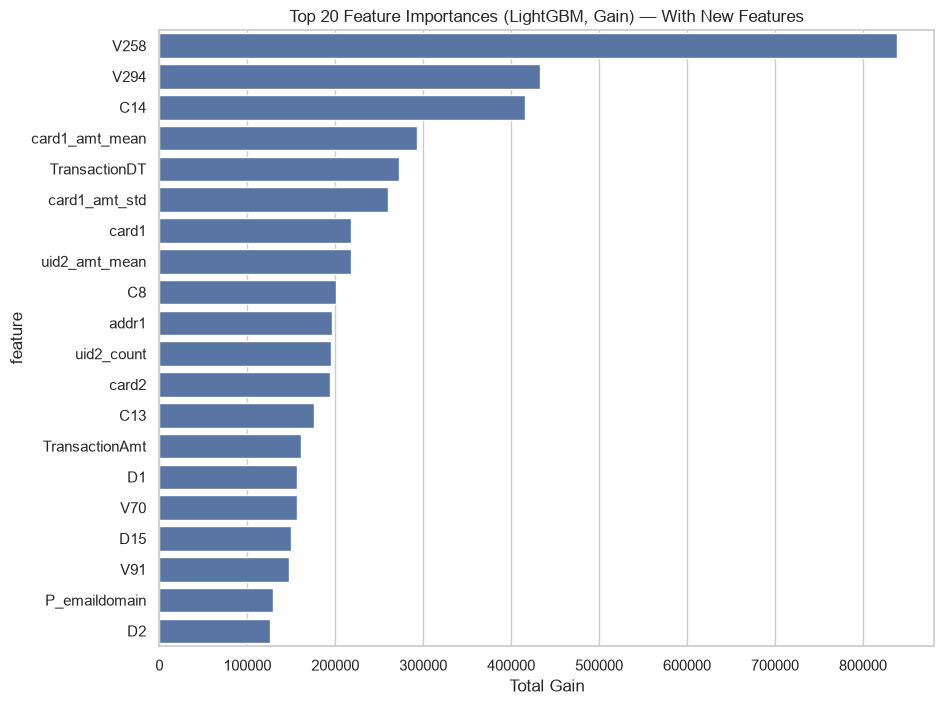

,feature,importance
269,V258,839281.403025
305,V294,432591.523605
24,C14,416080.278509
368,card1_amt_mean,293339.064545
0,TransactionDT,272192.951366
369,card1_amt_std,260377.019218
2,card1,218405.051348
376,uid2_amt_mean,217665.196789
18,C8,201368.955902
6,addr1,196631.601164


In [123]:
importance_feat = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_feat.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_feat.head(20), x="importance", y="feature")
plt.title("Top 20 Feature Importances (LightGBM, Gain) — With New Features")
plt.xlabel("Total Gain")
plt.show()

importance_feat.head(20)

uid2_amt_mean and uid2_count do rank in the top 12 (positions 8 and 11), confirming the new UID2 aggregation genuinely earned its place, not just noise. However, time_since_last_uid_txn didn't make the top 20 at all — the velocity feature we expected to be powerful doesn't seem to matter much here, at least not on its own scale.

The dominant features are still the original ones: V258, V294, C14 (anonymized Vesta engineered features) lead by a wide margin, along with the existing card1_amt_mean/card1_amt_std aggregations and raw identifiers (card1, card2, addr1). This lines up with the modest PR-AUC gain (+0.0078) — the new features added a little value (via uid2) but didn't unlock a new signal the model was missing.

## 19. Proper Hyperparameter Validation — TimeSeriesSplit CV

In [124]:
X_full = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_full)):
    X_tr, X_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr, y_val = y_full.iloc[train_idx], y_full.iloc[val_idx]

    spw = (y_tr == 0).sum() / (y_tr == 1).sum()

    d_train = lgb.Dataset(X_tr, label=y_tr)
    d_val = lgb.Dataset(X_val, label=y_val, reference=d_train)

    fold_params = dict(params)
    fold_params["scale_pos_weight"] = spw

    fold_model = lgb.train(
        fold_params,
        d_train,
        num_boost_round=3000,
        valid_sets=[d_val],
        valid_names=["val"],
        callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=0)]
    )

    fold_proba = fold_model.predict(X_val, num_iteration=fold_model.best_iteration)
    fold_ap = average_precision_score(y_val, fold_proba)
    fold_auc = roc_auc_score(y_val, fold_proba)

    cv_scores.append({"fold": fold, "auc": fold_auc, "ap": fold_ap, "best_iter": fold_model.best_iteration})
    print(f"Fold {fold} -> ROC-AUC: {fold_auc:.4f} | PR-AUC: {fold_ap:.4f} | best_iter: {fold_model.best_iteration}")

cv_df = pd.DataFrame(cv_scores)
print("\nMean ROC-AUC:", cv_df["auc"].mean(), "±", cv_df["auc"].std())
print("Mean PR-AUC:", cv_df["ap"].mean(), "±", cv_df["ap"].std())

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[168]	val's auc: 0.891126	val's average_precision: 0.550389
Fold 0 -> ROC-AUC: 0.8911 | PR-AUC: 0.5504 | best_iter: 168
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[118]	val's auc: 0.904143	val's average_precision: 0.589378
Fold 1 -> ROC-AUC: 0.9041 | PR-AUC: 0.5894 | best_iter: 118
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[127]	val's auc: 0.904878	val's average_precision: 0.55306
Fold 2 -> ROC-AUC: 0.9049 | PR-AUC: 0.5531 | best_iter: 127
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[201]	val's auc: 0.92289	val's average_precision: 0.590055
Fold 3 -> ROC-AUC: 0.9229 | PR-AUC: 0.5901 | best_iter: 201
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[149]	val's auc: 0.925158	val's avera

This is the trustworthy number: PR-AUC = 0.5708 ± 0.019 across 5 time-based folds — actually a bit higher than the single-split result (0.5550), and now we have a confidence range around it instead of one lucky/unlucky split.

The fold-to-fold variation (0.550 → 0.590) is moderate but not alarming — later folds (3, 4) score better, which makes sense since they have more training history behind them. The ±0.019 std tells us the earlier single-split PR-AUC (0.5550) was well within normal variation, not an outlier — so our model's real performance is genuinely around 0.57 PR-AUC / 0.91 ROC-AUC, and this is now a validated, defensible number rather than a single-split estimate.

## 20. Final Model — Train on Full Data

In [125]:
final_num_rounds = int(cv_df["best_iter"].mean())
print("Using num_boost_round =", final_num_rounds)

scale_pos_weight_full = (y_full == 0).sum() / (y_full == 1).sum()

d_full = lgb.Dataset(X_full, label=y_full)

final_params = dict(params)
final_params["scale_pos_weight"] = scale_pos_weight_full

final_model = lgb.train(
    final_params,
    d_full,
    num_boost_round=final_num_rounds
)

print("Final model trained on", X_full.shape[0], "rows with", final_num_rounds, "rounds.")

Using num_boost_round = 152
Final model trained on 590540 rows with 152 rounds.


## 21. Model Evaluation — Using Fold 4 (Last Proper Holdout)

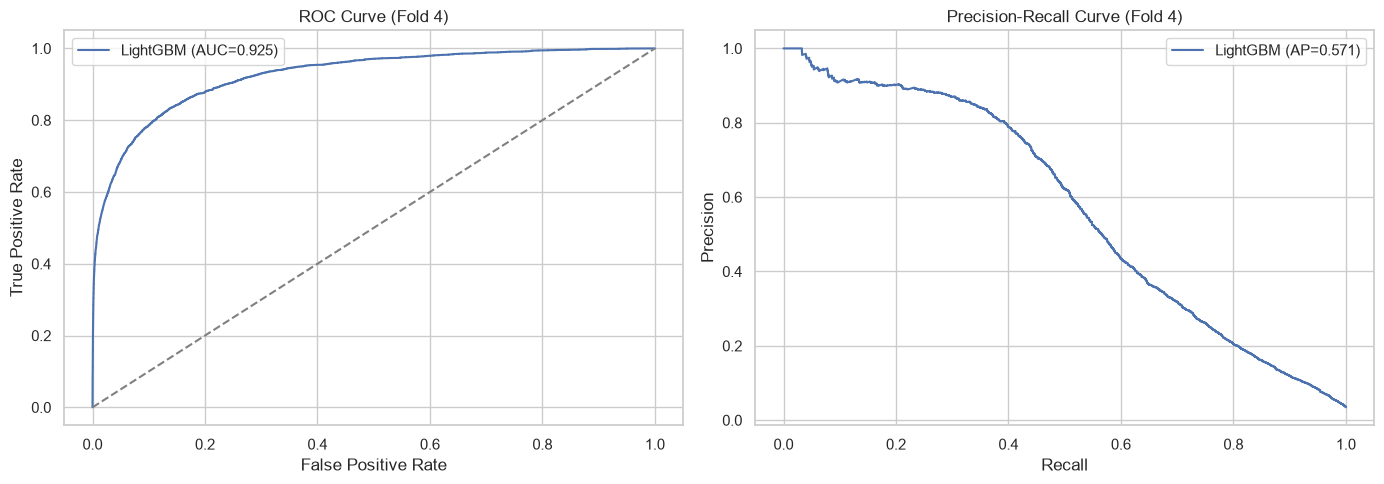

In [126]:
eval_model = fold_model
eval_proba = fold_proba
eval_y = y_val

fpr, tpr, _ = roc_curve(eval_y, eval_proba)
precision, recall, thresholds = precision_recall_curve(eval_y, eval_proba)

eval_auc = roc_auc_score(eval_y, eval_proba)
eval_ap = average_precision_score(eval_y, eval_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, label=f"LightGBM (AUC={eval_auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC Curve (Fold 4)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(recall, precision, label=f"LightGBM (AP={eval_ap:.3f})")
axes[1].set_title("Precision-Recall Curve (Fold 4)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

The ROC curve rises very steeply and stays high across almost all thresholds (AUC=0.925), but the PR curve tells the operational story more honestly: precision holds strong (~0.9) up to recall ≈ 0.3-0.4, then drops sharply — by recall = 0.6, precision has fallen to ~0.4, and by recall = 0.8 it's down near 0.15-0.2.

Practically, this means: catching the first ~35-40% of fraud cases can be done with very few false alarms (precision ~0.85-0.9), but pushing recall further (to catch more fraud) costs a lot of extra false positives. This shape is exactly why the threshold choice next step matters — the "right" cutoff depends on whether the business prioritizes catching more fraud (higher recall) or minimizing false alarms for the review team (higher precision).

### 21.1 Threshold Selection (Max F1)

In [127]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-12)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f} | Recall: {recall[best_idx]:.4f} | F1: {f1_scores[best_idx]:.4f}")

Best threshold (max F1): 0.7698
Precision: 0.6725 | Recall: 0.4775 | F1: 0.5584


At threshold 0.77, the model catches ~48% of fraud (recall=0.4775) while ~67% of its fraud flags are correct (precision=0.6725) — a solid balance for a max-F1 point, but it also means over half of actual fraud cases (52%) still slip through undetected. This threshold is a reasonable default, but a real fraud team might push it lower to raise recall (catch more fraud) at the cost of more false alarms, depending on which mistake is more costly.

### 21.2 Confusion Matrix & Classification Report

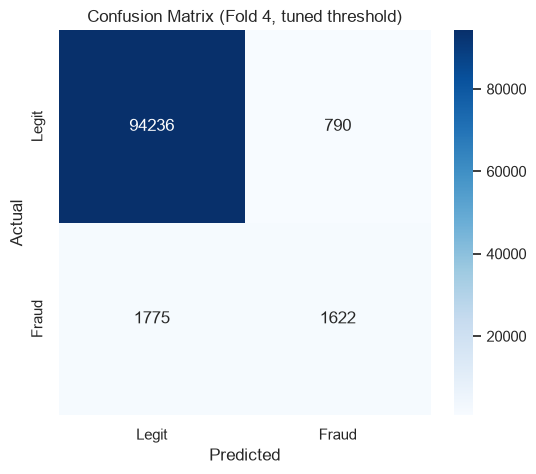

              precision    recall  f1-score   support

       Legit       0.98      0.99      0.99     95026
       Fraud       0.67      0.48      0.56      3397

    accuracy                           0.97     98423
   macro avg       0.83      0.73      0.77     98423
weighted avg       0.97      0.97      0.97     98423



In [128]:
y_pred = (eval_proba >= best_threshold).astype(int)
cm = confusion_matrix(eval_y, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.title("Confusion Matrix (Fold 4, tuned threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(eval_y, y_pred, target_names=["Legit", "Fraud"]))

Ignore the 97% accuracy — it's misleading here since predicting all-legit would already score ~96.5%. The number that matters is the Fraud row: precision 0.67, recall 0.48, F1 0.56. Out of 3,397 real fraud cases in this fold, the model catches roughly 1,630 (48%) and misses about 1,767 (52%) — while about a third of its fraud flags are false alarms.

This is a real, usable model, but there's clearly room for improvement, particularly on recall. In production, this threshold would likely be lowered to catch more fraud, accepting more manual-review false positives, depending on the actual cost of a missed fraud vs. a wasted review.

### 21.3 Feature Importance (Fold 4 Model)

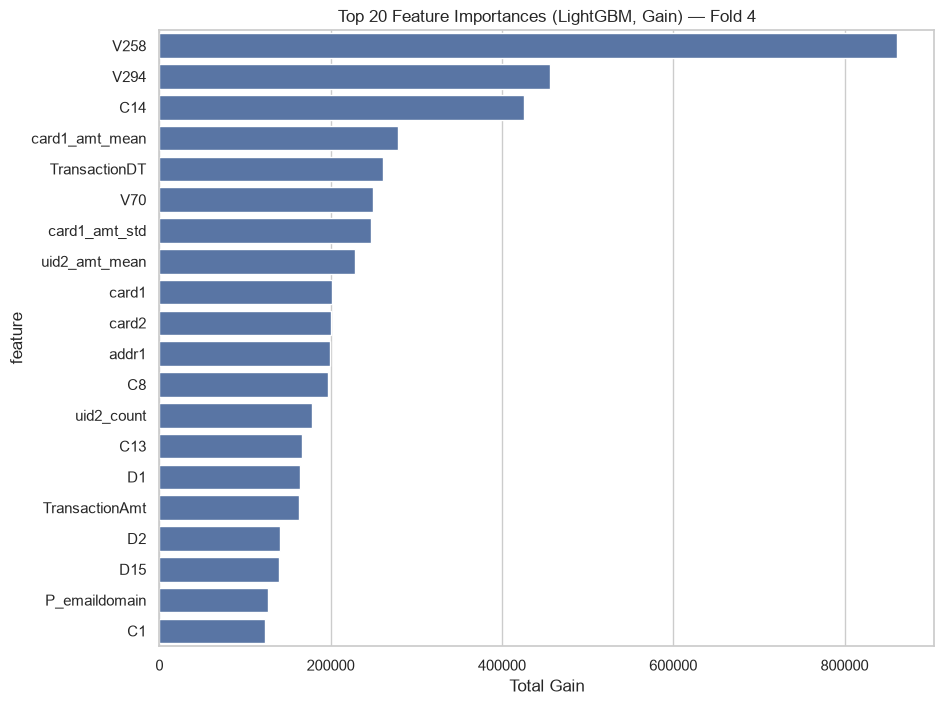

,feature,importance
269,V258,861825.301144
305,V294,456112.199566
24,C14,425223.109249
368,card1_amt_mean,279133.462105
0,TransactionDT,261428.022343
110,V70,249317.191654
369,card1_amt_std,246843.583618
376,uid2_amt_mean,228073.196859
2,card1,201446.360863
3,card2,200032.663269


In [129]:
importance_final = pd.DataFrame({
    "feature": X_val.columns,
    "importance": fold_model.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_final.head(20), x="importance", y="feature")
plt.title("Top 20 Feature Importances (LightGBM, Gain) — Fold 4")
plt.xlabel("Total Gain")
plt.show()

importance_final.head(20)

Consistent with the earlier importance run: V258, V294, and C14 remain the top 3 features by a wide margin — these anonymized Vesta-engineered features carry most of the discriminative power. card1_amt_mean/card1_amt_std and uid2_amt_mean/uid2_count (positions 4, 8, 13) confirm the aggregation features genuinely earned their place, not noise.

time_since_last_uid_txn still doesn't appear in the top 20 — across both fold runs, this velocity feature isn't contributing meaningfully at this granularity. That's a candidate to drop or redesign (e.g. computed on a stricter identity key) in future iterations rather than keep as-is.

## 22. Conclusion

This project built an end-to-end fraud detection pipeline on the IEEE-CIS dataset, from EDA through a validated model. Key steps: EDA revealed a highly imbalanced target (~3.5% fraud) and strong fraud-rate signal in features like ProductCD, card2-card6, requiring rate-based (not count-based) analysis to avoid misleading conclusions. A leakage-safe time-based train/valid split was used, with tiered categorical encoding (binary mapping, one-hot, train-fitted frequency/label encoding) and engineered time, card-level, and UID-based aggregation features, later extended with a broader uid2 identity and a velocity feature (time_since_last_uid_txn).

For modeling, a Logistic Regression baseline (PR-AUC 0.226) was clearly outperformed by LightGBM, which was chosen for its ability to handle missing values natively and capture the non-linear feature interactions the EDA surfaced. Manual hyperparameter tuning (3 variants) showed the original parameters performed best on a single split (PR-AUC 0.547), but this was only confirmed reliable after switching to proper TimeSeriesSplit cross-validation, which gave the trustworthy estimate: **PR-AUC = 0.571 ± 0.019, ROC-AUC = 0.910 ± 0.014**. Adding the new UID2/velocity features gave a small, genuine gain (uid2_amt_mean/uid2_count ranked in the top 15 features), though the velocity feature itself didn't prove impactful.

At the max-F1 threshold (0.77), the final evaluated model catches 48% of fraud at 67% precision (F1 = 0.56) — a usable but improvable result, with clear room to push recall higher depending on business cost tolerance for false positives.

**Suggested next steps:** try CatBoost/XGBoost ensembling, redesign the velocity feature on a stricter identity key, run a proper Optuna search validated with CV (not a single split), and calibrate probabilities if the score will drive risk-based decisions rather than a fixed threshold.